# Words vs Numbers: How Review Sentiment Shapes Online Ratings



### Abstract:

**In this project, I analyzed how online reviews, including both the number of reviews and their content, shape hotel ratings using a panel dataset of about 270,000 hotel-month observations from Booking.com. I applied three models, Pooled OLS, Fixed Effects, and GMM (Generalized Method of Moments), to uncover the underlying relationships. The results show that sentiment is the key driver, with positive words significantly increasing ratings (β ≈ +0.47) while negative words have an even stronger negative impact (β ≈ −0.42), whereas review volume plays only a minor role, highlighting that what customers say matters more than how many speak. A placebo test using future sentiment shows no effect, strengthening the credibility of the results. I also conducted heterogeneous analyses to explore behavioral patterns and found that longer stays reduce the sensitivity of ratings to sentiment, leading to more balanced evaluations. Finally, trend analysis of top hotels reveals smooth seasonal patterns during summer and holiday periods with no clear evidence of review manipulation or gaming, suggesting the data largely reflect genuine customer experiences.**


### Introduction

Online reviews have become one of the most important sources of information for consumers when making decisions in service markets such as hospitality. Platforms like Booking.com aggregate large volumes of user-generated content, including numerical ratings and textual feedback, which together shape perceptions of hotel quality. Understanding how these reviews translate into overall ratings is therefore essential not only for consumers, but also for firms seeking to manage their reputation and for researchers interested in digital market dynamics.

This project examines how **the content and volume of online reviews** influence hotel ratings over time. In particular, it focuses on the role of review sentiment, measured through the number of positive and negative words, and review activity, captured by the number of reviews submitted. 

The central question **is whether and how these factors** affect the average rating of a hotel, and whether their effects remain robust under different modeling assumptions.

To address this question, the analysis constructs a panel dataset at the hotel-month level from daily review data. This aggregation allows us to track the evolution of review sentiment, review volume, and average ratings over time for each hotel, while accounting for both cross-sectional and temporal variation. 

The empirical strategy starts with **pooled OLS model** and then relies primarily on **fixed effects models**, which control for unobserved, time-invariant differences across hotels (such as location, brand, or inherent quality) as well as common time shocks (such as seasonality). In addition, a dynamic panel approach using **GMM (Arellano–Bond)** is implemented as a robustness check to address potential endogeneity and persistence in ratings.

A key feature of the analysis is the distinction between short-run “flow” effects and longer-term reputation. By focusing on monthly averages of sentiment and review activity, the model captures how new information which is recent reviews affects current ratings. At the same time, alternative specifications, including cumulative measures, are considered as robustness checks to explore whether longer-term reputation plays a role.

Beyond the baseline relationship, the project also investigates heterogeneity and behavioral mechanisms. In particular, it examines how the length of stay (number of nights) interacts with review sentiment. The results suggest that while sentiment strongly influences ratings, its impact is moderated by stay duration, with longer stays leading to more balanced evaluations and weaker marginal effects of both positive and negative experiences.

To ensure the credibility of the findings, a series of robustness checks are conducted. These include alternative model specifications, clustered standard errors, lagged and lead (placebo) variables, subsample analyses, and the exclusion of dominant hotels with extremely high review activity. The placebo test using future sentiment variables provides especially strong evidence against reverse causality, as future reviews do not predict current ratings.

Finally, the project explores the possibility of review manipulation (gaming). By analyzing the temporal patterns of review volume and sentiment for the most active hotels, it assesses whether the data exhibit abnormal spikes or irregularities that could indicate strategic behavior. The evidence shows that both review activity and sentiment evolve smoothly over time and follow clear seasonal patterns such as increases during summer travel months and holiday periods—suggesting that the data largely reflect genuine consumer experiences rather than artificial manipulation.

In a nutshell, this study provides a comprehensive analysis of how online review dynamics shape hotel ratings, combining rigorous econometric methods with detailed behavioral insights. The findings highlight the central role of sentiment, the importance of recent information, and the robustness of observed patterns in the presence of potential biases and strategic behavior.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('Hotel_Reviews.csv')
df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968



## Hotel Reviews Dataset and Main Variables

**Hotel_Address**: Address of the hotel  

**Review_Date**: Date when the review was posted  

**Average_Score**: Average score of the hotel (based on recent reviews, typically last year)  

**Hotel_Name**: Name of the hotel  

**Reviewer_Nationality**: Nationality of the reviewer  

**Negative_Review**: Text of negative review (or *'No Negative'* if none)  

**Review_Total_Negative_Word_Counts**: Number of words in the negative review  

**Positive_Review**: Text of positive review (or *'No Positive'* if none)  

**Review_Total_Positive_Word_Counts**: Number of words in the positive review  

**Reviewer_Score**: Score given by the reviewer  

**Total_Number_of_Reviews_Reviewer_Has_Given**: Total reviews written by the reviewer in the past  

**Total_Number_of_Reviews**: Total number of reviews for the hotel  

**Tags**: Tags assigned by the reviewer (e.g., trip type, room type)  

**days_since_review**: Number of days between review date and data collection  

**Additional_Number_of_Scoring**: Number of ratings without written reviews  

**lat**: Latitude of the hotel  

**lng**: Longitude of the hotel  

In [3]:
df.shape

(515738, 17)

In [4]:
df.dtypes

Hotel_Address                                  object
Additional_Number_of_Scoring                    int64
Review_Date                                    object
Average_Score                                 float64
Hotel_Name                                     object
Reviewer_Nationality                           object
Negative_Review                                object
Review_Total_Negative_Word_Counts               int64
Total_Number_of_Reviews                         int64
Positive_Review                                object
Review_Total_Positive_Word_Counts               int64
Total_Number_of_Reviews_Reviewer_Has_Given      int64
Reviewer_Score                                float64
Tags                                           object
days_since_review                              object
lat                                           float64
lng                                           float64
dtype: object

In [5]:
df.describe()

,Additional_Number_of_Scoring,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,lat,lng
count,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,512470.000000,512470.000000
mean,498.081836,8.397487,18.539450,2743.743944,17.776458,7.166001,8.395077,49.442439,2.823803
std,500.538467,0.548048,29.690831,2317.464868,21.804185,11.040228,1.637856,3.466325,4.579425
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.000000,2.500000,41.328376,-0.369758
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.000000,7.500000,48.214662,-0.143372
50%,341.000000,8.400000,9.000000,2134.000000,11.000000,3.000000,8.800000,51.499981,0.010607
75%,660.000000,8.800000,23.000000,3613.000000,22.000000,8.000000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.000000,10.000000,52.400181,16.429233


In [6]:
df.isna().sum()

Hotel_Address                                    0
Additional_Number_of_Scoring                     0
Review_Date                                      0
Average_Score                                    0
Hotel_Name                                       0
Reviewer_Nationality                             0
Negative_Review                                  0
Review_Total_Negative_Word_Counts                0
Total_Number_of_Reviews                          0
Positive_Review                                  0
Review_Total_Positive_Word_Counts                0
Total_Number_of_Reviews_Reviewer_Has_Given       0
Reviewer_Score                                   0
Tags                                             0
days_since_review                                0
lat                                           3268
lng                                           3268
dtype: int64

In [8]:
df.duplicated().sum()

526

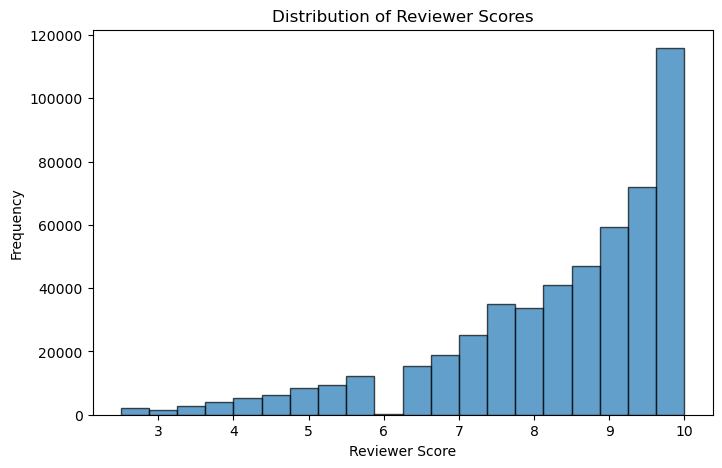

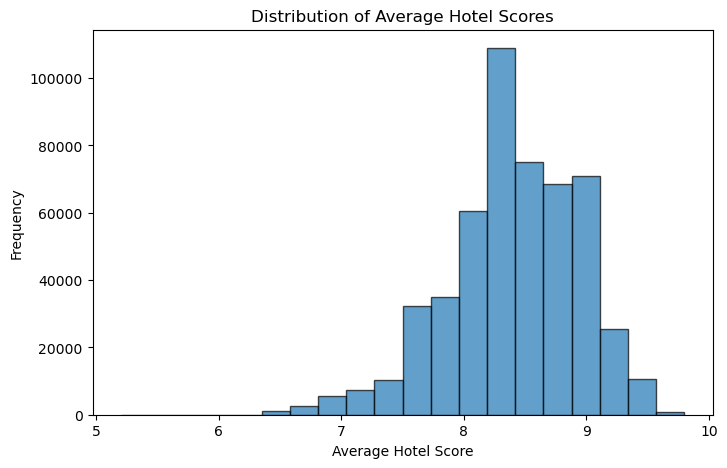

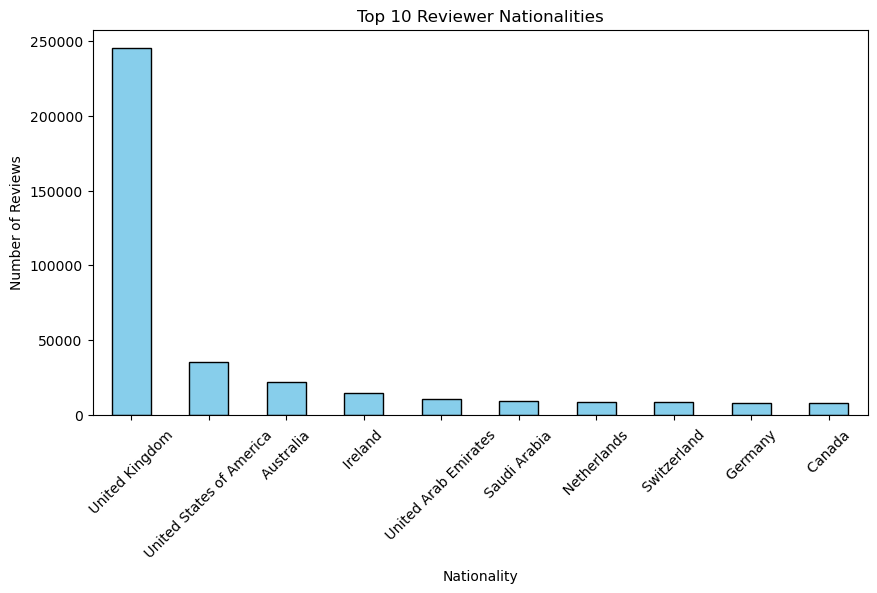

In [9]:


# 1. Histogram for Reviewer Scores
fig1 = plt.figure(figsize=(8, 5))
plt.hist(df["Reviewer_Score"], bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Reviewer Score")
plt.ylabel("Frequency")
plt.title("Distribution of Reviewer Scores")
plt.show()

# 2. Histogram for Average Hotel Score
fig2 = plt.figure(figsize=(8, 5))
plt.hist(df["Average_Score"], bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Average Hotel Score")
plt.ylabel("Frequency")
plt.title("Distribution of Average Hotel Scores")
plt.show()

# 3. Bar plot for Top 10 Reviewer Nationalities
top_nationalities = df["Reviewer_Nationality"].value_counts().head(10)
fig3 = plt.figure(figsize=(10, 5))
top_nationalities.plot(kind="bar", color="skyblue", edgecolor="black")
plt.xlabel("Nationality")
plt.ylabel("Number of Reviews")
plt.title("Top 10 Reviewer Nationalities")
plt.xticks(rotation=45)
plt.show()

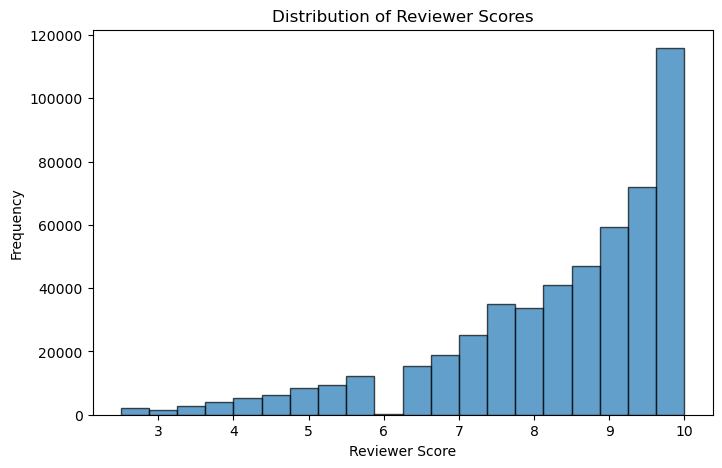

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["Reviewer_Score"], bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Reviewer Score")
plt.ylabel("Frequency")
plt.title("Distribution of Reviewer Scores")
plt.show()  

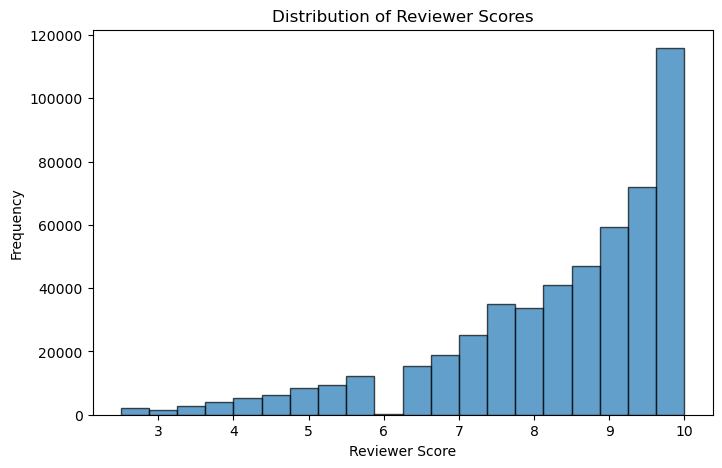

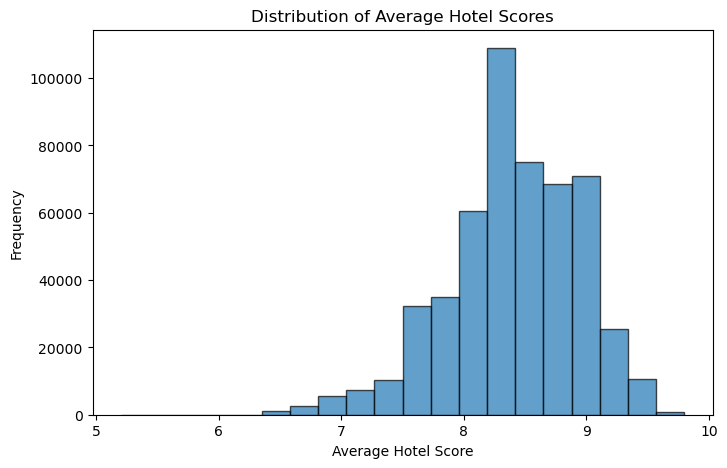

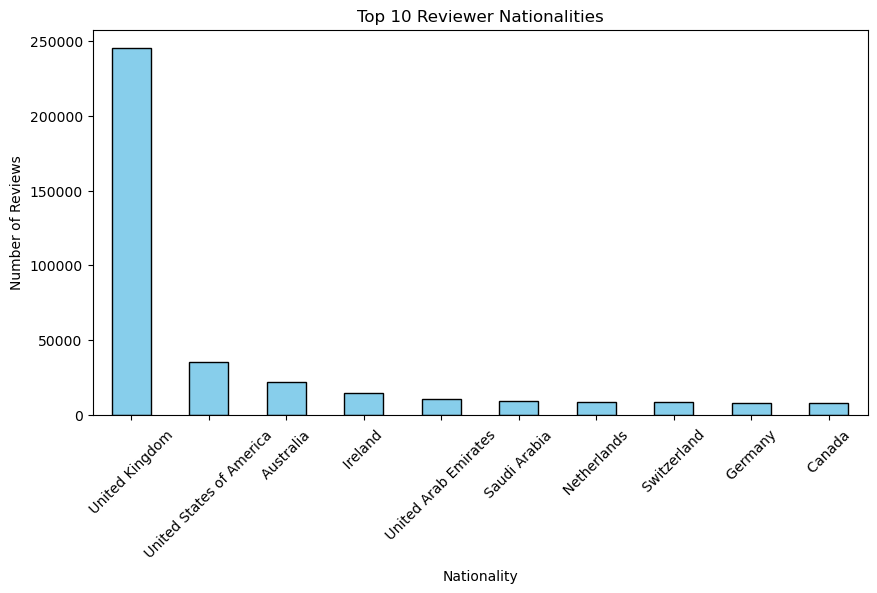

In [11]:

plt.figure(figsize=(8, 5))
plt.hist(df["Reviewer_Score"], bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Reviewer Score")
plt.ylabel("Frequency")
plt.title("Distribution of Reviewer Scores")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["Average_Score"], bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Average Hotel Score")
plt.ylabel("Frequency")
plt.title("Distribution of Average Hotel Scores")
plt.show()

top_nationalities = df["Reviewer_Nationality"].value_counts().head(10)
plt.figure(figsize=(10, 5))
top_nationalities.plot(kind="bar", color="skyblue", edgecolor="black")
plt.xlabel("Nationality")
plt.ylabel("Number of Reviews")
plt.title("Top 10 Reviewer Nationalities")
plt.xticks(rotation=45)
plt.show()

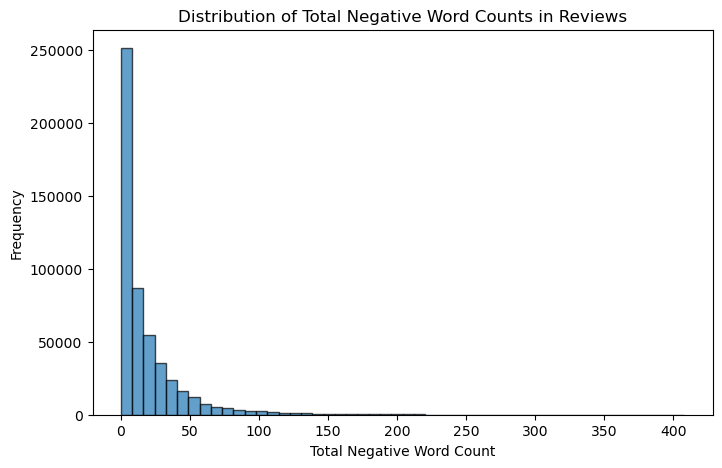

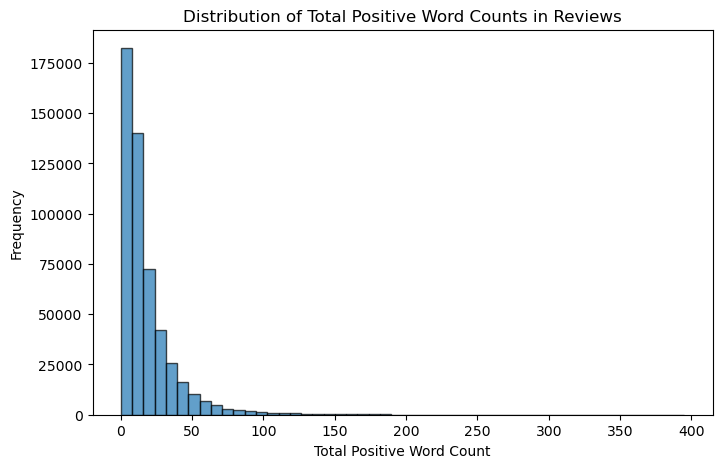

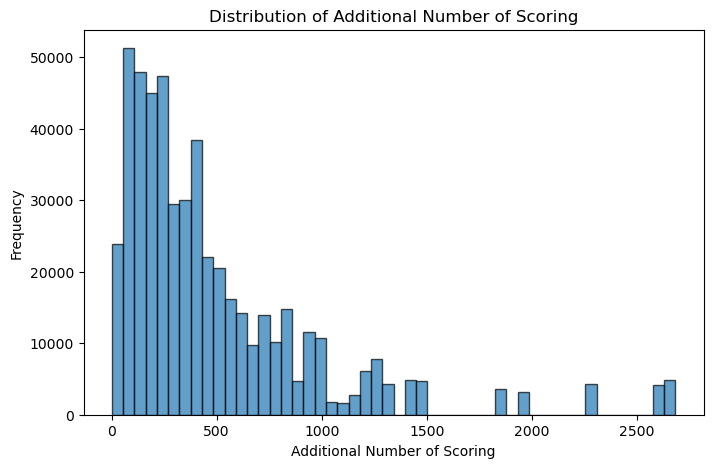

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["Review_Total_Negative_Word_Counts"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Total Negative Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Total Negative Word Counts in Reviews")
plt.show()

#  histogram for Review_Total_Positive_Word_Counts
plt.figure(figsize=(8, 5))
plt.hist(df["Review_Total_Positive_Word_Counts"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Total Positive Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Total Positive Word Counts in Reviews")
plt.show()

#  histogram for Additional_Number_of_Scoring
plt.figure(figsize=(8, 5))
plt.hist(df["Additional_Number_of_Scoring"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Additional Number of Scoring")
plt.ylabel("Frequency")
plt.title("Distribution of Additional Number of Scoring")
plt.show()

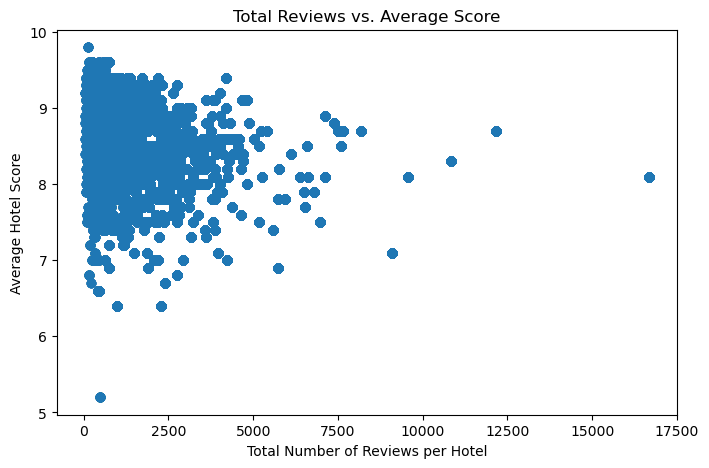

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Total_Number_of_Reviews"], df["Average_Score"], alpha=0.5)
plt.xlabel("Total Number of Reviews per Hotel")
plt.ylabel("Average Hotel Score")
plt.title("Total Reviews vs. Average Score")
plt.show()

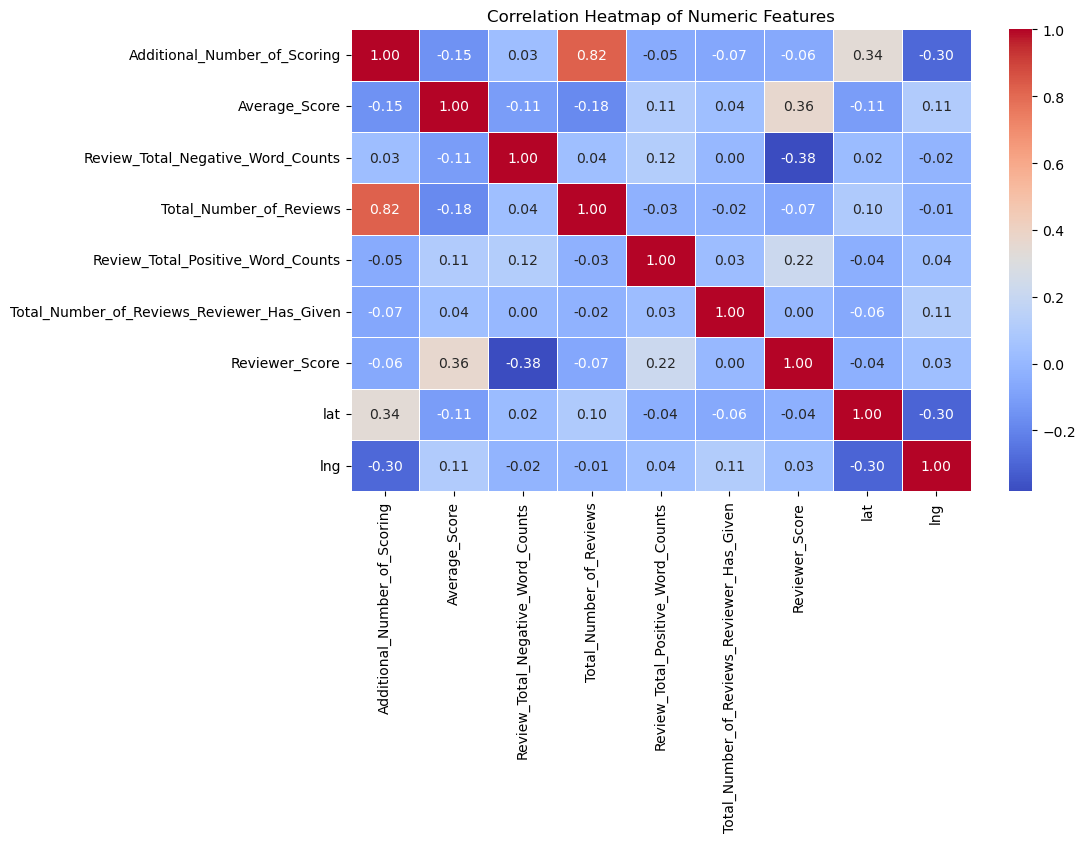

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

The correlation heatmap gives an initial overview of how key variables relate to each other in the raw data before moving to causal models. It shows that review sentiment is the strongest correlate of ratings, with positive words moderately increasing scores and negative words having a stronger negative association. In contrast, the number of reviews has only a weak relationship with ratings, suggesting that volume alone does not drive perceptions of quality. At the same time, most explanatory variables are only weakly correlated with each other, indicating low multicollinearity and supporting the stability of the econometric models. Based on these patterns, meaningful interactions can be constructed between review volume and sentiment, capturing whether positive or negative reviews matter more when a hotel has greater visibility, as well as between positive and negative sentiment to reflect mixed customer experiences.

In [17]:
df['Country'] = df['Hotel_Address'].apply(lambda x: x.split()[-1])

# Counting unique hotels per country
hotels_per_country = df.groupby('Country')['Hotel_Name'].nunique()

# Counting total number of reviews per country
reviews_per_country = df['Country'].value_counts()

# merging into a single DataFrame
country_stats = pd.DataFrame({
    'Number_of_Hotels': hotels_per_country,
    'Number_of_Reviews': reviews_per_country
}).reset_index().rename(columns={'index': 'Country'})


country_stats.head(7)

,Country,Number_of_Hotels,Number_of_Reviews
0,Austria,158,38939
1,France,458,59928
2,Italy,162,37207
3,Kingdom,400,262301
4,Netherlands,105,57214
5,Spain,211,60149


In [21]:
df['Tags'].value_counts()

Tags
[' Leisure trip ', ' Couple ', ' Double Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']                                  5101
[' Leisure trip ', ' Couple ', ' Standard Double Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']                         4931
[' Leisure trip ', ' Couple ', ' Superior Double Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']                         4366
[' Leisure trip ', ' Couple ', ' Deluxe Double Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']                           3991
[' Leisure trip ', ' Couple ', ' Double Room ', ' Stayed 2 nights ', ' Submitted from a mobile device ']                                 3291
                                                                                                                                         ... 
[' Leisure trip ', ' Family with older children ', ' Suite Family Room ', ' Stayed 5 nights ', ' Submitted from a mobile device ']          1
[

In [22]:
df['Hotel_Address'].value_counts()

Hotel_Address
163 Marsh Wall Docklands Tower Hamlets London E14 9SJ United Kingdom              4789
372 Strand Westminster Borough London WC2R 0JJ United Kingdom                     4256
Westminster Bridge Road Lambeth London SE1 7UT United Kingdom                     4169
Scarsdale Place Kensington Kensington and Chelsea London W8 5SY United Kingdom    3578
7 Pepys Street City of London London EC3N 4AF United Kingdom                      3212
                                                                                  ... 
21 rue Lavoisier 8th arr 75008 Paris France                                         12
2 4 Boundary Street Hackney London E2 7DD United Kingdom                            12
Via M Buonarroti 13 Fiera Milano City 20149 Milan Italy                             10
13 Rue Fran ois Ory 92120 Paris France                                              10
Johann Staud Stra e 32 16 Ottakring 1160 Vienna Austria                              8
Name: count, Length: 1493, dt

In [23]:

df["Country"] = df["Hotel_Address"].str.split().str[-1]

countries = df["Country"].unique()

print(countries)

['Netherlands' 'Kingdom' 'France' 'Spain' 'Italy' 'Austria']


In [25]:
import ast
df["Tags_list"] = df["Tags"].apply(ast.literal_eval)

In [26]:
def extract_trip(tags):
    for t in tags:
        if "trip" in t.lower():
            return t.strip()
    return None

df["Trip_Type"] = df["Tags_list"].apply(extract_trip)
df

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng,Country,Tags_list,Trip_Type
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Family with young children ,...",Leisure trip
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Solo traveler , Duplex Doub...",Leisure trip
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Suite , Stayed 2 ...",Leisure trip
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515733,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/30/2015,8.1,Atlantis Hotel Vienna,Kuwait,no trolly or staff to help you take the lugga...,14,2823,location,2,8,7.0,"[' Leisure trip ', ' Family with older childre...",704 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip
515734,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/22/2015,8.1,Atlantis Hotel Vienna,Estonia,The hotel looks like 3 but surely not 4,11,2823,Breakfast was ok and we got earlier check in,11,12,5.8,"[' Leisure trip ', ' Family with young childre...",712 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with young children ,...",Leisure trip
515735,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/19/2015,8.1,Atlantis Hotel Vienna,Egypt,The ac was useless It was a hot week in vienn...,19,2823,No Positive,0,3,2.5,"[' Leisure trip ', ' Family with older childre...",715 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip
515736,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/17/2015,8.1,Atlantis Hotel Vienna,Mexico,No Negative,0,2823,The rooms are enormous and really comfortable...,25,3,8.8,"[' Leisure trip ', ' Group ', ' Standard Tripl...",717 day,48.203745,16.335677,Austria,"[ Leisure trip , Group , Standard Triple Roo...",Leisure trip


In [27]:
df["Trip_Type"].value_counts()

Trip_Type
Leisure trip                                        417778
Business trip                                        82939
Triple Room                                            134
Standard Triple Room                                    46
Deluxe Triple Room                                      22
Superior Triple Room                                    21
Comfort Triple Room                                     12
Classic Triple Room                                     11
Triple Room 2 Adults 1 Child                             7
Executive Triple Room                                    6
Studio Triple                                            5
Junior Triple Room                                       5
Triple Studio                                            4
Triple Hilton Family Room                                3
Triple Family Guestroom                                  2
Classic Triple Room 3 Adults                             2
Triple Room with Spa Bath                     

In [28]:
import re

def extract_trip(tags):
    for t in tags:
        if re.search(r"\btrip\b", t.lower()):   # matches 'trip' as a whole word
            return t.strip()
    return None

df["Trip_Type"] = df["Tags_list"].apply(extract_trip)
df

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng,Country,Tags_list,Trip_Type
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Family with young children ,...",Leisure trip
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Solo traveler , Duplex Doub...",Leisure trip
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Suite , Stayed 2 ...",Leisure trip
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515733,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/30/2015,8.1,Atlantis Hotel Vienna,Kuwait,no trolly or staff to help you take the lugga...,14,2823,location,2,8,7.0,"[' Leisure trip ', ' Family with older childre...",704 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip
515734,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/22/2015,8.1,Atlantis Hotel Vienna,Estonia,The hotel looks like 3 but surely not 4,11,2823,Breakfast was ok and we got earlier check in,11,12,5.8,"[' Leisure trip ', ' Family with young childre...",712 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with young children ,...",Leisure trip
515735,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/19/2015,8.1,Atlantis Hotel Vienna,Egypt,The ac was useless It was a hot week in vienn...,19,2823,No Positive,0,3,2.5,"[' Leisure trip ', ' Family with older childre...",715 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip
515736,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/17/2015,8.1,Atlantis Hotel Vienna,Mexico,No Negative,0,2823,The rooms are enormous and really comfortable...,25,3,8.8,"[' Leisure trip ', ' Group ', ' Standard Tripl...",717 day,48.203745,16.335677,Austria,"[ Leisure trip , Group , Standard Triple Roo...",Leisure trip


In [29]:
df["Trip_Type"].value_counts()

Trip_Type
Leisure trip     417778
Business trip     82939
Name: count, dtype: int64

In [30]:
def extract_traveler(tags):
    patterns = [
        r"\bsolo traveler\b",
        r"\bcouple\b",
        r"\bfamily with young children\b",
        r"\bfamily with older children\b",
        r"\bfamily\b",
        r"\bgroup\b"
    ]
    
    for t in tags:
        text = t.lower()
        for p in patterns:
            if re.search(p, text):
                return t.strip()
    
    return None

df["Traveler_Type"] = df["Tags_list"].apply(extract_traveler)
df

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,...,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng,Country,Tags_list,Trip_Type,Traveler_Type
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,...,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip,Couple
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,...,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip,Couple
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,...,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,...,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Solo traveler , Duplex Doub...",Leisure trip,Solo traveler
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,...,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Suite , Stayed 2 ...",Leisure trip,Couple
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515733,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/30/2015,8.1,Atlantis Hotel Vienna,Kuwait,no trolly or staff to help you take the lugga...,14,2823,location,...,8,7.0,"[' Leisure trip ', ' Family with older childre...",704 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip,Family with older children
515734,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/22/2015,8.1,Atlantis Hotel Vienna,Estonia,The hotel looks like 3 but surely not 4,11,2823,Breakfast was ok and we got earlier check in,...,12,5.8,"[' Leisure trip ', ' Family with young childre...",712 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children
515735,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/19/2015,8.1,Atlantis Hotel Vienna,Egypt,The ac was useless It was a hot week in vienn...,19,2823,No Positive,...,3,2.5,"[' Leisure trip ', ' Family with older childre...",715 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip,Family with older children
515736,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/17/2015,8.1,Atlantis Hotel Vienna,Mexico,No Negative,0,2823,The rooms are enormous and really comfortable...,...,3,8.8,"[' Leisure trip ', ' Group ', ' Standard Tripl...",717 day,48.203745,16.335677,Austria,"[ Leisure trip , Group , Standard Triple Roo...",Leisure trip,Group


In [31]:
df["Traveler_Type"].value_counts()

Traveler_Type
Couple                                                         252294
Solo traveler                                                  108545
Group                                                           65392
Family with young children                                      61015
Family with older children                                      26349
Family Room                                                        16
Triple Hilton Family Room                                           2
Family Suite                                                        2
Family Quadruple Room                                               2
Family Room 3 Adults                                                1
Family Two Bedroom Suite                                            1
Deluxe Family Room with 1 Double and 2 Single Beds 4 Adults         1
Deluxe Family Room with View                                        1
Family Apartment                                                    1
King D

In [32]:
def extract_room(tags):
    for t in tags:
        text = t.lower().strip()
        
        if re.search(r"\b(room|suite|studio|apartment|guestroom)\b", text):
            return t.strip()
    return None

df["Room_Type"] = df["Tags_list"].apply(extract_room)
df

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,...,Reviewer_Score,Tags,days_since_review,lat,lng,Country,Tags_list,Trip_Type,Traveler_Type,Room_Type
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,...,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip,Couple,Duplex Double Room
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,...,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip,Couple,Duplex Double Room
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,...,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children,Duplex Double Room
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,...,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Solo traveler , Duplex Doub...",Leisure trip,Solo traveler,Duplex Double Room
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,...,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Suite , Stayed 2 ...",Leisure trip,Couple,Suite
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515733,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/30/2015,8.1,Atlantis Hotel Vienna,Kuwait,no trolly or staff to help you take the lugga...,14,2823,location,...,7.0,"[' Leisure trip ', ' Family with older childre...",704 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip,Family with older children,None
515734,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/22/2015,8.1,Atlantis Hotel Vienna,Estonia,The hotel looks like 3 but surely not 4,11,2823,Breakfast was ok and we got earlier check in,...,5.8,"[' Leisure trip ', ' Family with young childre...",712 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children,Standard Triple Room
515735,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/19/2015,8.1,Atlantis Hotel Vienna,Egypt,The ac was useless It was a hot week in vienn...,19,2823,No Positive,...,2.5,"[' Leisure trip ', ' Family with older childre...",715 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip,Family with older children,None
515736,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/17/2015,8.1,Atlantis Hotel Vienna,Mexico,No Negative,0,2823,The rooms are enormous and really comfortable...,...,8.8,"[' Leisure trip ', ' Group ', ' Standard Tripl...",717 day,48.203745,16.335677,Austria,"[ Leisure trip , Group , Standard Triple Roo...",Leisure trip,Group,Standard Triple Room


In [33]:
df["Room_Type"].value_counts().head(20)

Room_Type
Double Room                     35207
Standard Double Room            32248
Superior Double Room            31393
Deluxe Double Room              24823
Double or Twin Room             22393
Standard Double or Twin Room    17483
Classic Double Room             16989
Superior Double or Twin Room    13570
Standard Twin Room               9745
Single Room                      9670
Twin Room                        8321
Executive Double Room            6425
Classic Double or Twin Room      6107
Superior Twin Room               6064
Deluxe Double or Twin Room       5998
Club Double Room                 5908
Queen Room                       5472
Deluxe King Room                 5357
Superior Queen Room              4898
Standard Single Room             4615
Name: count, dtype: int64

In [34]:
df["Room_Type"].isnull().sum()

22711

In [35]:
def extract_nights(tags):
    for t in tags:
        text = t.lower()
        
        # Looking for tags that mention stayed + night(s)
        if "stayed" in text and "night" in text:
            return t.strip()
    
    return None

df["Nights_Stayed"] = df["Tags_list"].apply(extract_nights)
df

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,...,Tags,days_since_review,lat,lng,Country,Tags_list,Trip_Type,Traveler_Type,Room_Type,Nights_Stayed
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,...,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip,Couple,Duplex Double Room,Stayed 6 nights
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,...,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip,Couple,Duplex Double Room,Stayed 4 nights
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,...,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children,Duplex Double Room,Stayed 3 nights
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,...,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Solo traveler , Duplex Doub...",Leisure trip,Solo traveler,Duplex Double Room,Stayed 3 nights
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,...,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Suite , Stayed 2 ...",Leisure trip,Couple,Suite,Stayed 2 nights
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515733,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/30/2015,8.1,Atlantis Hotel Vienna,Kuwait,no trolly or staff to help you take the lugga...,14,2823,location,...,"[' Leisure trip ', ' Family with older childre...",704 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip,Family with older children,None,Stayed 5 nights
515734,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/22/2015,8.1,Atlantis Hotel Vienna,Estonia,The hotel looks like 3 but surely not 4,11,2823,Breakfast was ok and we got earlier check in,...,"[' Leisure trip ', ' Family with young childre...",712 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children,Standard Triple Room,Stayed 2 nights
515735,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/19/2015,8.1,Atlantis Hotel Vienna,Egypt,The ac was useless It was a hot week in vienn...,19,2823,No Positive,...,"[' Leisure trip ', ' Family with older childre...",715 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip,Family with older children,None,Stayed 4 nights
515736,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/17/2015,8.1,Atlantis Hotel Vienna,Mexico,No Negative,0,2823,The rooms are enormous and really comfortable...,...,"[' Leisure trip ', ' Group ', ' Standard Tripl...",717 day,48.203745,16.335677,Austria,"[ Leisure trip , Group , Standard Triple Roo...",Leisure trip,Group,Standard Triple Room,Stayed 3 nights


In [36]:
df["Nights_Stayed"].value_counts().head(40)

Nights_Stayed
Stayed 1 night      193645
Stayed 2 nights     133937
Stayed 3 nights      95821
Stayed 4 nights      47817
Stayed 5 nights      20845
Stayed 6 nights       9776
Stayed 7 nights       7399
Stayed 8 nights       2502
Stayed 9 nights       1293
Stayed 10 nights       889
Stayed 11 nights       418
Stayed 12 nights       316
Stayed 14 nights       247
Stayed 13 nights       246
Stayed 15 nights       117
Stayed 16 nights        57
Stayed 17 nights        42
Stayed 18 nights        33
Stayed 19 nights        29
Stayed 21 nights        23
Stayed 20 nights        19
Stayed 30 nights        11
Stayed 27 nights        11
Stayed 23 nights        10
Stayed 22 nights        10
Stayed 25 nights         7
Stayed 28 nights         7
Stayed 26 nights         7
Stayed 24 nights         6
Stayed 29 nights         5
Stayed 31 nights         1
Name: count, dtype: int64

In [37]:
df["Num_Nights"] = (
    df["Nights_Stayed"]
    .str.extract(r"(\d+)")
    .astype(float)
)

df

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,...,days_since_review,lat,lng,Country,Tags_list,Trip_Type,Traveler_Type,Room_Type,Nights_Stayed,Num_Nights
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,...,0 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip,Couple,Duplex Double Room,Stayed 6 nights,6.0
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,...,0 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip,Couple,Duplex Double Room,Stayed 4 nights,4.0
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,...,3 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children,Duplex Double Room,Stayed 3 nights,3.0
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,...,3 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Solo traveler , Duplex Doub...",Leisure trip,Solo traveler,Duplex Double Room,Stayed 3 nights,3.0
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,...,10 days,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Suite , Stayed 2 ...",Leisure trip,Couple,Suite,Stayed 2 nights,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515733,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/30/2015,8.1,Atlantis Hotel Vienna,Kuwait,no trolly or staff to help you take the lugga...,14,2823,location,...,704 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip,Family with older children,None,Stayed 5 nights,5.0
515734,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/22/2015,8.1,Atlantis Hotel Vienna,Estonia,The hotel looks like 3 but surely not 4,11,2823,Breakfast was ok and we got earlier check in,...,712 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children,Standard Triple Room,Stayed 2 nights,2.0
515735,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/19/2015,8.1,Atlantis Hotel Vienna,Egypt,The ac was useless It was a hot week in vienn...,19,2823,No Positive,...,715 day,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip,Family with older children,None,Stayed 4 nights,4.0
515736,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/17/2015,8.1,Atlantis Hotel Vienna,Mexico,No Negative,0,2823,The rooms are enormous and really comfortable...,...,717 day,48.203745,16.335677,Austria,"[ Leisure trip , Group , Standard Triple Roo...",Leisure trip,Group,Standard Triple Room,Stayed 3 nights,3.0


In [38]:
def extract_device(tags):
    for t in tags:
        text = t.lower()
        
        # Looking for submission device tags
        if "submitted from" in text:
            return t.strip()
    
    return None

df["Submission_Device"] = df["Tags_list"].apply(extract_device)
df

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,...,lat,lng,Country,Tags_list,Trip_Type,Traveler_Type,Room_Type,Nights_Stayed,Num_Nights,Submission_Device
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,...,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip,Couple,Duplex Double Room,Stayed 6 nights,6.0,None
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,...,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Duplex Double Room...",Leisure trip,Couple,Duplex Double Room,Stayed 4 nights,4.0,None
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,...,52.360576,4.915968,Netherlands,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children,Duplex Double Room,Stayed 3 nights,3.0,Submitted from a mobile device
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,...,52.360576,4.915968,Netherlands,"[ Leisure trip , Solo traveler , Duplex Doub...",Leisure trip,Solo traveler,Duplex Double Room,Stayed 3 nights,3.0,None
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,...,52.360576,4.915968,Netherlands,"[ Leisure trip , Couple , Suite , Stayed 2 ...",Leisure trip,Couple,Suite,Stayed 2 nights,2.0,Submitted from a mobile device
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515733,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/30/2015,8.1,Atlantis Hotel Vienna,Kuwait,no trolly or staff to help you take the lugga...,14,2823,location,...,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip,Family with older children,None,Stayed 5 nights,5.0,None
515734,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/22/2015,8.1,Atlantis Hotel Vienna,Estonia,The hotel looks like 3 but surely not 4,11,2823,Breakfast was ok and we got earlier check in,...,48.203745,16.335677,Austria,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children,Standard Triple Room,Stayed 2 nights,2.0,None
515735,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/19/2015,8.1,Atlantis Hotel Vienna,Egypt,The ac was useless It was a hot week in vienn...,19,2823,No Positive,...,48.203745,16.335677,Austria,"[ Leisure trip , Family with older children ,...",Leisure trip,Family with older children,None,Stayed 4 nights,4.0,Submitted from a mobile device
515736,Wurzbachgasse 21 15 Rudolfsheim F nfhaus 1150 ...,168,8/17/2015,8.1,Atlantis Hotel Vienna,Mexico,No Negative,0,2823,The rooms are enormous and really comfortable...,...,48.203745,16.335677,Austria,"[ Leisure trip , Group , Standard Triple Roo...",Leisure trip,Group,Standard Triple Room,Stayed 3 nights,3.0,None


In [39]:
df["Submission_Device"].value_counts()

Submission_Device
Submitted from a mobile device    307640
Name: count, dtype: int64

In [40]:
df["Submission_Device"].isnull().sum()

208098

#### Selecting UK hotels

Since thi is a large data like half millions obs, we will go just for all the observations that are for UK hotels. 
to reduce the numbers of the hotels and also specify the location to reinforce the power of causality. 

In [41]:
uk_df = df[df["Country"] == "Kingdom"]

uk_df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,...,lat,lng,Country,Tags_list,Trip_Type,Traveler_Type,Room_Type,Nights_Stayed,Num_Nights,Submission_Device
405,1 15 Templeton Place Earl s Court Kensington a...,244,8/3/2017,8.5,K K Hotel George,Ireland,Really nothing negative to say about this hotel,9,1831,Very comfortable beds smart bathroom good sho...,...,51.491888,-0.194971,Kingdom,"[ Leisure trip , Group , Classic Twin Room ,...",Leisure trip,Group,Classic Twin Room,Stayed 3 nights,3.0,None
406,1 15 Templeton Place Earl s Court Kensington a...,244,8/2/2017,8.5,K K Hotel George,United States of America,No coffee or tea in the room or lobby No one ...,52,1831,No Positive,...,51.491888,-0.194971,Kingdom,"[ Leisure trip , Couple , Classic Twin Room ...",Leisure trip,Couple,Classic Twin Room,Stayed 2 nights,2.0,None
407,1 15 Templeton Place Earl s Court Kensington a...,244,7/20/2017,8.5,K K Hotel George,United States of America,Room was pretty small for the three of us,11,1831,The staff was very friendly and helpful in or...,...,51.491888,-0.194971,Kingdom,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children,Executive King Room,Stayed 6 nights,6.0,None
408,1 15 Templeton Place Earl s Court Kensington a...,244,7/19/2017,8.5,K K Hotel George,Australia,Nothing really,4,1831,We stayed at the hotel at a friend s recommen...,...,51.491888,-0.194971,Kingdom,"[ Leisure trip , Couple , Classic Double Roo...",Leisure trip,Couple,Classic Double Room,Stayed 2 nights,2.0,None
409,1 15 Templeton Place Earl s Court Kensington a...,244,7/18/2017,8.5,K K Hotel George,United States of America,Only cab service to airport is expensive comp...,16,1831,Super location on Division underground line d...,...,51.491888,-0.194971,Kingdom,"[ Leisure trip , Group , Classic Twin Room ,...",Leisure trip,Group,Classic Twin Room,Stayed 6 nights,6.0,None


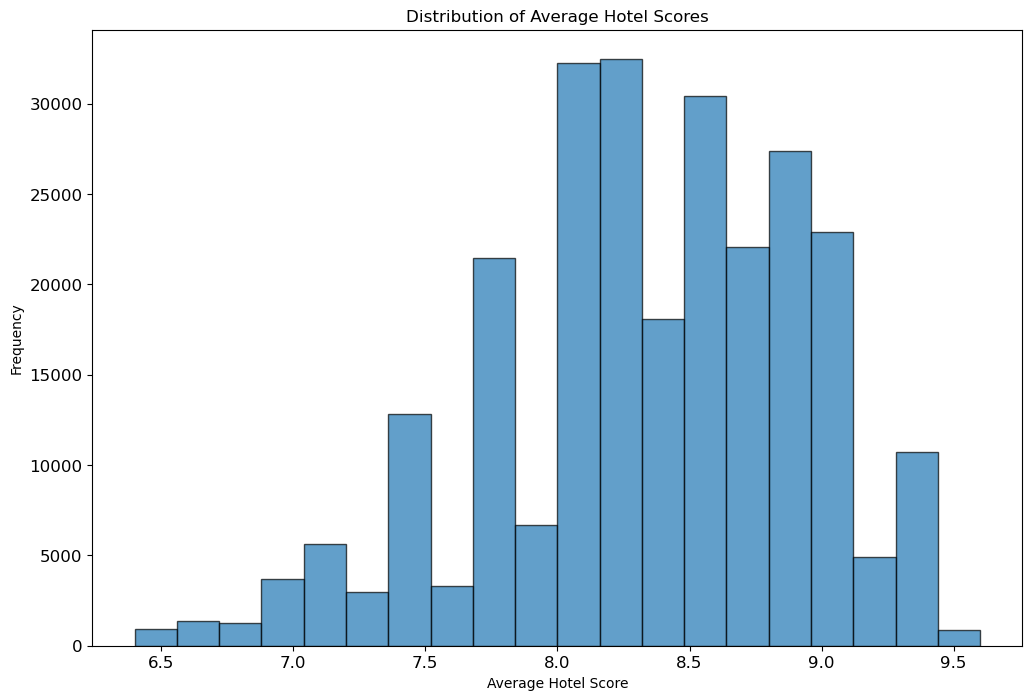

In [52]:
#  histogram for Average Hotel Score in UK 
fig = plt.figure(figsize=(12, 8))  
plt.hist(uk_df["Average_Score"], bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Average Hotel Score")
plt.ylabel("Frequency")
plt.title("Distribution of Average Hotel Scores")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

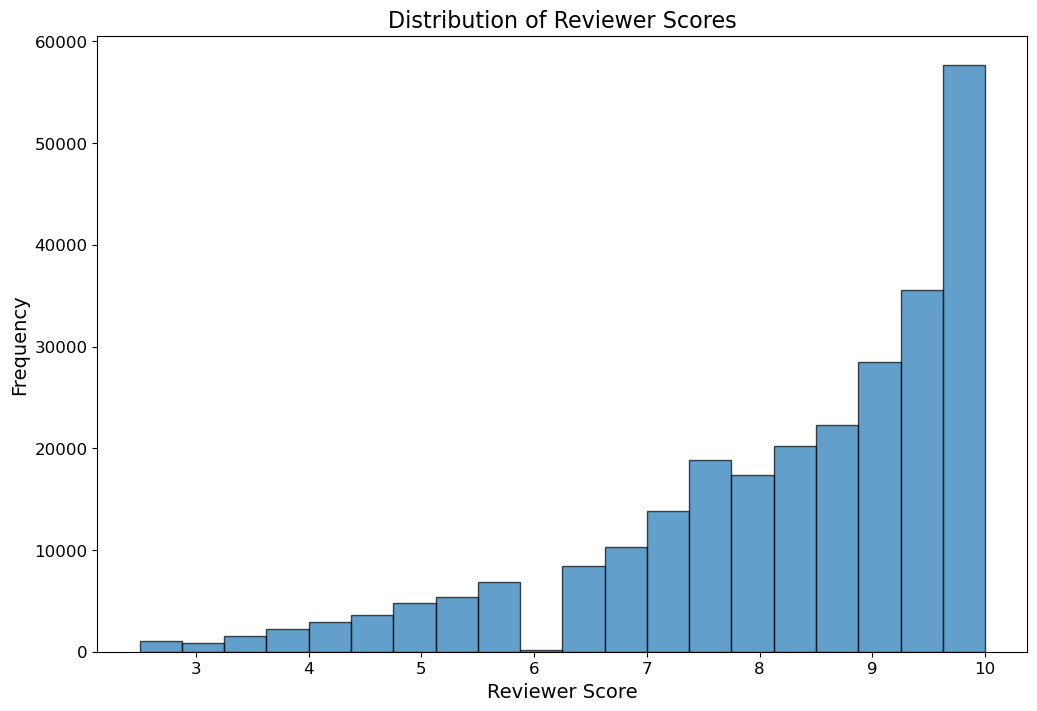

In [54]:
fig = plt.figure(figsize=(12, 8))  
plt.hist(uk_df["Reviewer_Score"], bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Reviewer Score", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Distribution of Reviewer Scores", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [55]:
len(uk_df) # number of obs 

262301

In [56]:
uk_df["Hotel_Name"].nunique() # num of unique hotels 

400

In [57]:
uk_df["Trip_Type"].value_counts()

Trip_Type
Leisure trip     207284
Business trip     45907
Name: count, dtype: int64

In [58]:
uk_df["Trip_Type"].isnull().sum()

9110

In [59]:
uk_df["Traveler_Type"].value_counts()

Traveler_Type
Couple                        131180
Solo traveler                  59745
Group                          29765
Family with young children     28099
Family with older children     12773
Family Room                        4
Triple Hilton Family Room          2
Studio Double Family               1
Luxury Family Room                 1
Triple Family Guestroom            1
Family Suite                       1
Name: count, dtype: int64

In [60]:
uk_df["Traveler_Type"].isnull().sum()

729

In [61]:
uk_df["Room_Type"].value_counts().head(50)

Room_Type
Standard Double Room                       20005
Double Room                                19816
Deluxe Double Room                         19262
Superior Double Room                       17631
Standard Twin Room                          7179
Club Double Room                            5627
Twin Room                                   5572
Classic Double Room                         5455
Executive Double Room                       5405
Queen Room                                  5050
Single Room                                 4537
Superior Twin Room                          4321
Deluxe King Room                            4260
Superior Queen Room                         3954
Standard Double or Twin Room                3697
Double Guest Room                           3425
Standard Single Room                        3249
Superior King Room                          3163
Deluxe Single Room                          2976
Standard Queen Room                         2915
Superior D

In [62]:
uk_df["Room_Type"].isnull().sum()

12453

In [63]:
uk_df["Num_Nights"].isnull().sum()

94

In [64]:
uk_df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,...,lat,lng,Country,Tags_list,Trip_Type,Traveler_Type,Room_Type,Nights_Stayed,Num_Nights,Submission_Device
405,1 15 Templeton Place Earl s Court Kensington a...,244,8/3/2017,8.5,K K Hotel George,Ireland,Really nothing negative to say about this hotel,9,1831,Very comfortable beds smart bathroom good sho...,...,51.491888,-0.194971,Kingdom,"[ Leisure trip , Group , Classic Twin Room ,...",Leisure trip,Group,Classic Twin Room,Stayed 3 nights,3.0,None
406,1 15 Templeton Place Earl s Court Kensington a...,244,8/2/2017,8.5,K K Hotel George,United States of America,No coffee or tea in the room or lobby No one ...,52,1831,No Positive,...,51.491888,-0.194971,Kingdom,"[ Leisure trip , Couple , Classic Twin Room ...",Leisure trip,Couple,Classic Twin Room,Stayed 2 nights,2.0,None
407,1 15 Templeton Place Earl s Court Kensington a...,244,7/20/2017,8.5,K K Hotel George,United States of America,Room was pretty small for the three of us,11,1831,The staff was very friendly and helpful in or...,...,51.491888,-0.194971,Kingdom,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children,Executive King Room,Stayed 6 nights,6.0,None
408,1 15 Templeton Place Earl s Court Kensington a...,244,7/19/2017,8.5,K K Hotel George,Australia,Nothing really,4,1831,We stayed at the hotel at a friend s recommen...,...,51.491888,-0.194971,Kingdom,"[ Leisure trip , Couple , Classic Double Roo...",Leisure trip,Couple,Classic Double Room,Stayed 2 nights,2.0,None
409,1 15 Templeton Place Earl s Court Kensington a...,244,7/18/2017,8.5,K K Hotel George,United States of America,Only cab service to airport is expensive comp...,16,1831,Super location on Division underground line d...,...,51.491888,-0.194971,Kingdom,"[ Leisure trip , Group , Classic Twin Room ,...",Leisure trip,Group,Classic Twin Room,Stayed 6 nights,6.0,None


In [66]:
# This create room Room Capacity . It can be family, triple, twin, single , Double/Queen/King, and other

uk=uk_df.copy()


def extract_capacity(room):
    if pd.isna(room):
        return None
    
    text = room.lower()
    
    if "family" in text:
        return "Family"
    if "triple" in text:
        return "Triple"
    if "twin" in text:
        return "Twin"
    if "single" in text:
        return "Single"
    if any(x in text for x in ["double", "queen", "king"]):
        return "Double/Queen/King"
    
    return "Other"

uk["Room_Capacity"] = uk["Room_Type"].apply(extract_capacity)
uk.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,...,lng,Country,Tags_list,Trip_Type,Traveler_Type,Room_Type,Nights_Stayed,Num_Nights,Submission_Device,Room_Capacity
405,1 15 Templeton Place Earl s Court Kensington a...,244,8/3/2017,8.5,K K Hotel George,Ireland,Really nothing negative to say about this hotel,9,1831,Very comfortable beds smart bathroom good sho...,...,-0.194971,Kingdom,"[ Leisure trip , Group , Classic Twin Room ,...",Leisure trip,Group,Classic Twin Room,Stayed 3 nights,3.0,None,Twin
406,1 15 Templeton Place Earl s Court Kensington a...,244,8/2/2017,8.5,K K Hotel George,United States of America,No coffee or tea in the room or lobby No one ...,52,1831,No Positive,...,-0.194971,Kingdom,"[ Leisure trip , Couple , Classic Twin Room ...",Leisure trip,Couple,Classic Twin Room,Stayed 2 nights,2.0,None,Twin
407,1 15 Templeton Place Earl s Court Kensington a...,244,7/20/2017,8.5,K K Hotel George,United States of America,Room was pretty small for the three of us,11,1831,The staff was very friendly and helpful in or...,...,-0.194971,Kingdom,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children,Executive King Room,Stayed 6 nights,6.0,None,Double/Queen/King
408,1 15 Templeton Place Earl s Court Kensington a...,244,7/19/2017,8.5,K K Hotel George,Australia,Nothing really,4,1831,We stayed at the hotel at a friend s recommen...,...,-0.194971,Kingdom,"[ Leisure trip , Couple , Classic Double Roo...",Leisure trip,Couple,Classic Double Room,Stayed 2 nights,2.0,None,Double/Queen/King
409,1 15 Templeton Place Earl s Court Kensington a...,244,7/18/2017,8.5,K K Hotel George,United States of America,Only cab service to airport is expensive comp...,16,1831,Super location on Division underground line d...,...,-0.194971,Kingdom,"[ Leisure trip , Group , Classic Twin Room ,...",Leisure trip,Group,Classic Twin Room,Stayed 6 nights,6.0,None,Twin


In [67]:
# Quality Tier: This determine the type of the rook or quality of the room: suit, premium, Deluxe, superior, standard. 
def extract_quality(room):
    if pd.isna(room):
        return None
    
    text = room.lower()
    
    if "suite" in text:
        return "Suite"
    if any(x in text for x in ["executive", "club", "premium", "luxury"]):
        return "Premium"
    if "deluxe" in text:
        return "Deluxe"
    if "superior" in text:
        return "Superior"
    
    return "Standard"

uk["Quality_Tier"] = uk["Room_Type"].apply(extract_quality)
uk.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,...,Country,Tags_list,Trip_Type,Traveler_Type,Room_Type,Nights_Stayed,Num_Nights,Submission_Device,Room_Capacity,Quality_Tier
405,1 15 Templeton Place Earl s Court Kensington a...,244,8/3/2017,8.5,K K Hotel George,Ireland,Really nothing negative to say about this hotel,9,1831,Very comfortable beds smart bathroom good sho...,...,Kingdom,"[ Leisure trip , Group , Classic Twin Room ,...",Leisure trip,Group,Classic Twin Room,Stayed 3 nights,3.0,None,Twin,Standard
406,1 15 Templeton Place Earl s Court Kensington a...,244,8/2/2017,8.5,K K Hotel George,United States of America,No coffee or tea in the room or lobby No one ...,52,1831,No Positive,...,Kingdom,"[ Leisure trip , Couple , Classic Twin Room ...",Leisure trip,Couple,Classic Twin Room,Stayed 2 nights,2.0,None,Twin,Standard
407,1 15 Templeton Place Earl s Court Kensington a...,244,7/20/2017,8.5,K K Hotel George,United States of America,Room was pretty small for the three of us,11,1831,The staff was very friendly and helpful in or...,...,Kingdom,"[ Leisure trip , Family with young children ,...",Leisure trip,Family with young children,Executive King Room,Stayed 6 nights,6.0,None,Double/Queen/King,Premium
408,1 15 Templeton Place Earl s Court Kensington a...,244,7/19/2017,8.5,K K Hotel George,Australia,Nothing really,4,1831,We stayed at the hotel at a friend s recommen...,...,Kingdom,"[ Leisure trip , Couple , Classic Double Roo...",Leisure trip,Couple,Classic Double Room,Stayed 2 nights,2.0,None,Double/Queen/King,Standard
409,1 15 Templeton Place Earl s Court Kensington a...,244,7/18/2017,8.5,K K Hotel George,United States of America,Only cab service to airport is expensive comp...,16,1831,Super location on Division underground line d...,...,Kingdom,"[ Leisure trip , Group , Classic Twin Room ,...",Leisure trip,Group,Classic Twin Room,Stayed 6 nights,6.0,None,Twin,Standard


In [68]:
uk["Quality_Tier"].value_counts()

Quality_Tier
Standard    138833
Superior     42560
Deluxe       39727
Premium      22397
Suite         6331
Name: count, dtype: int64

In [69]:
uk["Quality_Tier"].isnull().sum()

12453

In [70]:
uk1=uk.copy() # taking the copy of the last data and then droping the columns which is not needed. 

cols_to_drop = [
    "Negative_Review",
    "Positive_Review",
    "Tags",   # raw tags
    "Reviewer_Nationality",
    "Hotel_Address",
    "Country",
    "lat",
    "lng",
    "Total_Number_of_Reviews_Reviewer_Has_Given",
    "Submission_Device",
    "Nights_Stayed",
    "Room_Type",
    "Tags_list"
]

uk1= uk1.drop(columns=cols_to_drop, errors="ignore")
uk1

,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Trip_Type,Traveler_Type,Num_Nights,Room_Capacity,Quality_Tier
405,244,8/3/2017,8.5,K K Hotel George,9,1831,18,9.6,0 days,Leisure trip,Group,3.0,Twin,Standard
406,244,8/2/2017,8.5,K K Hotel George,52,1831,0,7.1,1 days,Leisure trip,Couple,2.0,Twin,Standard
407,244,7/20/2017,8.5,K K Hotel George,11,1831,27,9.2,14 days,Leisure trip,Family with young children,6.0,Double/Queen/King,Premium
408,244,7/19/2017,8.5,K K Hotel George,4,1831,66,9.6,15 days,Leisure trip,Couple,2.0,Double/Queen/King,Standard
409,244,7/18/2017,8.5,K K Hotel George,16,1831,60,8.3,16 days,Leisure trip,Group,6.0,Twin,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515408,1172,8/5/2015,7.8,Holiday Inn London Kensington,11,5945,0,9.6,729 day,Leisure trip,Couple,1.0,Double/Queen/King,Standard
515409,1172,8/4/2015,7.8,Holiday Inn London Kensington,7,5945,7,10.0,730 day,Leisure trip,Couple,1.0,Double/Queen/King,Superior
515410,1172,8/4/2015,7.8,Holiday Inn London Kensington,24,5945,5,5.0,730 day,Leisure trip,Couple,2.0,Double/Queen/King,Premium
515411,1172,8/4/2015,7.8,Holiday Inn London Kensington,7,5945,0,8.8,730 day,None,Couple,1.0,Double/Queen/King,Standard


In [71]:
# Extracting Month from Review_Date
uk1["Review_Date"] = pd.to_datetime(uk1["Review_Date"])
uk1["Year_Month"] = uk1["Review_Date"].dt.to_period("M")

In [72]:
uk1 = uk1.drop(columns=["Review_Date"])

In [73]:
uk1.head(20)

,Additional_Number_of_Scoring,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Trip_Type,Traveler_Type,Num_Nights,Room_Capacity,Quality_Tier,Year_Month
405,244,8.5,K K Hotel George,9,1831,18,9.6,0 days,Leisure trip,Group,3.0,Twin,Standard,2017-08
406,244,8.5,K K Hotel George,52,1831,0,7.1,1 days,Leisure trip,Couple,2.0,Twin,Standard,2017-08
407,244,8.5,K K Hotel George,11,1831,27,9.2,14 days,Leisure trip,Family with young children,6.0,Double/Queen/King,Premium,2017-07
408,244,8.5,K K Hotel George,4,1831,66,9.6,15 days,Leisure trip,Couple,2.0,Double/Queen/King,Standard,2017-07
409,244,8.5,K K Hotel George,16,1831,60,8.3,16 days,Leisure trip,Group,6.0,Twin,Standard,2017-07
410,244,8.5,K K Hotel George,24,1831,68,9.2,24 days,Leisure trip,Couple,4.0,Twin,Standard,2017-07
411,244,8.5,K K Hotel George,12,1831,38,9.6,28 days,Leisure trip,Group,4.0,Triple,Standard,2017-07
412,244,8.5,K K Hotel George,94,1831,23,5.8,34 days,Leisure trip,Couple,1.0,Double/Queen/King,Standard,2017-06
413,244,8.5,K K Hotel George,40,1831,25,6.7,37 days,Leisure trip,Group,4.0,Triple,Standard,2017-06
414,244,8.5,K K Hotel George,18,1831,25,8.3,37 days,Leisure trip,Couple,3.0,Double/Queen/King,Standard,2017-06


In [74]:
uk1.isnull().sum()

Additional_Number_of_Scoring             0
Average_Score                            0
Hotel_Name                               0
Review_Total_Negative_Word_Counts        0
Total_Number_of_Reviews                  0
Review_Total_Positive_Word_Counts        0
Reviewer_Score                           0
days_since_review                        0
Trip_Type                             9110
Traveler_Type                          729
Num_Nights                              94
Room_Capacity                        12453
Quality_Tier                         12453
Year_Month                               0
dtype: int64

In [75]:
uk1['Traveler_Type'].value_counts()

Traveler_Type
Couple                        131180
Solo traveler                  59745
Group                          29765
Family with young children     28099
Family with older children     12773
Family Room                        4
Triple Hilton Family Room          2
Studio Double Family               1
Luxury Family Room                 1
Triple Family Guestroom            1
Family Suite                       1
Name: count, dtype: int64

In [76]:
# this for the main model : First we try to use the important variables like Total_Number_of_Reviews(review volume or 
# quantity) and Review_Total_Negative_Word_Counts Review_Total_Positive_Word_Counts( qaulity of interview) and then for 
# stydying the hetergenous effect or robustness check we later use the variables that we droping here. 


uk2=uk1.copy()


cols_to_drop = [
    'Trip_Type',
    'Traveler_Type',
    'Num_Nights',
    'Room_Capacity',
    'Quality_Tier',
    
  
]

uk2= uk2.drop(columns=cols_to_drop, errors="ignore")
uk2

,Additional_Number_of_Scoring,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Year_Month
405,244,8.5,K K Hotel George,9,1831,18,9.6,0 days,2017-08
406,244,8.5,K K Hotel George,52,1831,0,7.1,1 days,2017-08
407,244,8.5,K K Hotel George,11,1831,27,9.2,14 days,2017-07
408,244,8.5,K K Hotel George,4,1831,66,9.6,15 days,2017-07
409,244,8.5,K K Hotel George,16,1831,60,8.3,16 days,2017-07
...,...,...,...,...,...,...,...,...,...
515408,1172,7.8,Holiday Inn London Kensington,11,5945,0,9.6,729 day,2015-08
515409,1172,7.8,Holiday Inn London Kensington,7,5945,7,10.0,730 day,2015-08
515410,1172,7.8,Holiday Inn London Kensington,24,5945,5,5.0,730 day,2015-08
515411,1172,7.8,Holiday Inn London Kensington,7,5945,0,8.8,730 day,2015-08


In [77]:
uk2 = uk2.reset_index(drop=True)
uk2

,Additional_Number_of_Scoring,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Year_Month
0,244,8.5,K K Hotel George,9,1831,18,9.6,0 days,2017-08
1,244,8.5,K K Hotel George,52,1831,0,7.1,1 days,2017-08
2,244,8.5,K K Hotel George,11,1831,27,9.2,14 days,2017-07
3,244,8.5,K K Hotel George,4,1831,66,9.6,15 days,2017-07
4,244,8.5,K K Hotel George,16,1831,60,8.3,16 days,2017-07
...,...,...,...,...,...,...,...,...,...
262296,1172,7.8,Holiday Inn London Kensington,11,5945,0,9.6,729 day,2015-08
262297,1172,7.8,Holiday Inn London Kensington,7,5945,7,10.0,730 day,2015-08
262298,1172,7.8,Holiday Inn London Kensington,24,5945,5,5.0,730 day,2015-08
262299,1172,7.8,Holiday Inn London Kensington,7,5945,0,8.8,730 day,2015-08


In [78]:
uk2["days_since_review"] = (
    uk2["days_since_review"]
    .str.replace(r"\s*days?", "", regex=True)
    .astype(int)
)

uk2

,Additional_Number_of_Scoring,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Year_Month
0,244,8.5,K K Hotel George,9,1831,18,9.6,0,2017-08
1,244,8.5,K K Hotel George,52,1831,0,7.1,1,2017-08
2,244,8.5,K K Hotel George,11,1831,27,9.2,14,2017-07
3,244,8.5,K K Hotel George,4,1831,66,9.6,15,2017-07
4,244,8.5,K K Hotel George,16,1831,60,8.3,16,2017-07
...,...,...,...,...,...,...,...,...,...
262296,1172,7.8,Holiday Inn London Kensington,11,5945,0,9.6,729,2015-08
262297,1172,7.8,Holiday Inn London Kensington,7,5945,7,10.0,730,2015-08
262298,1172,7.8,Holiday Inn London Kensington,24,5945,5,5.0,730,2015-08
262299,1172,7.8,Holiday Inn London Kensington,7,5945,0,8.8,730,2015-08


In [79]:
uk2.columns

Index(['Additional_Number_of_Scoring', 'Average_Score', 'Hotel_Name',
       'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews',
       'Review_Total_Positive_Word_Counts', 'Reviewer_Score',
       'days_since_review', 'Year_Month'],
      dtype='object')

In [80]:
# the variable like  'Additional_Number_of_Scoring',  'Total_Number_of_Reviews' does not change whithin each hotel
# so they are not good or adding sth beneficial to the model and we remove them. 

cols_to_drop = [ 
    'Additional_Number_of_Scoring',
    'Total_Number_of_Reviews',
]

uk2= uk2.drop(columns=cols_to_drop, errors="ignore")
uk2

,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Year_Month
0,8.5,K K Hotel George,9,18,9.6,0,2017-08
1,8.5,K K Hotel George,52,0,7.1,1,2017-08
2,8.5,K K Hotel George,11,27,9.2,14,2017-07
3,8.5,K K Hotel George,4,66,9.6,15,2017-07
4,8.5,K K Hotel George,16,60,8.3,16,2017-07
...,...,...,...,...,...,...,...
262296,7.8,Holiday Inn London Kensington,11,0,9.6,729,2015-08
262297,7.8,Holiday Inn London Kensington,7,7,10.0,730,2015-08
262298,7.8,Holiday Inn London Kensington,24,5,5.0,730,2015-08
262299,7.8,Holiday Inn London Kensington,7,0,8.8,730,2015-08


In [81]:
panel_uk2 = (
    uk2
    .groupby(["Hotel_Name", "Year_Month"], as_index=False)
    .agg(
        Avg_Reviewer_Score=("Reviewer_Score", "mean"),
        Avg_Average_Score=("Average_Score", "mean"),
        Avg_Neg_Words=("Review_Total_Negative_Word_Counts", "mean"),
        Avg_Pos_Words=("Review_Total_Positive_Word_Counts", "mean"),
        Avg_days_since_review=("days_since_review", "mean"),
        Num_Reviews=("Reviewer_Score", "size")  # count reviews
    )
)

panel_uk2

,Hotel_Name,Year_Month,Avg_Reviewer_Score,Avg_Average_Score,Avg_Neg_Words,Avg_Pos_Words,Avg_days_since_review,Num_Reviews
0,11 Cadogan Gardens,2015-08,10.000000,8.7,0.000000,29.000000,712.500000,2
1,11 Cadogan Gardens,2015-09,7.716667,8.7,13.500000,12.666667,684.666667,6
2,11 Cadogan Gardens,2015-10,8.766667,8.7,14.500000,21.500000,664.833333,6
3,11 Cadogan Gardens,2015-11,6.416667,8.7,23.166667,5.166667,626.666667,6
4,11 Cadogan Gardens,2015-12,8.600000,8.7,35.600000,14.400000,606.800000,5
...,...,...,...,...,...,...,...,...
9415,every hotel Piccadilly,2017-04,8.066667,8.8,25.833333,18.083333,110.333333,12
9416,every hotel Piccadilly,2017-05,8.735000,8.8,9.450000,14.150000,75.700000,20
9417,every hotel Piccadilly,2017-06,9.180000,8.8,14.900000,21.300000,45.400000,10
9418,every hotel Piccadilly,2017-07,7.772727,8.8,22.181818,15.818182,16.454545,11


In [82]:
#  Rounding mean columns to 1 decimal
panel_uk2 = panel_uk2.round({
    "Avg_Reviewer_Score": 1,
    "Avg_Average_Score": 1,
    "Avg_Neg_Words": 1,
    "Avg_Pos_Words": 1,
    "Avg_days_since_review": 1
})

panel_uk2

,Hotel_Name,Year_Month,Avg_Reviewer_Score,Avg_Average_Score,Avg_Neg_Words,Avg_Pos_Words,Avg_days_since_review,Num_Reviews
0,11 Cadogan Gardens,2015-08,10.0,8.7,0.0,29.0,712.5,2
1,11 Cadogan Gardens,2015-09,7.7,8.7,13.5,12.7,684.7,6
2,11 Cadogan Gardens,2015-10,8.8,8.7,14.5,21.5,664.8,6
3,11 Cadogan Gardens,2015-11,6.4,8.7,23.2,5.2,626.7,6
4,11 Cadogan Gardens,2015-12,8.6,8.7,35.6,14.4,606.8,5
...,...,...,...,...,...,...,...,...
9415,every hotel Piccadilly,2017-04,8.1,8.8,25.8,18.1,110.3,12
9416,every hotel Piccadilly,2017-05,8.7,8.8,9.4,14.2,75.7,20
9417,every hotel Piccadilly,2017-06,9.2,8.8,14.9,21.3,45.4,10
9418,every hotel Piccadilly,2017-07,7.8,8.8,22.2,15.8,16.5,11


In [132]:
ukk=panel_uk2.copy()

# Sorting the panel : This ensures lags follow time correctly.
ukk = ukk.sort_values(
    ["Hotel_Name", "Year_Month"]
)

In [133]:
# Creating lagged dependent variable : Avg_Reviewer_Score"

# t-1 lag
ukk["L1_Avg_Reviewer_Score"] = (
    ukk
    .groupby("Hotel_Name")["Avg_Reviewer_Score"]
    .shift(1)
)

# t-2 lag
ukk["L2_Avg_Reviewer_Score"] = (
    ukk
    .groupby("Hotel_Name")["Avg_Reviewer_Score"]
    .shift(2)
)

In [134]:
# Lag review volume

ukk["L1_Num_Reviews"] = (
    ukk
    .groupby("Hotel_Name")["Num_Reviews"]
    .shift(1)
)

ukk["L2_Num_Reviews"] = (
    ukk
    .groupby("Hotel_Name")["Num_Reviews"]
    .shift(2)
)


In [135]:
# Lag positive sentiment

ukk["L1_Pos_Words"] = (
    ukk
    .groupby("Hotel_Name")["Avg_Pos_Words"]
    .shift(1)
)

ukk["L2_Pos_Words"] = (
    ukk
    .groupby("Hotel_Name")["Avg_Pos_Words"]
    .shift(2)
)

In [142]:
# Lag negative sentiment

ukk["L1_Neg_Words"] = (
    ukk
    .groupby("Hotel_Name")["Avg_Neg_Words"]
    .shift(1)
)

ukk["L2_Neg_Words"] = (
    ukk
    .groupby("Hotel_Name")["Avg_Neg_Words"]
    .shift(2)
)

In [145]:
# Removing NaN values from the table. 

lag_cols = [
    "L1_Avg_Reviewer_Score", "L2_Avg_Reviewer_Score",
    "L1_Num_Reviews", "L2_Num_Reviews",
    "L1_Pos_Words", "L2_Pos_Words",
    "L1_Neg_Words", "L2_Neg_Words"
]

ukk= ukk.dropna(subset=lag_cols)
ukk

,Hotel_Name,Year_Month,Avg_Reviewer_Score,Avg_Average_Score,Avg_Neg_Words,Avg_Pos_Words,Avg_days_since_review,Num_Reviews,L1_Avg_Reviewer_Score,L2_Avg_Reviewer_Score,...,L2_Num_Reviews,L1_Pos_Words,L2_Pos_Words,L1_Neg_Words,L2_Neg_Words,D_Avg_Reviewer_Score,D_L1_Avg_Reviewer_Score,D_Num_Reviews,D_Pos_Words,D_Neg_Words
4,11 Cadogan Gardens,2015-12,8.6,8.7,35.6,14.4,606.8,5,6.4,8.8,...,6.0,5.2,21.5,23.2,14.5,2.2,-2.4,-1.0,9.2,12.4
5,11 Cadogan Gardens,2016-01,9.6,8.7,17.5,18.5,558.0,2,8.6,6.4,...,6.0,14.4,5.2,35.6,23.2,1.0,2.2,-3.0,4.1,-18.1
6,11 Cadogan Gardens,2016-02,6.8,8.7,25.7,7.0,543.7,3,9.6,8.6,...,5.0,18.5,14.4,17.5,35.6,-2.8,1.0,1.0,-11.5,8.2
7,11 Cadogan Gardens,2016-03,7.8,8.7,29.5,3.5,498.5,2,6.8,9.6,...,2.0,7.0,18.5,25.7,17.5,1.0,-2.8,-1.0,-3.5,3.8
8,11 Cadogan Gardens,2016-04,10.0,8.7,0.0,37.0,476.0,1,7.8,6.8,...,3.0,3.5,7.0,29.5,25.7,2.2,1.0,-1.0,33.5,-29.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9415,every hotel Piccadilly,2017-04,8.1,8.8,25.8,18.1,110.3,12,9.2,9.2,...,22.0,14.4,24.9,10.5,17.3,-1.1,0.0,-17.0,3.7,15.3
9416,every hotel Piccadilly,2017-05,8.7,8.8,9.4,14.2,75.7,20,8.1,9.2,...,29.0,18.1,14.4,25.8,10.5,0.6,-1.1,8.0,-3.9,-16.4
9417,every hotel Piccadilly,2017-06,9.2,8.8,14.9,21.3,45.4,10,8.7,8.1,...,12.0,14.2,18.1,9.4,25.8,0.5,0.6,-10.0,7.1,5.5
9418,every hotel Piccadilly,2017-07,7.8,8.8,22.2,15.8,16.5,11,9.2,8.7,...,20.0,21.3,14.2,14.9,9.4,-1.4,0.5,1.0,-5.5,7.3


In [147]:
ukk["D_Avg_Reviewer_Score"] = (
    ukk["Avg_Reviewer_Score"]
    - ukk["L1_Avg_Reviewer_Score"]
)

ukk["D_L1_Avg_Reviewer_Score"] = (
    ukk["L1_Avg_Reviewer_Score"]
    - ukk["L2_Avg_Reviewer_Score"]
)

ukk["D_Num_Reviews"] = (
    ukk["Num_Reviews"]
    - ukk["L1_Num_Reviews"]
)

ukk["D_Pos_Words"] = (
    ukk["Avg_Pos_Words"]
    - ukk["L1_Pos_Words"]
)

ukk["D_Neg_Words"] = (
    ukk["Avg_Neg_Words"]
    - ukk["L1_Neg_Words"]
)

ukk

,Hotel_Name,Year_Month,Avg_Reviewer_Score,Avg_Average_Score,Avg_Neg_Words,Avg_Pos_Words,Avg_days_since_review,Num_Reviews,L1_Avg_Reviewer_Score,L2_Avg_Reviewer_Score,...,L2_Num_Reviews,L1_Pos_Words,L2_Pos_Words,L1_Neg_Words,L2_Neg_Words,D_Avg_Reviewer_Score,D_L1_Avg_Reviewer_Score,D_Num_Reviews,D_Pos_Words,D_Neg_Words
4,11 Cadogan Gardens,2015-12,8.6,8.7,35.6,14.4,606.8,5,6.4,8.8,...,6.0,5.2,21.5,23.2,14.5,2.2,-2.4,-1.0,9.2,12.4
5,11 Cadogan Gardens,2016-01,9.6,8.7,17.5,18.5,558.0,2,8.6,6.4,...,6.0,14.4,5.2,35.6,23.2,1.0,2.2,-3.0,4.1,-18.1
6,11 Cadogan Gardens,2016-02,6.8,8.7,25.7,7.0,543.7,3,9.6,8.6,...,5.0,18.5,14.4,17.5,35.6,-2.8,1.0,1.0,-11.5,8.2
7,11 Cadogan Gardens,2016-03,7.8,8.7,29.5,3.5,498.5,2,6.8,9.6,...,2.0,7.0,18.5,25.7,17.5,1.0,-2.8,-1.0,-3.5,3.8
8,11 Cadogan Gardens,2016-04,10.0,8.7,0.0,37.0,476.0,1,7.8,6.8,...,3.0,3.5,7.0,29.5,25.7,2.2,1.0,-1.0,33.5,-29.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9415,every hotel Piccadilly,2017-04,8.1,8.8,25.8,18.1,110.3,12,9.2,9.2,...,22.0,14.4,24.9,10.5,17.3,-1.1,0.0,-17.0,3.7,15.3
9416,every hotel Piccadilly,2017-05,8.7,8.8,9.4,14.2,75.7,20,8.1,9.2,...,29.0,18.1,14.4,25.8,10.5,0.6,-1.1,8.0,-3.9,-16.4
9417,every hotel Piccadilly,2017-06,9.2,8.8,14.9,21.3,45.4,10,8.7,8.1,...,12.0,14.2,18.1,9.4,25.8,0.5,0.6,-10.0,7.1,5.5
9418,every hotel Piccadilly,2017-07,7.8,8.8,22.2,15.8,16.5,11,9.2,8.7,...,20.0,21.3,14.2,14.9,9.4,-1.4,0.5,1.0,-5.5,7.3


In [150]:
ukk.columns # Do not have missing values because we did not include tag varaible here. So it ie the main data for the 
# analysis and for heteregenous effect we will use another data which has tag. 

Index(['Hotel_Name', 'Year_Month', 'Avg_Reviewer_Score', 'Avg_Average_Score',
       'Avg_Neg_Words', 'Avg_Pos_Words', 'Avg_days_since_review',
       'Num_Reviews', 'L1_Avg_Reviewer_Score', 'L2_Avg_Reviewer_Score',
       'L1_Num_Reviews', 'L2_Num_Reviews', 'L1_Pos_Words', 'L2_Pos_Words',
       'L1_Neg_Words', 'L2_Neg_Words', 'D_Avg_Reviewer_Score',
       'D_L1_Avg_Reviewer_Score', 'D_Num_Reviews', 'D_Pos_Words',
       'D_Neg_Words'],
      dtype='object')

In [55]:
uk1.head()# it is the main data before the major data we wanted to use for our models. 

,Additional_Number_of_Scoring,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Trip_Type,Traveler_Type,Num_Nights,Room_Capacity,Quality_Tier,Year_Month
405,244,8.5,K K Hotel George,9,1831,18,9.6,0 days,Leisure trip,Group,3.0,Twin,Standard,2017-08
406,244,8.5,K K Hotel George,52,1831,0,7.1,1 days,Leisure trip,Couple,2.0,Twin,Standard,2017-08
407,244,8.5,K K Hotel George,11,1831,27,9.2,14 days,Leisure trip,Family with young children,6.0,Double/Queen/King,Premium,2017-07
408,244,8.5,K K Hotel George,4,1831,66,9.6,15 days,Leisure trip,Couple,2.0,Double/Queen/King,Standard,2017-07
409,244,8.5,K K Hotel George,16,1831,60,8.3,16 days,Leisure trip,Group,6.0,Twin,Standard,2017-07


In [84]:
panel2_uk2=uk1.copy() # again removing all constant varaible over time within hotels. 
cols_to_drop = [
    'Additional_Number_of_Scoring',
    'Total_Number_of_Reviews',
    
]

panel2_uk2= panel2_uk2.drop(columns=cols_to_drop, errors="ignore")
panel2_uk2

,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Trip_Type,Traveler_Type,Num_Nights,Room_Capacity,Quality_Tier,Year_Month
405,8.5,K K Hotel George,9,18,9.6,0 days,Leisure trip,Group,3.0,Twin,Standard,2017-08
406,8.5,K K Hotel George,52,0,7.1,1 days,Leisure trip,Couple,2.0,Twin,Standard,2017-08
407,8.5,K K Hotel George,11,27,9.2,14 days,Leisure trip,Family with young children,6.0,Double/Queen/King,Premium,2017-07
408,8.5,K K Hotel George,4,66,9.6,15 days,Leisure trip,Couple,2.0,Double/Queen/King,Standard,2017-07
409,8.5,K K Hotel George,16,60,8.3,16 days,Leisure trip,Group,6.0,Twin,Standard,2017-07
...,...,...,...,...,...,...,...,...,...,...,...,...
515408,7.8,Holiday Inn London Kensington,11,0,9.6,729 day,Leisure trip,Couple,1.0,Double/Queen/King,Standard,2015-08
515409,7.8,Holiday Inn London Kensington,7,7,10.0,730 day,Leisure trip,Couple,1.0,Double/Queen/King,Superior,2015-08
515410,7.8,Holiday Inn London Kensington,24,5,5.0,730 day,Leisure trip,Couple,2.0,Double/Queen/King,Premium,2015-08
515411,7.8,Holiday Inn London Kensington,7,0,8.8,730 day,None,Couple,1.0,Double/Queen/King,Standard,2015-08


In [85]:
panel2_uk2["days_since_review"] = (
    panel2_uk2["days_since_review"]
    .str.replace(r"\s*days?", "", regex=True)
    .astype(int)
)

panel2_uk2

,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Trip_Type,Traveler_Type,Num_Nights,Room_Capacity,Quality_Tier,Year_Month
405,8.5,K K Hotel George,9,18,9.6,0,Leisure trip,Group,3.0,Twin,Standard,2017-08
406,8.5,K K Hotel George,52,0,7.1,1,Leisure trip,Couple,2.0,Twin,Standard,2017-08
407,8.5,K K Hotel George,11,27,9.2,14,Leisure trip,Family with young children,6.0,Double/Queen/King,Premium,2017-07
408,8.5,K K Hotel George,4,66,9.6,15,Leisure trip,Couple,2.0,Double/Queen/King,Standard,2017-07
409,8.5,K K Hotel George,16,60,8.3,16,Leisure trip,Group,6.0,Twin,Standard,2017-07
...,...,...,...,...,...,...,...,...,...,...,...,...
515408,7.8,Holiday Inn London Kensington,11,0,9.6,729,Leisure trip,Couple,1.0,Double/Queen/King,Standard,2015-08
515409,7.8,Holiday Inn London Kensington,7,7,10.0,730,Leisure trip,Couple,1.0,Double/Queen/King,Superior,2015-08
515410,7.8,Holiday Inn London Kensington,24,5,5.0,730,Leisure trip,Couple,2.0,Double/Queen/King,Premium,2015-08
515411,7.8,Holiday Inn London Kensington,7,0,8.8,730,None,Couple,1.0,Double/Queen/King,Standard,2015-08


In [58]:
panel2_uk2 = panel2_uk2.reset_index(drop=True)
panel2_uk2

,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Trip_Type,Traveler_Type,Num_Nights,Room_Capacity,Quality_Tier,Year_Month
0,8.5,K K Hotel George,9,18,9.6,0,Leisure trip,Group,3.0,Twin,Standard,2017-08
1,8.5,K K Hotel George,52,0,7.1,1,Leisure trip,Couple,2.0,Twin,Standard,2017-08
2,8.5,K K Hotel George,11,27,9.2,14,Leisure trip,Family with young children,6.0,Double/Queen/King,Premium,2017-07
3,8.5,K K Hotel George,4,66,9.6,15,Leisure trip,Couple,2.0,Double/Queen/King,Standard,2017-07
4,8.5,K K Hotel George,16,60,8.3,16,Leisure trip,Group,6.0,Twin,Standard,2017-07
...,...,...,...,...,...,...,...,...,...,...,...,...
262296,7.8,Holiday Inn London Kensington,11,0,9.6,729,Leisure trip,Couple,1.0,Double/Queen/King,Standard,2015-08
262297,7.8,Holiday Inn London Kensington,7,7,10.0,730,Leisure trip,Couple,1.0,Double/Queen/King,Superior,2015-08
262298,7.8,Holiday Inn London Kensington,24,5,5.0,730,Leisure trip,Couple,2.0,Double/Queen/King,Premium,2015-08
262299,7.8,Holiday Inn London Kensington,7,0,8.8,730,None,Couple,1.0,Double/Queen/King,Standard,2015-08


In [86]:
panel2_uk2.columns

Index(['Average_Score', 'Hotel_Name', 'Review_Total_Negative_Word_Counts',
       'Review_Total_Positive_Word_Counts', 'Reviewer_Score',
       'days_since_review', 'Trip_Type', 'Traveler_Type', 'Num_Nights',
       'Room_Capacity', 'Quality_Tier', 'Year_Month'],
      dtype='object')

In [87]:
main_types = [
    "Couple",
    "Solo traveler",
    "Group",
    "Family with young children",
    "Family with older children"
]

panel2_uk2 = panel2_uk2[
    panel2_uk2["Traveler_Type"].isin(main_types)
]



panel2_uk2["Traveler_Type"].value_counts()

Traveler_Type
Couple                        131180
Solo traveler                  59745
Group                          29765
Family with young children     28099
Family with older children     12773
Name: count, dtype: int64

In [88]:
panel2_uk2 = panel2_uk2.reset_index(drop=True)
panel2_uk2

,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Trip_Type,Traveler_Type,Num_Nights,Room_Capacity,Quality_Tier,Year_Month
0,8.5,K K Hotel George,9,18,9.6,0,Leisure trip,Group,3.0,Twin,Standard,2017-08
1,8.5,K K Hotel George,52,0,7.1,1,Leisure trip,Couple,2.0,Twin,Standard,2017-08
2,8.5,K K Hotel George,11,27,9.2,14,Leisure trip,Family with young children,6.0,Double/Queen/King,Premium,2017-07
3,8.5,K K Hotel George,4,66,9.6,15,Leisure trip,Couple,2.0,Double/Queen/King,Standard,2017-07
4,8.5,K K Hotel George,16,60,8.3,16,Leisure trip,Group,6.0,Twin,Standard,2017-07
...,...,...,...,...,...,...,...,...,...,...,...,...
261557,7.8,Holiday Inn London Kensington,11,0,9.6,729,Leisure trip,Couple,1.0,Double/Queen/King,Standard,2015-08
261558,7.8,Holiday Inn London Kensington,7,7,10.0,730,Leisure trip,Couple,1.0,Double/Queen/King,Superior,2015-08
261559,7.8,Holiday Inn London Kensington,24,5,5.0,730,Leisure trip,Couple,2.0,Double/Queen/King,Premium,2015-08
261560,7.8,Holiday Inn London Kensington,7,0,8.8,730,None,Couple,1.0,Double/Queen/King,Standard,2015-08


In [90]:
# droping all missing values in variables "Traveler_Type", "Num_Nights" . We are dropin gthem because the number of missing
# values for them are low. 

panel2_uk2 = panel2_uk2.dropna(
    subset=["Traveler_Type", "Num_Nights"]
).copy()

In [91]:
# We want to replace all missing values for "Trip_Type", "Room_Capacity", "Quality_Tier" with "Unknown-TT", "Unknown-RC"
# and "Unknown-QT" . 

panel2_uk2["Trip_Type"] = panel2_uk2["Trip_Type"].fillna("Unknown-TT")
panel2_uk2["Room_Capacity"] = panel2_uk2["Room_Capacity"].fillna("Unknown-RC")
panel2_uk2["Quality_Tier"] = panel2_uk2["Quality_Tier"].fillna("Unknown-QT")

In [92]:
panel2_uk2.isnull().sum()

Average_Score                        0
Hotel_Name                           0
Review_Total_Negative_Word_Counts    0
Review_Total_Positive_Word_Counts    0
Reviewer_Score                       0
days_since_review                    0
Trip_Type                            0
Traveler_Type                        0
Num_Nights                           0
Room_Capacity                        0
Quality_Tier                         0
Year_Month                           0
dtype: int64

In [93]:
panel2_uk2['Room_Capacity'].value_counts()

Room_Capacity
Double/Queen/King    165644
Twin                  45738
Single                15537
Other                 15389
Unknown-RC            12330
Family                 4033
Triple                 2798
Name: count, dtype: int64

In [94]:
panel2_uk2['Quality_Tier'].value_counts()

Quality_Tier
Standard      138413
Superior       42433
Deluxe         39629
Premium        22350
Unknown-QT     12330
Suite           6314
Name: count, dtype: int64

In [95]:
panel2_uk2['Traveler_Type'].value_counts()

Traveler_Type
Couple                        131138
Solo traveler                  59722
Group                          29754
Family with young children     28089
Family with older children     12766
Name: count, dtype: int64

In [96]:
panel2_uk2['Trip_Type'].value_counts()

Trip_Type
Leisure trip     206574
Business trip     45815
Unknown-TT         9080
Name: count, dtype: int64

In [97]:
panel2_uk2 = panel2_uk2.reset_index(drop=True)
panel2_uk2

,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Trip_Type,Traveler_Type,Num_Nights,Room_Capacity,Quality_Tier,Year_Month
0,8.5,K K Hotel George,9,18,9.6,0,Leisure trip,Group,3.0,Twin,Standard,2017-08
1,8.5,K K Hotel George,52,0,7.1,1,Leisure trip,Couple,2.0,Twin,Standard,2017-08
2,8.5,K K Hotel George,11,27,9.2,14,Leisure trip,Family with young children,6.0,Double/Queen/King,Premium,2017-07
3,8.5,K K Hotel George,4,66,9.6,15,Leisure trip,Couple,2.0,Double/Queen/King,Standard,2017-07
4,8.5,K K Hotel George,16,60,8.3,16,Leisure trip,Group,6.0,Twin,Standard,2017-07
...,...,...,...,...,...,...,...,...,...,...,...,...
261464,7.8,Holiday Inn London Kensington,11,0,9.6,729,Leisure trip,Couple,1.0,Double/Queen/King,Standard,2015-08
261465,7.8,Holiday Inn London Kensington,7,7,10.0,730,Leisure trip,Couple,1.0,Double/Queen/King,Superior,2015-08
261466,7.8,Holiday Inn London Kensington,24,5,5.0,730,Leisure trip,Couple,2.0,Double/Queen/King,Premium,2015-08
261467,7.8,Holiday Inn London Kensington,7,0,8.8,730,Unknown-TT,Couple,1.0,Double/Queen/King,Standard,2015-08


In [109]:
# Now we want to convert the categorical variable in dummy or on hot coding. TT is abbreviation for Trip_Type. 
# So for Trip_Type , this variable will be expanded from one column or variable into 3 varaibles. The TT_unkown is 
# the all missing values in this variable. 

uk3=panel2_uk2.copy()

uk3["TT_Leisure"] = (
    uk3["Trip_Type"] == "Leisure trip"
).astype(int)

# Business trip dummy
uk3["TT_Business"] = (
    uk3["Trip_Type"] == "Business trip"
).astype(int)

# Unknown trip dummy
uk3["TT_Unknown"] = (
    uk3["Trip_Type"] == "Unknown-TT"
).astype(int)

uk3

,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Trip_Type,Traveler_Type,Num_Nights,Room_Capacity,Quality_Tier,Year_Month,TT_Leisure,TT_Business,TT_Unknown
0,8.5,K K Hotel George,9,18,9.6,0,Leisure trip,Group,3.0,Twin,Standard,2017-08,1,0,0
1,8.5,K K Hotel George,52,0,7.1,1,Leisure trip,Couple,2.0,Twin,Standard,2017-08,1,0,0
2,8.5,K K Hotel George,11,27,9.2,14,Leisure trip,Family with young children,6.0,Double/Queen/King,Premium,2017-07,1,0,0
3,8.5,K K Hotel George,4,66,9.6,15,Leisure trip,Couple,2.0,Double/Queen/King,Standard,2017-07,1,0,0
4,8.5,K K Hotel George,16,60,8.3,16,Leisure trip,Group,6.0,Twin,Standard,2017-07,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261464,7.8,Holiday Inn London Kensington,11,0,9.6,729,Leisure trip,Couple,1.0,Double/Queen/King,Standard,2015-08,1,0,0
261465,7.8,Holiday Inn London Kensington,7,7,10.0,730,Leisure trip,Couple,1.0,Double/Queen/King,Superior,2015-08,1,0,0
261466,7.8,Holiday Inn London Kensington,24,5,5.0,730,Leisure trip,Couple,2.0,Double/Queen/King,Premium,2015-08,1,0,0
261467,7.8,Holiday Inn London Kensington,7,0,8.8,730,Unknown-TT,Couple,1.0,Double/Queen/King,Standard,2015-08,0,0,1


In [110]:
# for Traveler Type 

uk3["TR_Couple"] = (
    uk3["Traveler_Type"] == "Couple"
).astype(int)

# Solo traveler
uk3["TR_Solo"] = (
    uk3["Traveler_Type"] == "Solo traveler"
).astype(int)

# Group
uk3["TR_Group"] = (
    uk3["Traveler_Type"] == "Group"
).astype(int)

# Family with young children
uk3["TR_Family_Young"] = (
    uk3["Traveler_Type"] == "Family with young children"
).astype(int)

# Family with older children
uk3["TR_Family_Older"] = (
    uk3["Traveler_Type"] == "Family with older children"
).astype(int)

uk3

,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Trip_Type,Traveler_Type,Num_Nights,Room_Capacity,Quality_Tier,Year_Month,TT_Leisure,TT_Business,TT_Unknown,TR_Couple,TR_Solo,TR_Group,TR_Family_Young,TR_Family_Older
0,8.5,K K Hotel George,9,18,9.6,0,Leisure trip,Group,3.0,Twin,Standard,2017-08,1,0,0,0,0,1,0,0
1,8.5,K K Hotel George,52,0,7.1,1,Leisure trip,Couple,2.0,Twin,Standard,2017-08,1,0,0,1,0,0,0,0
2,8.5,K K Hotel George,11,27,9.2,14,Leisure trip,Family with young children,6.0,Double/Queen/King,Premium,2017-07,1,0,0,0,0,0,1,0
3,8.5,K K Hotel George,4,66,9.6,15,Leisure trip,Couple,2.0,Double/Queen/King,Standard,2017-07,1,0,0,1,0,0,0,0
4,8.5,K K Hotel George,16,60,8.3,16,Leisure trip,Group,6.0,Twin,Standard,2017-07,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261464,7.8,Holiday Inn London Kensington,11,0,9.6,729,Leisure trip,Couple,1.0,Double/Queen/King,Standard,2015-08,1,0,0,1,0,0,0,0
261465,7.8,Holiday Inn London Kensington,7,7,10.0,730,Leisure trip,Couple,1.0,Double/Queen/King,Superior,2015-08,1,0,0,1,0,0,0,0
261466,7.8,Holiday Inn London Kensington,24,5,5.0,730,Leisure trip,Couple,2.0,Double/Queen/King,Premium,2015-08,1,0,0,1,0,0,0,0
261467,7.8,Holiday Inn London Kensington,7,0,8.8,730,Unknown-TT,Couple,1.0,Double/Queen/King,Standard,2015-08,0,0,1,1,0,0,0,0


In [111]:
# for room capacity 

uk3["RC_Double_Queen_King"] = (
    uk3["Room_Capacity"] == "Double/Queen/King"
).astype(int)

# Twin
uk3["RC_Twin"] = (
    uk3["Room_Capacity"] == "Twin"
).astype(int)

# Single
uk3["RC_Single"] = (
    uk3["Room_Capacity"] == "Single"
).astype(int)

# Family
uk3["RC_Family"] = (
    uk3["Room_Capacity"] == "Family"
).astype(int)

# Triple
uk3["RC_Triple"] = (
    uk3["Room_Capacity"] == "Triple"
).astype(int)

# Other
uk3["RC_Other"] = (
    uk3["Room_Capacity"] == "Other"
).astype(int)

# Unknown
uk3["RC_Unknown"] = (
    uk3["Room_Capacity"] == "Unknown-RC"
).astype(int)


uk3

,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Trip_Type,Traveler_Type,Num_Nights,Room_Capacity,...,TR_Group,TR_Family_Young,TR_Family_Older,RC_Double_Queen_King,RC_Twin,RC_Single,RC_Family,RC_Triple,RC_Other,RC_Unknown
0,8.5,K K Hotel George,9,18,9.6,0,Leisure trip,Group,3.0,Twin,...,1,0,0,0,1,0,0,0,0,0
1,8.5,K K Hotel George,52,0,7.1,1,Leisure trip,Couple,2.0,Twin,...,0,0,0,0,1,0,0,0,0,0
2,8.5,K K Hotel George,11,27,9.2,14,Leisure trip,Family with young children,6.0,Double/Queen/King,...,0,1,0,1,0,0,0,0,0,0
3,8.5,K K Hotel George,4,66,9.6,15,Leisure trip,Couple,2.0,Double/Queen/King,...,0,0,0,1,0,0,0,0,0,0
4,8.5,K K Hotel George,16,60,8.3,16,Leisure trip,Group,6.0,Twin,...,1,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261464,7.8,Holiday Inn London Kensington,11,0,9.6,729,Leisure trip,Couple,1.0,Double/Queen/King,...,0,0,0,1,0,0,0,0,0,0
261465,7.8,Holiday Inn London Kensington,7,7,10.0,730,Leisure trip,Couple,1.0,Double/Queen/King,...,0,0,0,1,0,0,0,0,0,0
261466,7.8,Holiday Inn London Kensington,24,5,5.0,730,Leisure trip,Couple,2.0,Double/Queen/King,...,0,0,0,1,0,0,0,0,0,0
261467,7.8,Holiday Inn London Kensington,7,0,8.8,730,Unknown-TT,Couple,1.0,Double/Queen/King,...,0,0,0,1,0,0,0,0,0,0


In [112]:
# for Quality Tier 

uk3["QT_Standard"] = (
    uk3["Quality_Tier"] == "Standard"
).astype(int)

# Superior
uk3["QT_Superior"] = (
    uk3["Quality_Tier"] == "Superior"
).astype(int)

# Deluxe
uk3["QT_Deluxe"] = (
    uk3["Quality_Tier"] == "Deluxe"
).astype(int)

# Premium
uk3["QT_Premium"] = (
    uk3["Quality_Tier"] == "Premium"
).astype(int)

# Suite
uk3["QT_Suite"] = (
    uk3["Quality_Tier"] == "Suite"
).astype(int)

# Unknown
uk3["QT_Unknown"] = (
    uk3["Quality_Tier"] == "Unknown-QT"
).astype(int)


In [113]:
uk3.columns

Index(['Average_Score', 'Hotel_Name', 'Review_Total_Negative_Word_Counts',
       'Review_Total_Positive_Word_Counts', 'Reviewer_Score',
       'days_since_review', 'Trip_Type', 'Traveler_Type', 'Num_Nights',
       'Room_Capacity', 'Quality_Tier', 'Year_Month', 'TT_Leisure',
       'TT_Business', 'TT_Unknown', 'TR_Couple', 'TR_Solo', 'TR_Group',
       'TR_Family_Young', 'TR_Family_Older', 'RC_Double_Queen_King', 'RC_Twin',
       'RC_Single', 'RC_Family', 'RC_Triple', 'RC_Other', 'RC_Unknown',
       'QT_Standard', 'QT_Superior', 'QT_Deluxe', 'QT_Premium', 'QT_Suite',
       'QT_Unknown'],
      dtype='object')

In [114]:
# Droping all the main columns that were converted to one hot enconding. 

uk3= uk3.drop(
    columns=[
        "Trip_Type",
        "Traveler_Type",
        "Room_Capacity",
        "Quality_Tier"
    ]
)

uk3

,Average_Score,Hotel_Name,Review_Total_Negative_Word_Counts,Review_Total_Positive_Word_Counts,Reviewer_Score,days_since_review,Num_Nights,Year_Month,TT_Leisure,TT_Business,...,RC_Family,RC_Triple,RC_Other,RC_Unknown,QT_Standard,QT_Superior,QT_Deluxe,QT_Premium,QT_Suite,QT_Unknown
0,8.5,K K Hotel George,9,18,9.6,0,3.0,2017-08,1,0,...,0,0,0,0,1,0,0,0,0,0
1,8.5,K K Hotel George,52,0,7.1,1,2.0,2017-08,1,0,...,0,0,0,0,1,0,0,0,0,0
2,8.5,K K Hotel George,11,27,9.2,14,6.0,2017-07,1,0,...,0,0,0,0,0,0,0,1,0,0
3,8.5,K K Hotel George,4,66,9.6,15,2.0,2017-07,1,0,...,0,0,0,0,1,0,0,0,0,0
4,8.5,K K Hotel George,16,60,8.3,16,6.0,2017-07,1,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261464,7.8,Holiday Inn London Kensington,11,0,9.6,729,1.0,2015-08,1,0,...,0,0,0,0,1,0,0,0,0,0
261465,7.8,Holiday Inn London Kensington,7,7,10.0,730,1.0,2015-08,1,0,...,0,0,0,0,0,1,0,0,0,0
261466,7.8,Holiday Inn London Kensington,24,5,5.0,730,2.0,2015-08,1,0,...,0,0,0,0,0,0,0,1,0,0
261467,7.8,Holiday Inn London Kensington,7,0,8.8,730,1.0,2015-08,0,0,...,0,0,0,0,1,0,0,0,0,0


In [115]:
# now aggregation (mean) within wach hotel on monthly based. 

uk3 = (
    uk3
    .groupby(["Hotel_Name", "Year_Month"], as_index=False)
    .agg(
        # Continuous variables (mean)
        Avg_Average_Score=("Average_Score", "mean"),
        Avg_Neg_Words=("Review_Total_Negative_Word_Counts", "mean"),
        Avg_Pos_Words=("Review_Total_Positive_Word_Counts", "mean"),
        Avg_Reviewer_Score=("Reviewer_Score", "mean"),
        Avg_days_since_review=("days_since_review", "mean"),
        Avg_Num_Nights=("Num_Nights", "mean"),

        # Review count (size) 
        Num_Reviews=("Reviewer_Score", "size"),

        #  Trip_Type shares 
        Share_Leisure=("TT_Leisure", "mean"),
        Share_Business=("TT_Business", "mean"),
        Share_Unknown_TT=("TT_Unknown", "mean"),

        #  Traveler_Type shares 
        Share_Couple=("TR_Couple", "mean"),
        Share_Solo=("TR_Solo", "mean"),
        Share_Group=("TR_Group", "mean"),
        Share_Family_Young=("TR_Family_Young", "mean"),
        Share_Family_Older=("TR_Family_Older", "mean"),

        #  Room_Capacity shares 
        Share_Double_Queen_King=("RC_Double_Queen_King", "mean"),
        Share_Twin=("RC_Twin", "mean"),
        Share_Single=("RC_Single", "mean"),
        Share_Family_Room=("RC_Family", "mean"),
        Share_Triple=("RC_Triple", "mean"),
        Share_Other_Room=("RC_Other", "mean"),
        Share_Unknown_RC=("RC_Unknown", "mean"),

        #  Quality_Tier shares 
        Share_Standard=("QT_Standard", "mean"),
        Share_Superior=("QT_Superior", "mean"),
        Share_Deluxe=("QT_Deluxe", "mean"),
        Share_Premium=("QT_Premium", "mean"),
        Share_Suite=("QT_Suite", "mean"),
        Share_Unknown_QT=("QT_Unknown", "mean"),
    )
)


uk3 

,Hotel_Name,Year_Month,Avg_Average_Score,Avg_Neg_Words,Avg_Pos_Words,Avg_Reviewer_Score,Avg_days_since_review,Avg_Num_Nights,Num_Reviews,Share_Leisure,...,Share_Family_Room,Share_Triple,Share_Other_Room,Share_Unknown_RC,Share_Standard,Share_Superior,Share_Deluxe,Share_Premium,Share_Suite,Share_Unknown_QT
0,11 Cadogan Gardens,2015-08,8.7,0.000000,29.000000,10.000000,712.500000,2.500000,2,1.000000,...,0.0,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.000000
1,11 Cadogan Gardens,2015-09,8.7,13.500000,12.666667,7.716667,684.666667,2.333333,6,0.833333,...,0.0,0.0,0.166667,0.166667,0.000000,0.500000,0.166667,0.0,0.166667,0.166667
2,11 Cadogan Gardens,2015-10,8.7,14.500000,21.500000,8.766667,664.833333,1.833333,6,0.833333,...,0.0,0.0,0.166667,0.000000,0.000000,0.500000,0.000000,0.0,0.500000,0.000000
3,11 Cadogan Gardens,2015-11,8.7,23.166667,5.166667,6.416667,626.666667,1.666667,6,0.666667,...,0.0,0.0,0.000000,0.000000,0.000000,0.333333,0.500000,0.0,0.166667,0.000000
4,11 Cadogan Gardens,2015-12,8.7,35.600000,14.400000,8.600000,606.800000,1.200000,5,1.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.800000,0.000000,0.0,0.200000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9415,every hotel Piccadilly,2017-04,8.8,25.833333,18.083333,8.066667,110.333333,2.583333,12,0.666667,...,0.0,0.0,0.000000,0.000000,0.750000,0.000000,0.250000,0.0,0.000000,0.000000
9416,every hotel Piccadilly,2017-05,8.8,9.450000,14.150000,8.735000,75.700000,1.850000,20,0.950000,...,0.0,0.0,0.000000,0.000000,0.600000,0.000000,0.400000,0.0,0.000000,0.000000
9417,every hotel Piccadilly,2017-06,8.8,14.900000,21.300000,9.180000,45.400000,2.600000,10,0.700000,...,0.0,0.0,0.100000,0.000000,0.900000,0.000000,0.000000,0.0,0.100000,0.000000
9418,every hotel Piccadilly,2017-07,8.8,22.181818,15.818182,7.772727,16.454545,3.000000,11,1.000000,...,0.0,0.0,0.090909,0.000000,0.545455,0.000000,0.363636,0.0,0.090909,0.000000


In [116]:
uk3= uk3.round(1)
uk3

,Hotel_Name,Year_Month,Avg_Average_Score,Avg_Neg_Words,Avg_Pos_Words,Avg_Reviewer_Score,Avg_days_since_review,Avg_Num_Nights,Num_Reviews,Share_Leisure,...,Share_Family_Room,Share_Triple,Share_Other_Room,Share_Unknown_RC,Share_Standard,Share_Superior,Share_Deluxe,Share_Premium,Share_Suite,Share_Unknown_QT
0,11 Cadogan Gardens,2015-08,8.7,0.0,29.0,10.0,712.5,2.5,2,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,11 Cadogan Gardens,2015-09,8.7,13.5,12.7,7.7,684.7,2.3,6,0.8,...,0.0,0.0,0.2,0.2,0.0,0.5,0.2,0.0,0.2,0.2
2,11 Cadogan Gardens,2015-10,8.7,14.5,21.5,8.8,664.8,1.8,6,0.8,...,0.0,0.0,0.2,0.0,0.0,0.5,0.0,0.0,0.5,0.0
3,11 Cadogan Gardens,2015-11,8.7,23.2,5.2,6.4,626.7,1.7,6,0.7,...,0.0,0.0,0.0,0.0,0.0,0.3,0.5,0.0,0.2,0.0
4,11 Cadogan Gardens,2015-12,8.7,35.6,14.4,8.6,606.8,1.2,5,1.0,...,0.0,0.0,0.0,0.0,0.0,0.8,0.0,0.0,0.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9415,every hotel Piccadilly,2017-04,8.8,25.8,18.1,8.1,110.3,2.6,12,0.7,...,0.0,0.0,0.0,0.0,0.8,0.0,0.2,0.0,0.0,0.0
9416,every hotel Piccadilly,2017-05,8.8,9.4,14.2,8.7,75.7,1.8,20,1.0,...,0.0,0.0,0.0,0.0,0.6,0.0,0.4,0.0,0.0,0.0
9417,every hotel Piccadilly,2017-06,8.8,14.9,21.3,9.2,45.4,2.6,10,0.7,...,0.0,0.0,0.1,0.0,0.9,0.0,0.0,0.0,0.1,0.0
9418,every hotel Piccadilly,2017-07,8.8,22.2,15.8,7.8,16.5,3.0,11,1.0,...,0.0,0.0,0.1,0.0,0.5,0.0,0.4,0.0,0.1,0.0


In [117]:
uk3.isnull().sum()

Hotel_Name                 0
Year_Month                 0
Avg_Average_Score          0
Avg_Neg_Words              0
Avg_Pos_Words              0
Avg_Reviewer_Score         0
Avg_days_since_review      0
Avg_Num_Nights             0
Num_Reviews                0
Share_Leisure              0
Share_Business             0
Share_Unknown_TT           0
Share_Couple               0
Share_Solo                 0
Share_Group                0
Share_Family_Young         0
Share_Family_Older         0
Share_Double_Queen_King    0
Share_Twin                 0
Share_Single               0
Share_Family_Room          0
Share_Triple               0
Share_Other_Room           0
Share_Unknown_RC           0
Share_Standard             0
Share_Superior             0
Share_Deluxe               0
Share_Premium              0
Share_Suite                0
Share_Unknown_QT           0
dtype: int64

In [118]:
# We are going for lag effect 

uk4=uk3.copy()

# Sorting the panel ensuring lags follow time correctly.
uk4 = uk4.sort_values(
    ["Hotel_Name", "Year_Month"]
)

In [119]:


# t-1 lag
uk4["L1_Avg_Reviewer_Score"] = (
    uk4
    .groupby("Hotel_Name")["Avg_Reviewer_Score"]
    .shift(1)
)

# t-2 lag
uk4["L2_Avg_Reviewer_Score"] = (
    uk4
    .groupby("Hotel_Name")["Avg_Reviewer_Score"]
    .shift(2)
)

In [120]:
# for Lag review volume

uk4["L1_Num_Reviews"] = (
    uk4
    .groupby("Hotel_Name")["Num_Reviews"]
    .shift(1)
)

uk4["L2_Num_Reviews"] = (
    uk4
    .groupby("Hotel_Name")["Num_Reviews"]
    .shift(2)
)


In [121]:
# Lag positive sentiment

uk4["L1_Pos_Words"] = (
    uk4
    .groupby("Hotel_Name")["Avg_Pos_Words"]
    .shift(1)
)

uk4["L2_Pos_Words"] = (
    uk4
    .groupby("Hotel_Name")["Avg_Pos_Words"]
    .shift(2)
)


In [126]:
# Lag negative sentiment

uk4["L1_Neg_Words"] = (
    uk4
    .groupby("Hotel_Name")["Avg_Neg_Words"]
    .shift(1)
)

uk4["L2_Neg_Words"] = (
    uk4
    .groupby("Hotel_Name")["Avg_Neg_Words"]
    .shift(2)
)

In [127]:
uk4.head()

,Hotel_Name,Year_Month,Avg_Average_Score,Avg_Neg_Words,Avg_Pos_Words,Avg_Reviewer_Score,Avg_days_since_review,Avg_Num_Nights,Num_Reviews,Share_Leisure,...,Share_Suite,Share_Unknown_QT,L1_Avg_Reviewer_Score,L2_Avg_Reviewer_Score,L1_Num_Reviews,L2_Num_Reviews,L1_Pos_Words,L2_Pos_Words,L1_Neg_Words,L2_Neg_Words
0,11 Cadogan Gardens,2015-08,8.7,0.0,29.0,10.0,712.5,2.5,2,1.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11 Cadogan Gardens,2015-09,8.7,13.5,12.7,7.7,684.7,2.3,6,0.8,...,0.2,0.2,10.0,NaN,2.0,NaN,29.0,NaN,0.0,NaN
2,11 Cadogan Gardens,2015-10,8.7,14.5,21.5,8.8,664.8,1.8,6,0.8,...,0.5,0.0,7.7,10.0,6.0,2.0,12.7,29.0,13.5,0.0
3,11 Cadogan Gardens,2015-11,8.7,23.2,5.2,6.4,626.7,1.7,6,0.7,...,0.2,0.0,8.8,7.7,6.0,6.0,21.5,12.7,14.5,13.5
4,11 Cadogan Gardens,2015-12,8.7,35.6,14.4,8.6,606.8,1.2,5,1.0,...,0.2,0.0,6.4,8.8,6.0,6.0,5.2,21.5,23.2,14.5


In [129]:
#  Removing NaN values from the table. 

lag_cols = [
    "L1_Avg_Reviewer_Score", "L2_Avg_Reviewer_Score",
    "L1_Num_Reviews", "L2_Num_Reviews",
    "L1_Pos_Words", "L2_Pos_Words",
    "L1_Neg_Words", "L2_Neg_Words"
]

uk4= uk4.dropna(subset=lag_cols)
uk4

,Hotel_Name,Year_Month,Avg_Average_Score,Avg_Neg_Words,Avg_Pos_Words,Avg_Reviewer_Score,Avg_days_since_review,Avg_Num_Nights,Num_Reviews,Share_Leisure,...,Share_Suite,Share_Unknown_QT,L1_Avg_Reviewer_Score,L2_Avg_Reviewer_Score,L1_Num_Reviews,L2_Num_Reviews,L1_Pos_Words,L2_Pos_Words,L1_Neg_Words,L2_Neg_Words
2,11 Cadogan Gardens,2015-10,8.7,14.5,21.5,8.8,664.8,1.8,6,0.8,...,0.5,0.0,7.7,10.0,6.0,2.0,12.7,29.0,13.5,0.0
3,11 Cadogan Gardens,2015-11,8.7,23.2,5.2,6.4,626.7,1.7,6,0.7,...,0.2,0.0,8.8,7.7,6.0,6.0,21.5,12.7,14.5,13.5
4,11 Cadogan Gardens,2015-12,8.7,35.6,14.4,8.6,606.8,1.2,5,1.0,...,0.2,0.0,6.4,8.8,6.0,6.0,5.2,21.5,23.2,14.5
5,11 Cadogan Gardens,2016-01,8.7,17.5,18.5,9.6,558.0,2.5,2,1.0,...,0.5,0.0,8.6,6.4,5.0,6.0,14.4,5.2,35.6,23.2
6,11 Cadogan Gardens,2016-02,8.7,25.7,7.0,6.8,543.7,1.7,3,0.7,...,0.0,0.0,9.6,8.6,2.0,5.0,18.5,14.4,17.5,35.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9415,every hotel Piccadilly,2017-04,8.8,25.8,18.1,8.1,110.3,2.6,12,0.7,...,0.0,0.0,9.2,9.2,29.0,22.0,14.4,24.9,10.5,17.3
9416,every hotel Piccadilly,2017-05,8.8,9.4,14.2,8.7,75.7,1.8,20,1.0,...,0.0,0.0,8.1,9.2,12.0,29.0,18.1,14.4,25.8,10.5
9417,every hotel Piccadilly,2017-06,8.8,14.9,21.3,9.2,45.4,2.6,10,0.7,...,0.1,0.0,8.7,8.1,20.0,12.0,14.2,18.1,9.4,25.8
9418,every hotel Piccadilly,2017-07,8.8,22.2,15.8,7.8,16.5,3.0,11,1.0,...,0.1,0.0,9.2,8.7,10.0,20.0,21.3,14.2,14.9,9.4


In [ ]:
# so now Avg_Average_Score for 2015-08 goes for L2_Avg_Reviewer_Score and Avg_Average_Score for 2015-09 goes for 
# L1_Avg_Reviewer_Score and the first obs for  Avg_Average_Score  starts with 2015-10 . 

In [130]:
uk4["D_Avg_Reviewer_Score"] = (
    uk4["Avg_Reviewer_Score"]
    - uk4["L1_Avg_Reviewer_Score"]
)

uk4["D_L1_Avg_Reviewer_Score"] = (
    uk4["L1_Avg_Reviewer_Score"]
    - uk4["L2_Avg_Reviewer_Score"]
)

uk4["D_Num_Reviews"] = (
    uk4["Num_Reviews"]
    - uk4["L1_Num_Reviews"]
)

uk4["D_Pos_Words"] = (
    uk4["Avg_Pos_Words"]
    - uk4["L1_Pos_Words"]
)

uk4["D_Neg_Words"] = (
    uk4["Avg_Neg_Words"]
    - uk4["L1_Neg_Words"]
)



In [131]:
# this is the data that we are goign to use for the heteregenous analysis. 

uk4.columns 

Index(['Hotel_Name', 'Year_Month', 'Avg_Average_Score', 'Avg_Neg_Words',
       'Avg_Pos_Words', 'Avg_Reviewer_Score', 'Avg_days_since_review',
       'Avg_Num_Nights', 'Num_Reviews', 'Share_Leisure', 'Share_Business',
       'Share_Unknown_TT', 'Share_Couple', 'Share_Solo', 'Share_Group',
       'Share_Family_Young', 'Share_Family_Older', 'Share_Double_Queen_King',
       'Share_Twin', 'Share_Single', 'Share_Family_Room', 'Share_Triple',
       'Share_Other_Room', 'Share_Unknown_RC', 'Share_Standard',
       'Share_Superior', 'Share_Deluxe', 'Share_Premium', 'Share_Suite',
       'Share_Unknown_QT', 'L1_Avg_Reviewer_Score', 'L2_Avg_Reviewer_Score',
       'L1_Num_Reviews', 'L2_Num_Reviews', 'L1_Pos_Words', 'L2_Pos_Words',
       'L1_Neg_Words', 'L2_Neg_Words', 'D_Avg_Reviewer_Score',
       'D_L1_Avg_Reviewer_Score', 'D_Num_Reviews', 'D_Pos_Words',
       'D_Neg_Words'],
      dtype='object')

# What we have done so far :  Data Preparation and Feature Construction 

In this project, we begin with a large-scale hotel reviews dataset containing more than 500,000 observations and 17 
variables, including reviewer scores, textual sentiment measures (positive and negative word counts), hotel 
characteristics, and detailed trip-related metadata. Given the global scope of the dataset, the first step is to
restrict the analysis to hotels located in the United Kingdom to ensure geographic consistency and reduce heterogeneity
driven by cross-country differences in travel behavior and rating standards.

A key feature of the dataset is the “Tags” variable, which contains rich but unstructured information about the trip
context, such as trip purpose (business vs. leisure), traveler type (couple, solo, family), room type, and length of 
stay. Because this information is embedded in text format, we systematically extract and restructure it into meaningful
categorical variables. Specifically, we construct variables such as Trip Type, Traveler Type, and Room Type, and then 
further simplify these into economically interpretable categories. For example, room types are grouped into broader 
categories such as Single, Twin, Family, and Double/Queen/King (capacity), as well as quality tiers such as Standard,
Superior, Deluxe, Premium, and Suite. This step reduces dimensionality while preserving the most relevant information 
for analysis.

We then examine missing values across variables. Since some of the newly constructed variables (especially those 
derived from tags) contain missing observations, we adopt a dual-data strategy. For the main analysis, we exclude
variables with missing values to maintain a clean and balanced panel. For robustness and heterogeneity analysis, we
retain these  variables and explicitly model their variation using aggregated shares.

Next, we remove variables that do not vary over time within each hotel—such as the total number of reviews and the
number of ratings without text—because they do not contribute to within-hotel variation and therefore do not provide 
identifying power in panel models.

To align the data with a panel structure, we aggregate the dataset at the hotel-month level. This transformation 
converts individual reviews into time-series observations for each hotel. At this level, we compute average reviewer 
scores, average sentiment measures (positive and negative word counts), average recency of reviews, and the total 
number of reviews per month. This step was crucial because it allows us to analyze how hotel ratings evolve over time 
rather than across individual reviews.

To capture dynamic effects, we construct lagged variables for key measures such as reviewer scores, review volume, and
sentiment. Specifically, we include both first-order (t−1) and second-order (t−2) lags. These lagged variables enable 
us to study persistence in ratings and potential delayed effects of sentiment and review activity.

In addition, we transform the data into first differences, creating variables that measure changes over time 
(change in reviewer score, change in number of reviews, and change in sentiment). This transformation is particularly
important for addressing unobserved hotel-specific factors that are constant over time, thereby improving causal 
interpretation in later models.

Finally, for the dataset used in heterogeneity analysis, we convert categorical variables into dummy variables and 
aggregate them into shares at the hotel-month level (share of business travelers, share of family travelers, 
share of deluxe rooms). This allows us to examine how the composition of guests and room types influences hotel ratings
over time.

As a result of these steps, we construct two complementary datasets:

A clean panel dataset (ukk) without missing values, used for the main econometric analysis.
An extended dataset (uk4) that includes richer contextual variables derived from tags, used for robustness checks and 
heterogeneity analysis.

Overall, by the data preparation process we transformed a large, unstructured review dataset into a structured panel suitable for causal and dynamic analysis, while preserving key behavioral and contextual information about hotel reviews.

# Now From this point on , we will start modeling :

We will start by applying different models : 
    
### 1- Pooled OLS, 

### 2- Fixed Effect
    
### 3- GMM 

In [151]:
import statsmodels.api as sm

y = ukk["Avg_Reviewer_Score"]
X = ukk[["Num_Reviews"]]


X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Avg_Reviewer_Score   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     96.61
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           1.14e-22
Time:                        22:40:36   Log-Likelihood:                -9452.7
No. Observations:                7820   AIC:                         1.891e+04
Df Residuals:                    7818   BIC:                         1.892e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           8.5150      0.013    678.299      


## The regression is : 

$$
\text{Avg_Reviewer_Score}_{it}
=
\beta_0
+
\beta_1 \cdot \text{Num_Reviews}_{it}
+
\epsilon_{it}
$$




The first simple model uses only Num_Reviews to predict Avg_Reviewer_Score. The coefficient is negative and statistically significant:

Num_Reviews coefficient=−0.0030

This means that, in the pooled data, hotel-months with more reviews tend to have slightly lower average reviewer scores. However, the explanatory power is very weak, with R² = 0.012, meaning review volume alone explains only about 1.2% of the variation in monthly reviewer scores. So, although the relationship is statistically significant, it is not very strong substantively.

In [152]:

y = ukk["Avg_Reviewer_Score"]

X = ukk[["Num_Reviews", "Avg_Pos_Words", "Avg_Neg_Words"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Avg_Reviewer_Score   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     1457.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:43:48   Log-Likelihood:                -7764.0
No. Observations:                7820   AIC:                         1.554e+04
Df Residuals:                    7816   BIC:                         1.556e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.5722      0.023    380.567

$$
\text{Avg_Reviewer_Score}_{it}
=
\beta_0
+
\beta_1 \cdot \text{Num_Reviews}_{it}
+
\beta_2 \cdot \text{Avg_Pos_Words}_{it}
+
\beta_3 \cdot \text{Avg_Neg_Words}_{it}
+
\epsilon_{it}
$$




In the second model, We added average positive words and average negative words. The model fit improves substantially, with R² increasing from 0.012 to 0.359. This shows that sentiment-related variables explain much more variation in hotel ratings than review volume alone. The results are intuitive: positive review words are positively associated with reviewer scores, while negative review words are negatively associated with reviewer scores.

Specifically:

- Avg_Pos_Words coefficient=0.0345

This means that months with more positive review content tend to have higher reviewer scores.

- Avg_Neg_Words coefficient=−0.0371

This means that months with more negative review content tend to have lower reviewer scores. The negative sentiment coefficient is slightly larger in absolute value than the positive sentiment coefficient, suggesting that negative review content may have a stronger relationship with ratings than positive content.
But the point here is that the number of review has a negative relationship with dependent variable. We can say maybe
More reviews lead to more diverse opinions and can make average slightly drops.


In [155]:

ukk["log_Num_Reviews"] = np.log1p(ukk["Num_Reviews"])
ukk["log_Pos_Words"] = np.log1p(ukk["Avg_Pos_Words"])
ukk["log_Neg_Words"] = np.log1p(ukk["Avg_Neg_Words"])

y = ukk["Avg_Reviewer_Score"]

X = ukk[["log_Num_Reviews", "log_Pos_Words", "log_Neg_Words"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Avg_Reviewer_Score   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     1900.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:54:13   Log-Likelihood:                -7359.5
No. Observations:                7820   AIC:                         1.473e+04
Df Residuals:                    7816   BIC:                         1.475e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               8.4142      0.060    1

$$
\text{Avg_Reviewer_Score}_{it}
=
\beta_0
+
\beta_1 \cdot \log(\text{Num_Reviews}_{it})
+
\beta_2 \cdot \log(\text{Avg_Pos_Words}_{it})
+
\beta_3 \cdot \log(\text{Avg_Neg_Words}_{it})
+
\epsilon_{it}
$$

In the third specification, we used log-transformed variables. This improved the model further, increasing R² to 0.422. Log or transformation also handeled Cond. No well so that it dropped from 140 to 45 and Kurtosis dropped a lot which means less extreme outliers.  This suggests that the relationship between reviews, sentiment, and scores is not purely linear. The log specification captures diminishing marginal effects: for example, the difference between 2 and 5 words may matter more than the difference between 102 and 105 words.

In this model:

- log_Pos_Words coefficient=0.7777

and

- log_Neg_Words coefficient=−0.7480

Again, positive sentiment is strongly associated with higher scores, while negative sentiment is strongly associated with lower scores. Review volume remains negative but smaller:

- log_Num_Reviews coefficient=−0.0197

This means that higher review volume is still associated with slightly lower ratings, but the effect is much weaker compared with sentiment variables. Intrestigly, Positive and negative words have almost equal magnitude but opposite effect.

In [156]:

ukk["log_L1_Num_Reviews"] = np.log1p(ukk["L1_Num_Reviews"])
ukk["log_L1_Pos_Words"]   = np.log1p(ukk["L1_Pos_Words"])
ukk["log_L1_Neg_Words"]   = np.log1p(ukk["L1_Neg_Words"])

y = ukk["Avg_Reviewer_Score"]

X = ukk[[
    "L1_Avg_Reviewer_Score",
    "log_L1_Num_Reviews",
    "log_L1_Pos_Words",
    "log_L1_Neg_Words"
]]

X = sm.add_constant(X)

model = sm.OLS(y, X, missing='drop').fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Avg_Reviewer_Score   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     1545.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:56:25   Log-Likelihood:                -7222.5
No. Observations:                7820   AIC:                         1.446e+04
Df Residuals:                    7815   BIC:                         1.449e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     2.78

$$
\text{Score}_{it}
=
\beta_1 \cdot \text{Score}_{i,t-1}
+
\beta_2 \cdot \log(\text{Num_Reviews}_{i,t-1})
+
\beta_3 \cdot \log(\text{Pos_Words}_{i,t-1})
+
\beta_4 \cdot \log(\text{Neg_Words}_{i,t-1})
+
u_{it}
$$



In the fourth model we included Score t−1 which absorbs most of the reputation effect. So now log_L1_Pos_Words is NOT measuring “good reviews”, it’s measuring deviation from expected sentiment . For instance we can suppose hotel already had high score yesterday and today’s positive words are lower than expected. Then coefficient can turn negative.

The previous models capture correlation but this model tries to capture dynamics OLS cannot handle dynamics properly.
That’s why results look  a bit weird and because of that we need a model like Fixed effect or GMM which capture the dynamic of the data. 


The lagged reviewer score coefficient is:

- L1_Avg_Reviewer_Score coefficient=0.6980

This is large, positive, and statistically significant. It means hotel ratings are highly persistent over time, which means  hotels that had high reviewer scores in the previous month tend to continue having high scores in the current month. This is an important finding because it suggests that hotel reputation and service quality are not random month-to-month outcomes; they carry over strongly over time.

After adding the lagged dependent variable, the model fit improves again, with R² = 0.442. This shows that past reviewer score is one of the strongest predictors of current reviewer score.

However, the lagged sentiment variables have signs that are less intuitive:

- log_L1_Pos_Words coefficient=−0.0847
- log_L1_Neg_Words coefficient=0.0582

This does not necessarily mean that positive words reduce future scores or negative words increase future scores. More likely, once we control for the previous month’s reviewer score, these lagged sentiment variables are capturing adjustment, mean reversion, or correlation with other omitted hotel-month characteristics. This is one reason why pooled OLS should be treated mainly as a descriptive baseline rather than a causal model.

# Overall pooled OLS conclusion

Overall, the pooled OLS results suggest three main patterns. First, review volume has a small but consistently negative
association with average reviewer scores. Second, sentiment variables are much stronger predictors of ratings than
review volume, especially after using log transformations. Third, reviewer scores are highly persistent over time, as
shown by the strong positive coefficient on lagged reviewer score.

However, pooled OLS does not control for unobserved hotel-specific differences, such as hotel quality, location, brand 
reputation, management style, or service standards. Therefore, these results should not be interpreted causally. 
Instead, pooled OLS provides a useful baseline showing the raw associations in the data before moving to fixed effects
and Arellano–Bond GMM models.

# 2- Fixed Effect :

Now we will go for different model specification for Fixed effect. 




---

What Fixed effect model is doing is cmparing the obseravtion or data within each cluster or hotels. Simple intution is that 
instead of comparing Ritz vs cheap hotel FE does comparing  Ritz in January vs Ritz in February. What this comaprison can do is removing  **Omitted variable bias** from time-invariant factors like 

- hotel quality  
- location  
- brand  


| Model | Interpretation |
|------|----------------|
| **OLS** | compares **across hotels** |
| **FE**  | compares **within the same hotel over time** |

But at the end of the story again we would have problem like struggling with dynamics effect (no lagged effects) and not fixing reverse causality and simultaniety. To handle these problem we have to use model like system GMM to address for dynamic effects (lagged dependent variable) and endogeneity / reverse causality. 

In [161]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

ukk_fe = ukk.copy()

ukk_fe["Year_Month"] = ukk_fe["Year_Month"].dt.to_timestamp()

ukk_fe = ukk_fe.set_index(["Hotel_Name", "Year_Month"])

y = ukk_fe["Avg_Reviewer_Score"]

X = ukk_fe[["Num_Reviews", "Avg_Pos_Words", "Avg_Neg_Words"]]

X = sm.add_constant(X)

model = PanelOLS(y, X, entity_effects=True)

fe_results = model.fit()

print(fe_results.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2146
Estimator:                   PanelOLS   R-squared (Between):              0.2992
No. Observations:                7820   R-squared (Within):               0.2146
Date:                Fri, Apr 24 2026   R-squared (Overall):              0.2700
Time:                        23:55:09   Log-likelihood                   -4605.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      676.03
Entities:                         396   P-value                           0.0000
Avg Obs:                       19.747   Distribution:                  F(3,7421)
Min Obs:                       1.0000                                           
Max Obs:                       21.000   F-statistic (robust):             676.03
                            


---

## 1. Entity fixed effects: hotel fixed effects only

$$
\text{Avg_Reviewer_Score}_{it}
=
\beta_1 \cdot \text{Num_Reviews}_{it}
+
\beta_2 \cdot \text{Avg_Pos_Words}_{it}
+
\beta_3 \cdot \text{Avg_Neg_Words}_{it}
+
\alpha_i
+
\epsilon_{it}
$$

 $\alpha_i$ = **hotel fixed effect**

---




In the first fixed-effect model, we include hotel fixed effects but not time fixed effects.

Main results:

- Num_Reviews = 0.0015, significant.

- Avg_Pos_Words = 0.0186, significant.

- Avg_Neg_Words = -0.0206, significant.

- Within R² = 0.2146.


After controlling for fixed differences across hotels, months with more reviews are associated with slightly higher reviewer scores. This is important because in pooled OLS, review volume was negative. The sign changes after fixed effects, meaning the pooled OLS result was probably affected by differences between hotels.

Positive words increase scores, and negative words reduce scores. This is intuitive and statistically strong.

The poolability test p-value = 0.0000, meaning pooled OLS is not appropriate. Hotels are systematically different from each other, so fixed effects are needed.

In [162]:

y = ukk_fe["Avg_Reviewer_Score"]
X = ukk_fe[["Num_Reviews", "Avg_Pos_Words", "Avg_Neg_Words"]]
X = sm.add_constant(X)

model = PanelOLS(y, X, entity_effects=True, time_effects=True)

fe_results = model.fit()

print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2109
Estimator:                   PanelOLS   R-squared (Between):              0.3010
No. Observations:                7820   R-squared (Within):               0.2143
Date:                Fri, Apr 24 2026   R-squared (Overall):              0.2710
Time:                        23:57:50   Log-likelihood                   -4504.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      659.17
Entities:                         396   P-value                           0.0000
Avg Obs:                       19.747   Distribution:                  F(3,7401)
Min Obs:                       1.0000                                           
Max Obs:                       21.000   F-statistic (robust):             659.17
                            

## 2. Entity + time fixed effects

---

As we already told time fixed effects control for anything that **changes over time** anf affects **ALL hotels**. For exmaple


- Seasonality (summer vs winter travel)  
- Holidays (Christmas, New Year)  
- Platform changes (Booking.com updates)  
- Economic conditions  
- Travel trends (tourism shocks)  


Without Time FE the model implicitly assumes  **“Nothing important changes over time”**. This is **not realistic** for hotel data
and create bise like suppose in December there are more travel then there would be higher scores  and as a consequence 
more reviews and and maybe more positive words.   

In this condition the model may conclude that “Positive words cause higher score” but actually it is just a **December effect**

Given the concern we can address it by adding Time FE

$$
\text{Score}_{it}
=
\beta X_{it}
+
\alpha_i
+
\gamma_t
+
\epsilon_{it}
$$

- $\alpha_i$ → hotel fixed effect  
- $\gamma_t$ → **time fixed effect**  

---

Now we can compare: 

- within the **same hotel**
- AND within the **same time period**

Like Ritz in January 2016 vs Ritz in January 2017. In this way we are taking out 

- seasonality  
- global shocks  
- macro trends  

---


After adding time FE some thing can happen to coefficients like coefficients may **shrink**  or some variables may **lose significance**  
It can be a good signal which means we are removing **bias from time effects**

So Time FE  control for **common shocks over time** and makes the estimates **more causal and reliable** . 



Now inthe second regression we have: 

- Num_Reviews = 0.0011, significant.
- Avg_Pos_Words = 0.0189, significant.
- Avg_Neg_Words = -0.0200, significant.
- Within R² ≈ 0.2143.

Interpretation:

This model controls for both hotel-specific factors and common monthly shocks, such as seasonality, travel demand, or platform-wide trends.

The results are very similar to the first FE model. This means the relationships are not only driven by general time trends. Positive sentiment remains strongly positive, negative sentiment remains strongly negative, and review volume remains positive but small.

This is a better model than the hotel-only FE model because it controls for both hotel heterogeneity and time shocks.

In [172]:

ukk_fe = ukk.copy()

ukk_fe["Year_Month"] = ukk_fe["Year_Month"].dt.to_timestamp()

ukk_fe["log_Num_Reviews"] = np.log1p(ukk_fe["Num_Reviews"])
ukk_fe["log_Pos_Words"]   = np.log1p(ukk_fe["Avg_Pos_Words"])
ukk_fe["log_Neg_Words"]   = np.log1p(ukk_fe["Avg_Neg_Words"])

ukk_fe = ukk_fe.set_index(["Hotel_Name", "Year_Month"])

y = ukk_fe["Avg_Reviewer_Score"]
X = ukk_fe[["log_Num_Reviews", "log_Pos_Words", "log_Neg_Words"]]
X = sm.add_constant(X)

model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = model.fit()

print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2635
Estimator:                   PanelOLS   R-squared (Between):              0.3537
No. Observations:                7820   R-squared (Within):               0.2661
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.3220
Time:                        00:25:19   Log-likelihood                   -4234.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      882.65
Entities:                         396   P-value                           0.0000
Avg Obs:                       19.747   Distribution:                  F(3,7401)
Min Obs:                       1.0000                                           
Max Obs:                       21.000   F-statistic (robust):             882.65
                            


---

## 3. Log specification with entity + time fixed effects

$$
\text{Score}_{it}
=
\beta_1 \cdot \log(\text{NumReviews}_{it})
+
\beta_2 \cdot \log(\text{PosWords}_{it})
+
\beta_3 \cdot \log(\text{NegWords}_{it})
+
\alpha_i
+
\gamma_t
+
\epsilon_{it}
$$

---

### 🔹 Components

- $\alpha_i$ → **hotel fixed effects**  
- $\gamma_t$ → **time fixed effects**  

---

This model can have good performance because it controls for **hotel heterogeneity**  ,  **time shocks**  and **handles **skewness** using log transformation  

---


The third model uses logged review volume, logged positive words, and logged negative words.

Main results:

- log_Num_Reviews = 0.0742, significant.
- log_Pos_Words = 0.4760, significant.
- log_Neg_Words = -0.4203, significant.
- Within R² = 0.2661.
- Overall R² = 0.3220.

This model performs better than the previous fixed-effect models. The R² increases from about 0.21 to 0.26, meaning the log transformation explains the data better.

The positive coefficient on log_Num_Reviews means that when a hotel receives more reviews in a month, its average reviewer score tends to be higher, after controlling for hotel and time effects.

The positive sentiment coefficient is large and positive, while the negative sentiment coefficient is large and negative. This means sentiment is still the strongest predictor of reviewer score.

This specification is stronger because logs reduce skewness and allow nonlinear relationships.
 

In [186]:
ukk_fe = ukk.copy()

ukk_fe["Year_Month"] = ukk_fe["Year_Month"].dt.to_timestamp()

ukk_fe["log_Num_Reviews"] = np.log1p(ukk_fe["Num_Reviews"])
ukk_fe["log_Pos_Words"]   = np.log1p(ukk_fe["Avg_Pos_Words"])
ukk_fe["log_Neg_Words"]   = np.log1p(ukk_fe["Avg_Neg_Words"])
ukk_fe["reviews_neg"] = ukk_fe["log_Num_Reviews"] * ukk_fe["log_Neg_Words"]

ukk_fe = ukk_fe.set_index(["Hotel_Name", "Year_Month"])

y = ukk_fe["Avg_Reviewer_Score"]
X = ukk_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    "reviews_neg"
]]

X = sm.add_constant(X)

model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = model.fit()

print(fe_results.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2693
Estimator:                   PanelOLS   R-squared (Between):              0.3841
No. Observations:                7820   R-squared (Within):               0.2741
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.3455
Time:                        12:57:42   Log-likelihood                   -4203.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      681.87
Entities:                         396   P-value                           0.0000
Avg Obs:                       19.747   Distribution:                  F(4,7400)
Min Obs:                       1.0000                                           
Max Obs:                       21.000   F-statistic (robust):             681.87
                            

# 4. Log model with interaction between review volume and negative sentiment

This model adds reviews_neg which capture the interaction between review volume and negative sentiment.

Main results:

- log_Num_Reviews = 0.2903, significant.
- log_Pos_Words = 0.4750, significant.
- log_Neg_Words = -0.2791, significant.
- reviews_neg = -0.0777, significant.
- Within R² = 0.2741.
- Overall R² = 0.3455.

This is an important result. The interaction term is negative and significant. This means that when review volume increases together with negative sentiment, the effect on reviewer score becomes more negative.

In simple words:

More reviews are not always good. More reviews are beneficial when sentiment is positive or neutral, but when more reviews come with more negative content, ratings decline.

This model has the highest R² among the main fixed-effect specifications, so it provides the best explanatory power.

In [187]:
ukk_fe = ukk.copy()

ukk_fe["Year_Month"] = ukk_fe["Year_Month"].dt.to_timestamp()

ukk_fe["log_Num_Reviews"] = np.log1p(ukk_fe["Num_Reviews"])
ukk_fe["log_Pos_Words"]   = np.log1p(ukk_fe["Avg_Pos_Words"])
ukk_fe["log_Neg_Words"]   = np.log1p(ukk_fe["Avg_Neg_Words"])
ukk_fe["reviews_pos"] = ukk_fe["log_Num_Reviews"] * ukk_fe["log_Pos_Words"]

ukk_fe = ukk_fe.set_index(["Hotel_Name", "Year_Month"])

y = ukk_fe["Avg_Reviewer_Score"]
X = ukk_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    "reviews_pos"
]]

X = sm.add_constant(X)

model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = model.fit()

print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2640
Estimator:                   PanelOLS   R-squared (Between):              0.3446
No. Observations:                7820   R-squared (Within):               0.2666
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.3164
Time:                        12:59:18   Log-likelihood                   -4231.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      663.60
Entities:                         396   P-value                           0.0000
Avg Obs:                       19.747   Distribution:                  F(4,7400)
Min Obs:                       1.0000                                           
Max Obs:                       21.000   F-statistic (robust):             663.60
                            

# 5. Log model with interaction between review volume and positive sentiment

This model adds reviews_pos. 

Main results:

- log_Num_Reviews = 0.1622, significant.
- log_Pos_Words = 0.5349, significant.
- log_Neg_Words = -0.4202, significant.
- reviews_pos = -0.0312, significant but smaller.
- Within R² = 0.2666.
- Overall R² = 0.3164.

The interaction between review volume and positive sentiment is negative. This may seem surprising at first, but it can be interpreted as a diminishing return effect.

In simple words, positive words increase ratings, but when positive sentiment and review volume are both already high, the additional benefit becomes smaller.So, positive sentiment matters, but its marginal benefit may decline when review activity is already large. However, this model does not improve fit as much as the negative interaction model.

In [252]:
ukk_fe = ukk.copy()

# Step 2: FIX (this is the key line)
ukk_fe["Year_Month"] = ukk_fe["Year_Month"].dt.to_timestamp()

# Step 3: logs
ukk_fe["log_Num_Reviews"] = np.log1p(ukk_fe["Num_Reviews"])
ukk_fe["log_Pos_Words"]   = np.log1p(ukk_fe["Avg_Pos_Words"])
ukk_fe["log_Neg_Words"]   = np.log1p(ukk_fe["Avg_Neg_Words"])
ukk_fe['Lag_Avg_Reviewer_Score'] = np.log1p(ukk_fe['L1_Avg_Reviewer_Score'])

# Step 4: index
ukk_fe = ukk_fe.set_index(["Hotel_Name", "Year_Month"])

# Model
y = ukk_fe["Avg_Reviewer_Score"]
X = ukk_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    'Lag_Avg_Reviewer_Score'
]]

X = sm.add_constant(X)

model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = model.fit()

print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2640
Estimator:                   PanelOLS   R-squared (Between):              0.3894
No. Observations:                7820   R-squared (Within):               0.2672
Date:                Mon, Apr 27 2026   R-squared (Overall):              0.3451
Time:                        19:15:46   Log-likelihood                   -4231.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      663.56
Entities:                         396   P-value                           0.0000
Avg Obs:                       19.747   Distribution:                  F(4,7400)
Min Obs:                       1.0000                                           
Max Obs:                       21.000   F-statistic (robust):             663.56
                            

In [247]:
ukk_fe.columns

Index(['Avg_Reviewer_Score', 'Avg_Average_Score', 'Avg_Neg_Words',
       'Avg_Pos_Words', 'Avg_days_since_review', 'Num_Reviews',
       'L1_Avg_Reviewer_Score', 'L2_Avg_Reviewer_Score', 'L1_Num_Reviews',
       'L2_Num_Reviews', 'L1_Pos_Words', 'L2_Pos_Words', 'L1_Neg_Words',
       'L2_Neg_Words', 'D_Avg_Reviewer_Score', 'D_L1_Avg_Reviewer_Score',
       'D_Num_Reviews', 'D_Pos_Words', 'D_Neg_Words', 'log_Num_Reviews',
       'log_Pos_Words', 'log_Neg_Words', 'log_L1_Num_Reviews',
       'log_L1_Pos_Words', 'log_L1_Neg_Words', 'reviews_pos'],
      dtype='object')

In [174]:
uk4.columns

Index(['Hotel_Name', 'Year_Month', 'Avg_Average_Score', 'Avg_Neg_Words',
       'Avg_Pos_Words', 'Avg_Reviewer_Score', 'Avg_days_since_review',
       'Avg_Num_Nights', 'Num_Reviews', 'Share_Leisure', 'Share_Business',
       'Share_Unknown_TT', 'Share_Couple', 'Share_Solo', 'Share_Group',
       'Share_Family_Young', 'Share_Family_Older', 'Share_Double_Queen_King',
       'Share_Twin', 'Share_Single', 'Share_Family_Room', 'Share_Triple',
       'Share_Other_Room', 'Share_Unknown_RC', 'Share_Standard',
       'Share_Superior', 'Share_Deluxe', 'Share_Premium', 'Share_Suite',
       'Share_Unknown_QT', 'L1_Avg_Reviewer_Score', 'L2_Avg_Reviewer_Score',
       'L1_Num_Reviews', 'L2_Num_Reviews', 'L1_Pos_Words', 'L2_Pos_Words',
       'L1_Neg_Words', 'L2_Neg_Words', 'D_Avg_Reviewer_Score',
       'D_L1_Avg_Reviewer_Score', 'D_Num_Reviews', 'D_Pos_Words',
       'D_Neg_Words'],
      dtype='object')

# The following is for hetergenous analysis:


 This part is fixed-effects models with heterogeneous effects by trip type, traveler type, room capacity, and room quality.

These models extend the main fixed-effect specification by adding extra variables from the Tags column. The goal is to test whether the relationship between reviews, sentiment, and hotel ratings differs depending on who the traveler is, what type of trip they took, and what room category they booked.


In [250]:
ukk_fe = ukk.copy()

ukk_fe["Year_Month"] = ukk_fe["Year_Month"].dt.to_timestamp()

ukk_fe["log_Num_Reviews"] = np.log1p(ukk_fe["Num_Reviews"])
ukk_fe["log_Pos_Words"]   = np.log1p(ukk_fe["Avg_Pos_Words"])
ukk_fe["log_Neg_Words"]   = np.log1p(ukk_fe["Avg_Neg_Words"])
ukk_fe["log_days_since_review"]   = np.log1p(ukk_fe["Avg_days_since_review"])
# Step 4: index
ukk_fe = ukk_fe.set_index(["Hotel_Name", "Year_Month"])

y = ukk_fe["Avg_Reviewer_Score"]
X = ukk_fe[["log_Num_Reviews", "log_Pos_Words", "log_Neg_Words", "log_days_since_review"]]
X = sm.add_constant(X)

model = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results = model.fit()

print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2646
Estimator:                   PanelOLS   R-squared (Between):              0.3288
No. Observations:                7820   R-squared (Within):              -0.6267
Date:                Mon, Apr 27 2026   R-squared (Overall):             -0.0129
Time:                        15:50:12   Log-likelihood                   -4228.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      665.75
Entities:                         396   P-value                           0.0000
Avg Obs:                       19.747   Distribution:                  F(4,7400)
Min Obs:                       1.0000                                           
Max Obs:                       21.000   F-statistic (robust):             665.75
                            

## 1. Adding days since review

The first model adds log_days_since_review.


- log_Num_Reviews = 0.0761, positive and significant.
- log_Pos_Words = 0.4742, positive and significant.
- log_Neg_Words = -0.4196, negative and significant.
- log_days_since_review = -0.3416, negative and significant.


Older reviews are associated with lower average reviewer scores. This may suggest that more recent reviews tend to be
more favorable, or that the timing of reviews captures changes in hotel performance or platform behavior.
The main review-volume and sentiment results remain almost unchanged.

In [189]:

uk4_fe = uk4.copy()

uk4_fe["Year_Month"] = pd.to_datetime(uk4_fe["Year_Month"].astype(str))

uk4_fe["log_Num_Reviews"] = np.log1p(uk4_fe["Num_Reviews"])
uk4_fe["log_Pos_Words"]   = np.log1p(uk4_fe["Avg_Pos_Words"])
uk4_fe["log_Neg_Words"]   = np.log1p(uk4_fe["Avg_Neg_Words"])

uk4_fe = uk4_fe.set_index(["Hotel_Name", "Year_Month"])

y = uk4_fe["Avg_Reviewer_Score"]

X = uk4_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    "Avg_Num_Nights"
]]

X = sm.add_constant(X)

model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)


fe_nights_results = model.fit()

print(fe_nights_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2613
Estimator:                   PanelOLS   R-squared (Between):              0.3463
No. Observations:                8620   R-squared (Within):               0.2637
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.3192
Time:                        13:01:19   Log-likelihood                   -4750.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      724.59
Entities:                         400   P-value                           0.0000
Avg Obs:                       21.550   Distribution:                  F(4,8194)
Min Obs:                       2.0000                                           
Max Obs:                       23.000   F-statistic (robust):             724.59
                            

# 2. Adding average number of nights

The second model adds Avg_Num_Nights.



- Avg_Num_Nights = -0.0144, marginally significant at about the 10% level.
- Core variables remain stable.

Longer stays are weakly associated with lower reviewer scores. A possible explanation is that longer stays give guests
more time to experience problems. However, this result is not strongly significant, so it might not be interpreted as acritical variable, 

In [257]:

uk4_fe = uk4.copy()

uk4_fe["Year_Month"] = pd.to_datetime(uk4_fe["Year_Month"].astype(str))

uk4_fe["log_Num_Reviews"] = np.log1p(uk4_fe["Num_Reviews"])
uk4_fe["log_Pos_Words"]   = np.log1p(uk4_fe["Avg_Pos_Words"])
uk4_fe["log_Neg_Words"]   = np.log1p(uk4_fe["Avg_Neg_Words"])
uk4_fe["nights_pos"] = uk4_fe["Avg_Num_Nights"] * uk4_fe["log_Pos_Words"]
uk4_fe["nights_neg"] = uk4_fe["Avg_Num_Nights"] * uk4_fe["log_Neg_Words"]

uk4_fe = uk4_fe.set_index(["Hotel_Name", "Year_Month"])

y = uk4_fe["Avg_Reviewer_Score"]

X = uk4_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    "Avg_Num_Nights",
    "nights_pos",
    "nights_neg"
]]

X = sm.add_constant(X)

model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

fe_nights_results = model.fit()

print(fe_nights_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2625
Estimator:                   PanelOLS   R-squared (Between):              0.3477
No. Observations:                8620   R-squared (Within):               0.2649
Date:                Mon, Apr 27 2026   R-squared (Overall):              0.3207
Time:                        23:43:34   Log-likelihood                   -4743.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      485.88
Entities:                         400   P-value                           0.0000
Avg Obs:                       21.550   Distribution:                  F(6,8192)
Min Obs:                       2.0000                                           
Max Obs:                       23.000   F-statistic (robust):             485.88
                            

The results indicate that the length of stay does not exert a direct effect on review scores; however, it plays an important moderating role in how sentiment is translated into ratings. Specifically, the interaction terms show that both positive and negative word effects are attenuated as the number of nights increases.  In other words, while sentiment remains the primary driver of review scores, its marginal impact becomes weaker for longer stays.


A useful way to interpret this finding is to think about how consumers form evaluations over different time horizons. For shorter stays, reviews are likely driven by a limited set of experiences like often a single interaction or event ( check-in quality, room cleanliness, or a specific service failure). As a result, sentiment expressed in the review tends to map strongly into the final rating. A highly positive or negative experience during a short stay can disproportionately influence the overall evaluation.

In contrast, longer stays expose travelers to a broader range of experiences. Over multiple days, guests interact with more aspects of the hotel—staff, facilities, location convenience, and day-to-day service variability. This naturally introduces a form of averaging across experiences. Positive and negative moments may offset each other, leading to a more tempered and balanced final assessment. Consequently, the language used in reviews—while still informative and has a weaker marginal effect on the overall score.

It is important to distinguish this interpretation from a selection-based story in which longer stays are assumed to reflect higher satisfaction. While it is plausible that dissatisfied guests may shorten their stay, the empirical model does not identify such a causal mechanism. Instead, the estimates capture how, conditional on the sentiment expressed in reviews, the length of stay changes the sensitivity of ratings to that sentiment. Therefore, the results should be interpreted as evidence of a moderating effect rather than a direct causal relationship between stay duration and satisfaction.

In general, these findings suggest that review scores are shaped not only by what guests say (sentiment), but also by how long they experience the service. Longer stays appear to dilute the impact of individual experiences, producing ratings that reflect a more aggregated evaluation of the hotel.

In [175]:

uk4_fe = uk4.copy()

uk4_fe["Year_Month"] = pd.to_datetime(uk4_fe["Year_Month"].astype(str))

uk4_fe["log_Num_Reviews"] = np.log1p(uk4_fe["Num_Reviews"])
uk4_fe["log_Pos_Words"]   = np.log1p(uk4_fe["Avg_Pos_Words"])
uk4_fe["log_Neg_Words"]   = np.log1p(uk4_fe["Avg_Neg_Words"])

uk4_fe = uk4_fe.set_index(["Hotel_Name", "Year_Month"])

y = uk4_fe["Avg_Reviewer_Score"]

X = uk4_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    "Share_Leisure",
    "Share_Business",
    "Share_Unknown_TT"
]]

X = sm.add_constant(X)

model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

fe_results = model.fit()

print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2675
Estimator:                   PanelOLS   R-squared (Between):              0.3716
No. Observations:                8620   R-squared (Within):               0.2667
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.3371
Time:                        12:18:14   Log-likelihood                   -4714.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      498.58
Entities:                         400   P-value                           0.0000
Avg Obs:                       21.550   Distribution:                  F(6,8192)
Min Obs:                       2.0000                                           
Max Obs:                       23.000   F-statistic (robust):             498.58
                            

### 3. Trip type shares

This model adds the monthly share of leisure, business, and unknown trip types.


- Share_Leisure is not significant.
- Share_Business is not significant.
- Share_Unknown_TT is not significant.
- Core variables remain significant.

Once hotel fixed effects, time fixed effects, review volume, and sentiment are controlled for, the composition of leisure vs. business travelers does not strongly explain reviewer scores by itself.

So, trip purpose alone does not appear to be a major driver of rating differences.

In [177]:

uk4_fe = uk4.copy()
uk4_fe["Year_Month"] = pd.to_datetime(uk4_fe["Year_Month"].astype(str))

uk4_fe["log_Num_Reviews"] = np.log1p(uk4_fe["Num_Reviews"])
uk4_fe["log_Pos_Words"]   = np.log1p(uk4_fe["Avg_Pos_Words"])
uk4_fe["log_Neg_Words"]   = np.log1p(uk4_fe["Avg_Neg_Words"])
uk4_fe["pos_leisure"] = uk4_fe["log_Pos_Words"] * uk4_fe["Share_Leisure"]
uk4_fe["neg_leisure"] = uk4_fe["log_Neg_Words"] * uk4_fe["Share_Leisure"]

uk4_fe = uk4_fe.set_index(["Hotel_Name", "Year_Month"])
y = uk4_fe["Avg_Reviewer_Score"]

X = uk4_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    "Share_Leisure",
    "Share_Business",
    "pos_leisure",
    "neg_leisure"
]]

X = sm.add_constant(X)


model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

fe_results = model.fit()

print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2681
Estimator:                   PanelOLS   R-squared (Between):              0.3730
No. Observations:                8620   R-squared (Within):               0.2674
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.3382
Time:                        12:24:56   Log-likelihood                   -4710.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      428.64
Entities:                         400   P-value                           0.0000
Avg Obs:                       21.550   Distribution:                  F(7,8191)
Min Obs:                       2.0000                                           
Max Obs:                       23.000   F-statistic (robust):             428.64
                            

### 4. Trip type with sentiment interactions

This model adds interactions between leisure travel and sentiment.


- Share_Business = -0.2115, significant.
- pos_leisure = -0.1098, significant.
- neg_leisure = 0.0580, marginally significant.
- Core sentiment variables remain significant.

Business-traveler-heavy months are associated with lower reviewer scores. This may suggest that business travelers are
more demanding or less emotionally positive in reviews.

The negative coefficient on pos_leisure suggests that positive sentiment has a weaker marginal effect during leisure
-heavy months. In simple terms, positive words still increase ratings, but the increase is smaller when the reviews are
mostly from leisure travelers.

The neg_leisure coefficient is positive but only weakly significant. This could mean negative sentiment is slightly
less damaging in leisure-heavy months, but this result is not strong enough to emphasize heavily.

In [262]:

uk4_fe = uk4.copy()

uk4_fe["Year_Month"] = pd.to_datetime(uk4_fe["Year_Month"].astype(str))

uk4_fe["log_Num_Reviews"] = np.log1p(uk4_fe["Num_Reviews"])
uk4_fe["log_Pos_Words"]   = np.log1p(uk4_fe["Avg_Pos_Words"])
uk4_fe["log_Neg_Words"]   = np.log1p(uk4_fe["Avg_Neg_Words"])

uk4_fe = uk4_fe.set_index(["Hotel_Name", "Year_Month"])

y = uk4_fe["Avg_Reviewer_Score"]

X = uk4_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    "Share_Couple",
    "Share_Solo",
    "Share_Group",
    "Share_Family_Young",
    "Share_Family_Older"
]]

X = sm.add_constant(X)

model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

fe_traveler_results = model.fit()

print(fe_traveler_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2651
Estimator:                   PanelOLS   R-squared (Between):              0.3708
No. Observations:                8620   R-squared (Within):               0.2653
Date:                Tue, Apr 28 2026   R-squared (Overall):              0.3360
Time:                        00:03:04   Log-likelihood                   -4727.7
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      369.38
Entities:                         400   P-value                           0.0000
Avg Obs:                       21.550   Distribution:                  F(8,8190)
Min Obs:                       2.0000                                           
Max Obs:                       23.000   F-statistic (robust):             369.38
                            

# 5. Traveler type shares

This model adds shares of couples, solo travelers, groups, and families.

- Share_Solo = -0.2161, significant.
- Share_Family_Older = -0.1879, marginally significant.
- Other traveler types are not significant.
- Core variables remain stable.

Months with a larger share of solo travelers are associated with lower reviewer scores. Families with older children may also give slightly lower scores, but the evidence is weaker. This suggests some heterogeneity by traveler composition, especially for solo travelers.

In [261]:

uk4_fe = uk4.copy()

uk4_fe["Year_Month"] = pd.to_datetime(uk4_fe["Year_Month"].astype(str))

uk4_fe["log_Num_Reviews"] = np.log1p(uk4_fe["Num_Reviews"])
uk4_fe["log_Pos_Words"]   = np.log1p(uk4_fe["Avg_Pos_Words"])
uk4_fe["log_Neg_Words"]   = np.log1p(uk4_fe["Avg_Neg_Words"])
uk4_fe["pos_solo"] = uk4_fe["log_Pos_Words"] * uk4_fe["Share_Solo"]
uk4_fe["neg_solo"] = uk4_fe["log_Neg_Words"] * uk4_fe["Share_Solo"]

uk4_fe = uk4_fe.set_index(["Hotel_Name", "Year_Month"])

y = uk4_fe["Avg_Reviewer_Score"]

X = uk4_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    "Share_Solo",
    "Share_Couple",
    "Share_Group",
    "Share_Family_Young",
    "Share_Family_Older",
    "pos_solo",
    "neg_solo"
]]

X = sm.add_constant(X)

model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)


fe_traveler_results = model.fit()

print(fe_traveler_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2662
Estimator:                   PanelOLS   R-squared (Between):              0.3731
No. Observations:                8620   R-squared (Within):               0.2663
Date:                Tue, Apr 28 2026   R-squared (Overall):              0.3377
Time:                        00:01:52   Log-likelihood                   -4721.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      297.03
Entities:                         400   P-value                           0.0000
Avg Obs:                       21.550   Distribution:                 F(10,8188)
Min Obs:                       2.0000                                           
Max Obs:                       23.000   F-statistic (robust):             297.03
                            

## 6. Traveler type with solo sentiment interactions

This model adds interactions for solo travelers.


- neg_solo = -0.0998, significant.
- pos_solo = 0.0763, marginally significant.
- Traveler-type shares become mostly insignificant.
- Core variables remain significant.

The negative and significant neg_solo coefficient means that negative sentiment is more damaging when the monthly share of solo travelers is higher. In simple words, Negative reviews from solo-traveler-heavy months are especially associated with lower hotel scores. The positive interaction with solo travelers is only marginally significant, so it is weaker evidence.

In [182]:

uk4_fe = uk4.copy()

uk4_fe["Year_Month"] = pd.to_datetime(uk4_fe["Year_Month"].astype(str))

uk4_fe["log_Num_Reviews"] = np.log1p(uk4_fe["Num_Reviews"])
uk4_fe["log_Pos_Words"]   = np.log1p(uk4_fe["Avg_Pos_Words"])
uk4_fe["log_Neg_Words"]   = np.log1p(uk4_fe["Avg_Neg_Words"])
uk4_fe["neg_family"] = uk4_fe["log_Neg_Words"] * uk4_fe["Share_Family_Room"]

uk4_fe = uk4_fe.set_index(["Hotel_Name", "Year_Month"])

y = uk4_fe["Avg_Reviewer_Score"]

X = uk4_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    "Share_Double_Queen_King",
    "Share_Twin",
    "Share_Single",
    "Share_Family_Room",
    "neg_family"
]]

X = sm.add_constant(X)

model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

fe_room_results = model.fit()

print(fe_room_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2614
Estimator:                   PanelOLS   R-squared (Between):              0.3368
No. Observations:                8620   R-squared (Within):               0.2631
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.3128
Time:                        12:41:32   Log-likelihood                   -4749.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      362.40
Entities:                         400   P-value                           0.0000
Avg Obs:                       21.550   Distribution:                  F(8,8190)
Min Obs:                       2.0000                                           
Max Obs:                       23.000   F-statistic (robust):             362.40
                            

## 7. Room capacity shares

This model adds room-capacity shares such as double/queen/king, twin, single, and family rooms.


- None of the room-capacity variables are significant.
- neg_family is also not significant.
- Core variables remain significant.


Room capacity does not explain much additional variation in reviewer scores after controlling for hotel and time fixed effects. So, whether the month has more double rooms, twin rooms, single rooms, or family rooms does not appear to strongly change ratings.

In [183]:

# Copy data
uk4_fe = uk4.copy()

# Fix time
uk4_fe["Year_Month"] = pd.to_datetime(uk4_fe["Year_Month"].astype(str))

# Log variables
uk4_fe["log_Num_Reviews"] = np.log1p(uk4_fe["Num_Reviews"])
uk4_fe["log_Pos_Words"]   = np.log1p(uk4_fe["Avg_Pos_Words"])
uk4_fe["log_Neg_Words"]   = np.log1p(uk4_fe["Avg_Neg_Words"])

# Set index
uk4_fe = uk4_fe.set_index(["Hotel_Name", "Year_Month"])

# Dependent variable
y = uk4_fe["Avg_Reviewer_Score"]

# Independent variables (drop Share_Standard)
X = uk4_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    "Share_Superior",
    "Share_Deluxe",
    "Share_Premium",
    "Share_Suite"
    # Share_Standard dropped → baseline
]]

# Add constant
X = sm.add_constant(X)

# FE model
model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

# Fit
fe_quality_results = model.fit()

print(fe_quality_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2627
Estimator:                   PanelOLS   R-squared (Between):              0.3016
No. Observations:                8620   R-squared (Within):               0.2643
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.2919
Time:                        12:45:16   Log-likelihood                   -4742.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      416.82
Entities:                         400   P-value                           0.0000
Avg Obs:                       21.550   Distribution:                  F(7,8191)
Min Obs:                       2.0000                                           
Max Obs:                       23.000   F-statistic (robust):             416.82
                            

## 8. Room quality tier

This model adds quality-tier shares.


- Share_Superior = -0.1646, significant.
- Share_Deluxe = -0.1560, significant.
- Share_Premium is not significant.
- Share_Suite is not significant.
- Core variables remain significant.

Months with a higher share of superior or deluxe room reviews are associated with lower reviewer scores compared with the omitted reference category, likely standard rooms. This may seem surprising, but it can make sense becaue guests booking higher-tier rooms may have higher expectations. If the experience does not match those expectations, they may score the hotel more critically.

In [184]:

uk4_fe = uk4.copy()

uk4_fe["Year_Month"] = pd.to_datetime(uk4_fe["Year_Month"].astype(str))


uk4_fe["log_Num_Reviews"] = np.log1p(uk4_fe["Num_Reviews"])
uk4_fe["log_Pos_Words"]   = np.log1p(uk4_fe["Avg_Pos_Words"])
uk4_fe["log_Neg_Words"]   = np.log1p(uk4_fe["Avg_Neg_Words"])
uk4_fe["neg_superior"] = uk4_fe["log_Neg_Words"] * uk4_fe["Share_Superior"]
uk4_fe["neg_deluxe"]   = uk4_fe["log_Neg_Words"] * uk4_fe["Share_Deluxe"]

uk4_fe = uk4_fe.set_index(["Hotel_Name", "Year_Month"])

y = uk4_fe["Avg_Reviewer_Score"]

X = uk4_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    "Share_Superior",
    "Share_Deluxe",
    "Share_Premium",
    "Share_Suite",
    "neg_superior",
    "neg_deluxe"
]]


X = sm.add_constant(X)

model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

fe_quality_results = model.fit()

print(fe_quality_results.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2632
Estimator:                   PanelOLS   R-squared (Between):              0.3063
No. Observations:                8620   R-squared (Within):               0.2648
Date:                Sat, Apr 25 2026   R-squared (Overall):              0.2949
Time:                        12:48:25   Log-likelihood                   -4739.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      324.96
Entities:                         400   P-value                           0.0000
Avg Obs:                       21.550   Distribution:                  F(9,8189)
Min Obs:                       2.0000                                           
Max Obs:                       23.000   F-statistic (robust):             324.96
                            

## 9. Room quality tier with negative sentiment interactions

This model adds interactions between negative sentiment and superior/deluxe rooms.


- Share_Superior = -0.3432, significant.
- Share_Deluxe = -0.1824, weakly significant.
- neg_superior = 0.0700, significant.
- neg_deluxe is not significant.
- Core variables remain significant.


Superior-room-heavy months are associated with lower scores, again supporting the idea that higher room expectations may lead to stricter evaluations. The positive neg_superior interaction means the negative effect of negative words is slightly weaker for superior-room reviews. However, the overall effect of negative sentiment is still negative because the main coefficient on log_Neg_Words remains strongly negative. So this does not mean negative words help scores. It means the negative sentiment penalty is somewhat smaller in superior-room-heavy months.



## Main model (robustness & interpretation)

With all this mpodel specification, we can say the best model is the **log fixed-effects specification**:
which is 

$$
\log(\text{Num_Reviews}) + \log(\text{Pos_Words}) + \log(\text{Neg_Words}) + \text{Hotel FE} + \text{Time FE}
$$


because it is clean, stable, and easy to interpret.

The heterogeneity analysis shows that the main findings are robust after adding tag-based controls. Review volume remains positively associated with scores, positive sentiment remains strongly positive, and negative sentiment remains strongly negative. However, some guest and room compositions matter because business-heavy months, solo-traveler-heavy months, and superior/deluxe-room-heavy months tend to be associated with lower scores, suggesting that traveler expectations and trip context shape how reviews translate into ratings.

## Rbustness check

In this section we will try to use two different methos : 
    
- 1- lead effect (Placebo test)
- 2- Removing some top hotesl in terms of the number of reviews, number of positive words , and negative words. 

In [254]:

ukk_placebo = ukk.copy()

ukk_placebo = ukk_placebo.sort_values(["Hotel_Name", "Year_Month"])

# Creating lead variables: t+1
ukk_placebo["F1_Num_Reviews"] = ukk_placebo.groupby("Hotel_Name")["Num_Reviews"].shift(-1)
ukk_placebo["F1_Pos_Words"]   = ukk_placebo.groupby("Hotel_Name")["Avg_Pos_Words"].shift(-1)
ukk_placebo["F1_Neg_Words"]   = ukk_placebo.groupby("Hotel_Name")["Avg_Neg_Words"].shift(-1)

ukk_placebo["log_F1_Num_Reviews"] = np.log1p(ukk_placebo["F1_Num_Reviews"])
ukk_placebo["log_F1_Pos_Words"]   = np.log1p(ukk_placebo["F1_Pos_Words"])
ukk_placebo["log_F1_Neg_Words"]   = np.log1p(ukk_placebo["F1_Neg_Words"])

ukk_placebo["Year_Month"] = ukk_placebo["Year_Month"].dt.to_timestamp()

ukk_placebo = ukk_placebo.set_index(["Hotel_Name", "Year_Month"])

ukk_placebo = ukk_placebo.dropna(subset=[
    "log_F1_Num_Reviews",
    "log_F1_Pos_Words",
    "log_F1_Neg_Words"
])

y = ukk_placebo["Avg_Reviewer_Score"]

X = ukk_placebo[[
    "log_F1_Num_Reviews",
    "log_F1_Pos_Words",
    "log_F1_Neg_Words"
]]

X = sm.add_constant(X)

model = PanelOLS(y, X, entity_effects=True, time_effects=True)

placebo_results = model.fit(cov_type="clustered", cluster_entity=True)

print(placebo_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.0043
Estimator:                   PanelOLS   R-squared (Between):             -0.0642
No. Observations:                7424   R-squared (Within):               0.0100
Date:                Mon, Apr 27 2026   R-squared (Overall):             -0.0383
Time:                        19:42:01   Log-likelihood                   -4738.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      10.028
Entities:                         395   P-value                           0.0000
Avg Obs:                       18.795   Distribution:                  F(3,7007)
Min Obs:                       1.0000                                           
Max Obs:                       20.000   F-statistic (robust):             6.3461
                            

## Robustness check 1: lead-effect/placebo model

In this model, current reviewer score is regressed on future review volume, future positive words, and future negative
words.

Main results:

- log_F1_Num_Reviews = 0.0829, significant.
- log_F1_Pos_Words = 0.0003, not significant.
- log_F1_Neg_Words = -0.0016, not significant.
- R² = 0.0043
- Within R² = 0.0100

Future sentiment does **NOT** predict current score. This supports the identification strategy.

Now we can say **No reverse causality** or Future reviews are NOT driving current scores and **No mechanical relationship**
or no artificial link between score and sentiment  and  **No strong omitted time trend** . 
 So we can say Time FE + model structure are working properly.  

Numbe of review is significant but it might no be a significant problem here because: 

- Persistence in hotel popularity  
- Seasonality effects  
- Demand trends over time  

Which are common in panel data 

Asa result, this placebo test provides **strong causal credibility** and the main results are **NOT driven by reverse causality** so The most important result is that future positive sentiment and future negative sentiment do not predict current reviewer scores. Their p-values are very large:

- positive words: p = 0.9877
- negative words: p = 0.9086

The model fit is extremely weak. The R² is only 0.0043, meaning the future variables explain almost none of
the variation in current scores. Therefore, the placebo model suggests that the main sentiment results are genuine 
rather than driven by reverse timing.

In [255]:

hotels_to_remove = [
    "Park Plaza Westminster Bridge London",
    "Strand Palace Hotel",
    "Britannia International Hotel Canary Wharf",
    "DoubleTree by Hilton Hotel London Tower of London",
    "Copthorne Tara Hotel London Kensington",
    "Hilton London Metropole",
    "Park Grand Paddington Court",
    "Blakemore Hyde Park",
    "Grand Royale London Hyde Park",
    "Park Plaza County Hall London",
    "Intercontinental London The O2",
    "citizenM Tower of London",
    "M by Montcalm Shoreditch London Tech City",
    "Holiday Inn London Kensington",
    "Millennium Gloucester Hotel London",
    "DoubleTree by Hilton London Docklands Riverside"
]


ukk_clean = ukk[~ukk["Hotel_Name"].isin(hotels_to_remove)].copy()

print("Original rows:", ukk.shape[0])
print("Clean rows:", ukk_clean.shape[0])
print("Removed rows:", ukk.shape[0] - ukk_clean.shape[0])

Original rows: 7820
Clean rows: 7499
Removed rows: 321


In [256]:
ukk_fe = ukk_clean.copy()

ukk_fe["Year_Month"] = ukk_fe["Year_Month"].dt.to_timestamp()

ukk_fe["log_Num_Reviews"] = np.log1p(ukk_fe["Num_Reviews"])
ukk_fe["log_Pos_Words"]   = np.log1p(ukk_fe["Avg_Pos_Words"])
ukk_fe["log_Neg_Words"]   = np.log1p(ukk_fe["Avg_Neg_Words"])

ukk_fe["reviews_pos"] = ukk_fe["log_Num_Reviews"] * ukk_fe["log_Pos_Words"]

ukk_fe = ukk_fe.set_index(["Hotel_Name", "Year_Month"])

y = ukk_fe["Avg_Reviewer_Score"]

X = ukk_fe[[
    "log_Num_Reviews",
    "log_Pos_Words",
    "log_Neg_Words",
    "reviews_pos"
]]

X = sm.add_constant(X)

model = PanelOLS(y, X, entity_effects=True, time_effects=True)

fe_results = model.fit(cov_type="clustered", cluster_entity=True)

print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Avg_Reviewer_Score   R-squared:                        0.2643
Estimator:                   PanelOLS   R-squared (Between):              0.3488
No. Observations:                7499   R-squared (Within):               0.2666
Date:                Mon, Apr 27 2026   R-squared (Overall):              0.3188
Time:                        19:45:04   Log-likelihood                   -4178.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      637.18
Entities:                         380   P-value                           0.0000
Avg Obs:                       19.734   Distribution:                  F(4,7095)
Min Obs:                       1.0000                                           
Max Obs:                       21.000   F-statistic (robust):             232.64
                            

## Robustness check 2: removing top 10 hotels

The second robustness check removes the top 10 hotels with the largest review-related activity. This is useful because
a few very large hotels could dominate the results.

After removing those hotels, the model still shows:

- log_Pos_Words = 0.5366, positive and significant.
- log_Neg_Words = -0.4190, negative and significant.
- log_Num_Reviews = 0.1654, positive but only marginally significant.
- reviews_pos = -0.0323, not significant.
- R² = 0.2643
- Within R² = 0.2666

This is a strong robustness result because the positive sentiment and negative sentiment effects remain almost the same as
before. Negative words still strongly reduce reviewer scores, and positive words still strongly increase reviewer
scores.

The review-volume effect becomes weaker and only marginally significant with p = 0.0591. This suggests that the 
review-volume result may be partly influenced by high-review hotels. But the direction is still positive.
The interaction term reviews_pos becomes insignificant, meaning the interaction between review volume and positive 
sentiment is less robust after removing the largest hotels.

## Overall robustness conclusion


The robustness checks generally support the main findings. The strongest and most reliable results showing Positive sentiment is strongly associated with higher reviewer scores, and negative sentiment is strongly associated
with lower reviewer scores. These effects remain stable even after removing the top 10 most active hotels.

The review-volume effect is positive in the fixed-effect models, but it is less robust because it becomes only 
marginally significant after excluding the largest hotels.

The lead-effect placebo test also supports the main model because future positive and negative sentiment do not
predict current ratings. This suggests that the sentiment effects are not simply artificial or driven by reverse timing.
So we can say The fixed-effect results appear genuine and robust for sentiment effects. The evidence for review volume is positive but weaker and more sensitive to influential hotels.


---

# GMM(Arellano–Bond)

So far we test pooled OLS and also we used Fixed effect model with different specification but the question that still remain is that wether we have been able to capture the causality to large extent or not. The main reeason that can cripple causality is Omiited variable bias , reverse causality and simeltenouty. 

 By Reverse causality we mean meaybe it is dependent variable that affect independent variable like Higher rating → attracts more reviews. So
 
$$
\text{Reviews} \;\leftrightarrow\; \text{Score}
$$


In other case we can have Persistence (dynamic behavior) in which past rating affects current rating like Reputation evolves over time  

As a result We have: **Simultaneity** (two-way causality)  and **Dynamic dependence** (lagged effects)  

---

We can model Dynamic Panel like following 

$$
\text{Score}_{it}
=
\alpha \cdot \text{Score}_{i,t-1}
+
\beta_1 \cdot \log(\text{Reviews}_{it})
+
\beta_2 \cdot \log(\text{Pos}_{it})
+
\beta_3 \cdot \log(\text{Neg}_{it})
+
\alpha_i
+
\epsilon_{it}
$$

---

Here role of lagged dependent variable

$$
\text{Score}_{i,t-1}
$$

is capturing Yesterday’s rating affects today’s rating  and **Reputation persistence** but the Key problem is that lagged variable is **correlated with the error term**


$$
\text{Score}_{it} - \text{Score}_{i,t-1}
=
\alpha \left( \text{Score}_{i,t-1} - \text{Score}_{i,t-2} \right)
+ \cdots
$$


$$
\text{Cov}(\text{Score}_{i,t-1}, \epsilon_{it}) \neq 0
$$

This leads to **Nickell Bias** which cause OLS to be biased  and also make Fixed Effects biased. So Beacuse of Reverse causality (endogeneity) and Dynamic dependence (lagged outcome) We need methods like **GMM (Arellano–Bond)**





# Arellano–Bond Idea 

### Step 1: we need to ** Difference the equation**

$$
\Delta \text{Score}_{it}
=
\alpha \, \Delta \text{Score}_{i,t-1}
+
\beta_1 \, \Delta \log(\text{Num_Review}_{it})
+
\beta_2 \, \Delta \log(\text{Num_Pos}_{it})
+
\beta_3 \, \Delta \log(\text{Num_Neg}_{it})
+
\Delta \epsilon_{it}
$$

---

### Step 2: we need **Instruments**

$$
\text{Score}_{i,t-2}, \quad \text{Score}_{i,t-3}, \; \dots
$$

### step3 : Now we can put the estimated variable in step 2 in step 1 regression. 


---

Thats why Arellano–Bond uses Instruments( like one level or deeper level lag effects) and it is because the core problem   the current dependet variable can be corrolated with the current error. In simpler words, there might be some variable ( epecially unobservable time variant varaibles) that can affect dependent variables. 

$$
\Delta \text{Score}_{i,t-1} \;\text{is correlated with}\; \Delta u_{it}
$$

---

Even in above case, we can see inside dependent variable with t-1 we can see the dimension time of t which overlaps with dimension time of t in error. we need to take delta of both dependent and error in a way that that dimension of time 
do not overlap on each other. 

$$
\Delta \text{Score}_{i,t-1}
=
\text{Score}_{i,t-1}
-
\text{Score}_{i,t-2}
$$

$$
\Delta u_{it}
=
u_{it}
-
u_{i,t-1}
$$

---

So the main issue is both contain:

$$
u_{i,t-1}
$$


This creates:

$$
\text{Cov}(\Delta \text{Score}_{i,t-1}, \Delta u_{it}) \neq 0
$$

which creates **Endogeneity problem** .

As I mentioned above for addressing this issue we need use Use deeper lag like following:

$$
\text{Score}_{i,t-2}
$$

as an instrument for:

$$
\Delta \text{Score}_{i,t-1}
$$

---
The reseaon that this works is that instument here correlated with $\Delta \text{Score}_{i,t-1}$  and NOT correlated with $\Delta u_{it}$ 

---

So conceptually in the first satge we are doing 


$$
\Delta \text{Score}_{i,t-1}
=
\gamma \cdot \text{Score}_{i,t-2}
+
\text{error}
$$

to extract Extract the **clean (exogenous) part**


and then in the second stage second stage we are doing 

$$
\Delta \text{Score}_{it}
=
\alpha \, \widehat{\Delta \text{Score}}_{i,t-1}
+
\cdots
$$

---

As aresult we replace the **endogenous variable** with a **clean version** using instruments which is exactly the idea of **Instrumental Variables (IV)**







## Condition of Arellano–Bond Instruments : 

Arellano–Bond Instruments needs to meet some condition to works. the first consition is :

### Condition 1: Relevance :

which means we need to choose instrument in the level of the lag effect that is not very deep. If it is very deep, then it will lose its relationship or association with dependent variable. 

$$
\text{Score}_{i,t-2} \;\rightarrow\; \Delta \text{Score}_{i,t-1}
$$

Past scores affect current scores  

$$
\text{Cov}(\text{Score}_{i,t-2}, \Delta \text{Score}_{i,t-1}) \neq 0
$$

and the second condition is : 

### Condition 2: Exogeneity 

This means the instrument should not have corralted with error. 

$$
\text{Score}_{i,t-2} \;\not\rightarrow\; \Delta u_{it}
$$

 because : 

$$
\Delta u_{it}
=
u_{it}
-
u_{i,t-1}
$$

$$
\text{Score}_{i,t-2}
\text{ depends on } u_{i,t-2}
$$


so 

No overlap:

$$
u_{i,t-2} \;\text{does not appear in}\; \Delta u_{it}
$$

So:

$$
\text{Cov}(\text{Score}_{i,t-2}, \Delta u_{it}) = 0
$$

As a result instrument should have **Relevance**  to be correlated with endogenous regressor and  **Exogeneity**  not to be correlated with error. So the important point is that we need to find the optimum point for the depth of level in a way that it can have the low depth to hold Relevence condition on one side and be high depth to be not related with error to hold Exogeneity condition. 

That’s why $\text{Score}_{i,t-2}$ is a **valid instrument** .


---

It is needed to use instruments correctly in Arellano–Bond. Following is incorrect use of the instrument ehich we used differnce not level for the instrument. 


$$
\Delta \text{Score}_{i,t-1}
=
\gamma \, \Delta \text{Score}_{i,t-2}
+
\text{error}
$$

$\gamma \, \Delta \text{Score}_{i,t-2}$ is **NOT a valid instrument**

---

Following is the correct use of the instrument. 

$$
\Delta \text{Score}_{i,t-1}
=
\gamma \, \text{Score}_{i,t-2}
+
\text{error}
$$

---

The reason that we do not us  $\Delta \text{Score}_{i,t-2}$ is for exmaple like follwoing situation 

$$
\Delta \text{Score}_{i,t-2}
=
\text{Score}_{i,t-2}
-
\text{Score}_{i,t-3}
$$

When we are Looking at the error

$$
\Delta u_{it}
=
u_{it}
-
u_{i,t-1}
$$

We see 

 $\Delta \text{Score}_{i,t-2}$ contains:

- $u_{i,t-2}$  
- $u_{i,t-3}$  

This can be problematic because this may still be  **correlated with the error** through serial dependence . So it is not guaranteed to be exogenous. 

---

But $\text{Score}_{i,t-2}$ works 

$$
\text{Score}_{i,t-2}
\;\perp\;
\Delta u_{it}
$$

Because it is under standard assumptions like No shared error terms, Far enough in the past , Valid instrument. 

Asa result **Difference equation use lagged levels as instruments**

$$
\text{Score}_{i,t-2}, \text{Score}_{i,t-3}, \dots
$$

**System GMM (level equation) use lagged differences as instruments** and also can use other form. 

$$
\Delta \text{Score}_{i,t-1}, \Delta \text{Score}_{i,t-2}, \dots
$$
 


---

## Arellano–Bond Diagnostics

There are two key tests for this diagnostics: 

| Test | What it checks |
|------|----------------|
| **AR(1), AR(2)** | Serial correlation in **errors** |
| **Hansen test**  | Validity of **instruments** |

---

### AR(1) / AR(2) Tests is about Errors

We check whether residuals are **autocorrelated** and this Tells us **Is the model correctly specified?**

AR(1) SHOULD be significant

$$
\Delta u_{it} = u_{it} - u_{i,t-1}
$$

$$
\Delta u_{i,t-1} = u_{i,t-1} - u_{i,t-2}
$$

Because Both contain:

$$
u_{i,t-1}
$$

Then they are **mechanically correlated** and we can say **AR(1) expected to be significant**

---

### AR(2) should NOT be significant

Now we have following

$$
\Delta u_{it} \quad \text{vs} \quad \Delta u_{i,t-2}
$$

Which showing no shared term  and no mechanical correlation  so we can say **AR(2) should NOT be significant**

---

If AR(2) is significant, errors are **serially correlated**, so instruments (lags) are **contaminated** and model is **invalid**

---

## (B) Hansen Test is about Instruments

It checks **“Are the instruments unrelated to the error?”**

We can say if :

- High p-value then instruments are **valid**  
- Low p-value then instruments are **invalid**  

---

So as a wrap up we can say instruments:

$$
\text{Score}_{i,t-2}, \text{Score}_{i,t-3}, \dots
$$

require:

Errors $u_{it}$ are **not serially correlated**

and with simpler words, we can say : 

- **AR tests**  saying  “Are errors behaving properly?”  
- **Hansen test** saying  “Are instruments clean?”  

In [198]:
from pydynpd import regression

uk4_gmm = uk4.copy()

uk4_gmm["Year_Month"] = pd.to_datetime(uk4_gmm["Year_Month"].astype(str))

uk4_gmm["log_Num_Reviews"] = np.log1p(uk4_gmm["Num_Reviews"])
uk4_gmm["log_Pos_Words"]   = np.log1p(uk4_gmm["Avg_Pos_Words"])
uk4_gmm["log_Neg_Words"]   = np.log1p(uk4_gmm["Avg_Neg_Words"])

uk4_gmm = uk4_gmm.sort_values(["Hotel_Name", "Year_Month"])

model = regression.abond(
    'Avg_Reviewer_Score L1.Avg_Reviewer_Score log_Num_Reviews log_Pos_Words log_Neg_Words | '
    'gmm(Avg_Reviewer_Score, 2:3) | timedumm',
    uk4_gmm,
    ['Hotel_Name', 'Year_Month']
)

print(model)

 Dynamic panel-data estimation, two-step system GMM
 Group variable: Hotel_Name                       Number of obs = 7710     
 Time variable: Year_Month                        Min obs per group: 0     
 Number of instruments = 87                       Max obs per group: 21    
 Number of groups = 400                           Avg obs per group: 19.27 
+--------------------------------+------------+---------------------+-------------+-----------+-----+
|       Avg_Reviewer_Score       |   coef.    | Corrected Std. Err. |      z      |   P>|z|   |     |
+--------------------------------+------------+---------------------+-------------+-----------+-----+
|     L1.Avg_Reviewer_Score      | 0.0723133  |      0.0216874      |  3.3343471  | 0.0008550 | *** |
|        log_Num_Reviews         | -0.0234218 |      0.0218927      |  -1.0698461 | 0.2846886 |     |
|         log_Pos_Words          | 0.5852097  |      0.0257262      |  22.7476452 | 0.0000000 | *** |
|         log_Neg_Words         

## Model 1: GMM only for lagged reviewer score, lags 2:3

Main results:

- L1_Avg_Reviewer_Score = 0.0723, significant.
- log_Num_Reviews = -0.0234, not significant.
- log_Pos_Words = 0.5852, significant.
- log_Neg_Words = -0.5435, significant.


The lagged reviewer score is positive and significant, meaning there is some persistence in ratings. However, the coefficient is small. This means past ratings matter, but not strongly. Review volume is not significant, so GMM does not support a strong causal effect of review volume. Positive words strongly increase reviewer scores, and negative words strongly decrease reviewer scores. This matches the fixed-effect findings.

Diagnostics:

- Hansen p = 0.147 → acceptable.
- AR(1) p = 0.000 → expected.
- AR(2) p = 0.016 → problem.

The AR(2) test is significant, which suggests second-order serial correlation. That weakens this model because Arellano–Bond requires no AR(2) in first-differenced errors.So this model is not strong specification but anyway is constent with 
the main picture of the project. 

In [199]:

uk4_gmm = uk4.copy()

uk4_gmm["Year_Month"] = pd.to_datetime(uk4_gmm["Year_Month"].astype(str))

uk4_gmm["log_Num_Reviews"] = np.log1p(uk4_gmm["Num_Reviews"])
uk4_gmm["log_Pos_Words"]   = np.log1p(uk4_gmm["Avg_Pos_Words"])
uk4_gmm["log_Neg_Words"]   = np.log1p(uk4_gmm["Avg_Neg_Words"])

uk4_gmm = uk4_gmm.sort_values(["Hotel_Name", "Year_Month"])

model = regression.abond(
    'Avg_Reviewer_Score L1.Avg_Reviewer_Score log_Num_Reviews log_Pos_Words log_Neg_Words | '
    'gmm(Avg_Reviewer_Score, 2:3)'
    'gmm(log_Num_Reviews log_Pos_Words log_Neg_Words, 2:3) | '
    'timedumm',
    uk4_gmm,
    ['Hotel_Name', 'Year_Month']
)

print(model)

 Dynamic panel-data estimation, two-step system GMM
 Group variable: Hotel_Name                        Number of obs = 7710     
 Time variable: Year_Month                         Min obs per group: 0     
 Number of instruments = 270                       Max obs per group: 21    
 Number of groups = 400                            Avg obs per group: 19.27 
+--------------------------------+------------+---------------------+-------------+-----------+-----+
|       Avg_Reviewer_Score       |   coef.    | Corrected Std. Err. |      z      |   P>|z|   |     |
+--------------------------------+------------+---------------------+-------------+-----------+-----+
|     L1.Avg_Reviewer_Score      | 0.0976643  |      0.0235474      |  4.1475658  | 0.0000336 | *** |
|        log_Num_Reviews         | 0.0022147  |      0.0421305      |  0.0525682  | 0.9580759 |     |
|         log_Pos_Words          | 0.6321245  |      0.0986806      |  6.4057648  | 0.0000000 | *** |
|         log_Neg_Words     

## Model 2: GMM for review volume, positive words, and negative words, lags 2:3


Model 2 showing following result:

- L1_Avg_Reviewer_Score = 0.0977, significant.
- log_Num_Reviews = 0.0022, not significant.
- log_Pos_Words = 0.6321, significant.
- log_Neg_Words = -0.7099, significant.


Again, lagged reviewer score is positive and significant, but small. Review volume is almost zero and completely insignificant. Positive and negative sentiment remain highly significant. This is one of the strongest repeated findings across all models.

Diagnostics:

- Number of instruments = 270, very high.
- Hansen p = 0.196, acceptable.
- AR(1) p = 0.000, expected.
- AR(2) p = 0.044, problem.

Even though Hansen looks acceptable, the number of instruments is too high relative to 400 hotels. This can create instrument proliferation. Also, AR(2) is still significant, so this model is also not ideal.

In [201]:

uk4_gmm = uk4.copy()

uk4_gmm["Year_Month"] = pd.to_datetime(uk4_gmm["Year_Month"].astype(str))

uk4_gmm["log_Num_Reviews"] = np.log1p(uk4_gmm["Num_Reviews"])
uk4_gmm["log_Pos_Words"]   = np.log1p(uk4_gmm["Avg_Pos_Words"])
uk4_gmm["log_Neg_Words"]   = np.log1p(uk4_gmm["Avg_Neg_Words"])

uk4_gmm = uk4_gmm.sort_values(["Hotel_Name", "Year_Month"])

model = regression.abond(
    'Avg_Reviewer_Score L1.Avg_Reviewer_Score log_Num_Reviews log_Pos_Words log_Neg_Words | '
    'gmm(Avg_Reviewer_Score, 2:4) '
    'gmm(log_Num_Reviews log_Pos_Words log_Neg_Words, 2:4) | '
    'timedumm collapse',
    uk4_gmm,
    ['Hotel_Name', 'Year_Month']
)

print(model)

 Dynamic panel-data estimation, two-step system GMM
 Group variable: Hotel_Name                       Number of obs = 7710     
 Time variable: Year_Month                        Min obs per group: 0     
 Number of instruments = 38                       Max obs per group: 21    
 Number of groups = 400                           Avg obs per group: 19.27 
+--------------------------------+------------+---------------------+------------+-----------+-----+
|       Avg_Reviewer_Score       |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+--------------------------------+------------+---------------------+------------+-----------+-----+
|     L1.Avg_Reviewer_Score      | 0.0151785  |      0.0271136      | 0.5598116  | 0.5756080 |     |
|        log_Num_Reviews         | 0.0856842  |      0.0698202      | 1.2272134  | 0.2197424 |     |
|         log_Pos_Words          | 0.9254991  |      0.3963034      | 2.3353295  | 0.0195262 |  *  |
|         log_Neg_Words          | -0.

## Model 3: GMM for review volume and sentiment, lags 2:4

Result showing that :

- L1_Avg_Reviewer_Score = 0.0152, not significant.
- log_Num_Reviews = 0.0857, not significant.
- log_Pos_Words = 0.9255, significant.
- log_Neg_Words = -0.6960, significant.

Once the instrument lag range is changed to 2:4, the lagged dependent variable becomes insignificant. This means there is weak evidence that past reviewer scores strongly determine current reviewer scores. Review volume is again not significant.
Positive sentiment remains positive and significant, and negative sentiment remains negative and significant.

Diagnostics:

- Number of instruments = 38, much better.
- Hansen p = 0.884, acceptable, maybe very high but not problematic here.
- AR(1) p = 0.000, expected.
- AR(2) p = 0.192, good.

This model passes the key AR(2) test. It also avoids instrument proliferation better than the 270-instrument model. So this is a more credible GMM specification.

In [202]:

uk4_gmm = uk4.copy()

uk4_gmm["Year_Month"] = pd.to_datetime(uk4_gmm["Year_Month"].astype(str))

uk4_gmm["log_Num_Reviews"] = np.log1p(uk4_gmm["Num_Reviews"])
uk4_gmm["log_Pos_Words"]   = np.log1p(uk4_gmm["Avg_Pos_Words"])
uk4_gmm["log_Neg_Words"]   = np.log1p(uk4_gmm["Avg_Neg_Words"])

uk4_gmm = uk4_gmm.sort_values(["Hotel_Name", "Year_Month"])

model_simple_gmm = regression.abond(
    'Avg_Reviewer_Score L1.Avg_Reviewer_Score log_Num_Reviews log_Pos_Words log_Neg_Words | '
    'gmm(Avg_Reviewer_Score, 2:4) | '
    'timedumm collapse',
    uk4_gmm,
    ['Hotel_Name', 'Year_Month']
)

print(model_simple_gmm)

 Dynamic panel-data estimation, two-step system GMM
 Group variable: Hotel_Name                       Number of obs = 7710     
 Time variable: Year_Month                        Min obs per group: 0     
 Number of instruments = 29                       Max obs per group: 21    
 Number of groups = 400                           Avg obs per group: 19.27 
+--------------------------------+------------+---------------------+-------------+-----------+-----+
|       Avg_Reviewer_Score       |   coef.    | Corrected Std. Err. |      z      |   P>|z|   |     |
+--------------------------------+------------+---------------------+-------------+-----------+-----+
|     L1.Avg_Reviewer_Score      | 0.0257862  |      0.0281932      |  0.9146242  | 0.3603889 |     |
|        log_Num_Reviews         | -0.0360742 |      0.0221833      |  -1.6261876 | 0.1039097 |     |
|         log_Pos_Words          | 0.6106991  |      0.0274215      |  22.2708439 | 0.0000000 | *** |
|         log_Neg_Words         

## Model 4: GMM only for lagged reviewer score, lags 2:4

Result showing: 

- L1_Avg_Reviewer_Score = 0.0258, not significant.
- log_Num_Reviews = -0.0361, not significant.
- log_Pos_Words = 0.6107, significant.
- log_Neg_Words = -0.5572, significant.

This model gives a very similar conclusion. The lagged score is not significant, review volume is not significant, but sentiment remains highly significant.


Diagnostics:

- Number of instruments = 29, good.
- Hansen p = 0.230, acceptable.
- AR(1) p = 0.000, expected.
- AR(2) p = 0.078, acceptable at 5%, though somewhat close.

This is also a credible specification because it avoids the AR(2) problem and uses fewer instruments which makes it the strongets model for GMM. 

## Overall GMM conclusion

### Across all GMM models, the most stable finding is:

Positive sentiment increases reviewer scores, and negative sentiment decreases reviewer scores.This result is consistent with pooled OLS, fixed effects, robustness checks, and GMM.

However, the GMM models do not provide strong evidence that review volume itself has a causal effect on reviewer scores. In most GMM specifications, log_Num_Reviews is statistically insignificant. Also, the lagged dependent variable is small and sometimes insignificant. This means the data does not show a very strong dynamic rating process once endogeneity and panel structure are addressed.

Fixed effects suggested that review volume may have a positive association with ratings. But GMM weakens this conclusion because review volume becomes statistically insignificant. So Fixed effects show a positive association between review volume and reviewer scores, but this effect is not robust in GMM models. Therefore, we should be cautious about interpreting review volume as a causal driver of ratings. But for sentiment the effects of positive and negative review content are highly robust. Positive sentiment consistently increases reviewer scores, while negative sentiment consistently lowers reviewer scores across pooled OLS, fixed effects, robustness checks, and GMM. 

Among the GMM specifications, Model 4 provides the most reliable diagnostic performance because it uses fewer instruments, has an acceptable Hansen test, and does not suffer from statistically significant AR(2) serial correlation. Model 3 is also useful as a robustness specification because it treats review volume and sentiment as endogenous, but its very high Hansen p-value makes Model 4 preferable as the main GMM result.

Although dynamic panel methods such as Arellano–Bond GMM are typically used to address endogeneity and persistence in panel data, our results indicate that the lagged dependent variable has a small and often insignificant effect. This suggests that the data do not exhibit a strong dynamic structure. Moreover, GMM estimates are sensitive to instrument choice and lag specification. In contrast, the fixed effects model provides stable and consistent estimates across specifications. Therefore, we rely on the fixed effects model as our main specification and use GMM as a robustness check.


GMM (Arellano–Bond) is only really needed when we have a strong dynamic process(current score strongly depends on past score) and  have serious endogeneity( like reviews and ratings are jointly determined) . But GMM result showing we have a weak dynamics in which Lag coefficient ≈ 0.02 – 0.09 and sometimes not significant which  is very small.
This means past ratings do NOT strongly drive current ratings. So we do NOT really have a strong dynamic panel problem.

We also saw results change with lag choice (2:3 vs 2:4), review volume flips sign or becomes insignificant and instrument count varies a lot (29 vs 270) . This is classic GMM instability and finally we had diagnostics issues. Some models have 
AR(2) significant, too many instruments, Hansen too high even the “best” GMM model (Model 4) which was acceptable could not 
be clearly superior.

## Gamification

In this final step we evalute wether there is risk of the manipulation of the reviews. For example some hotels increase
the number of reviews or the number of the positive words. We do this by detecting 10 top hotels in term of the number of
reviews, the number of positve and negative words and then visulize their trend overtime to see if there is suspicipous 
jump or downfall in their trend. 

In [209]:
total_reviews = (
    panel2_uk2
    .groupby("Hotel_Name")
    .size()
    .rename("Total_Reviews_Raw")
)

In [210]:
total_monthly = (
    uk4
    .groupby("Hotel_Name")["Num_Reviews"]
    .sum()
    .rename("Total_Reviews_Agg")
)

In [211]:
comparison = pd.concat([total_reviews, total_monthly], axis=1)

comparison["Match"] = comparison["Total_Reviews_Raw"] == comparison["Total_Reviews_Agg"]

print(comparison.head(20))

                                                    Total_Reviews_Raw  \
Hotel_Name                                                              
11 Cadogan Gardens                                                159   
41                                                                103   
45 Park Lane Dorchester Collection                                 28   
88 Studios                                                        452   
Ace Hotel London Shoreditch                                       514   
Adria Boutique Hotel                                              231   
Aloft London Excel                                               1121   
Amba Hotel Charing Cross                                          785   
Amba Hotel Marble Arch                                           1258   
Ambassadors Bloomsbury                                            764   
Andaz London Liverpool Street                                     519   
Apex City Of London Hotel                          

In [222]:
top_hotels = (
    uk_df.groupby("Hotel_Name")["Total_Number_of_Reviews"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

print(top_hotels)

Hotel_Name
Park Plaza Westminster Bridge London                 12158
Strand Palace Hotel                                   9568
Britannia International Hotel Canary Wharf            9086
DoubleTree by Hilton Hotel London Tower of London     7491
Copthorne Tara Hotel London Kensington                7105
Hilton London Metropole                               6977
Park Grand Paddington Court                           6608
Blakemore Hyde Park                                   6596
Grand Royale London Hyde Park                         6539
Park Plaza County Hall London                         6117
Name: Total_Number_of_Reviews, dtype: int64


In [225]:
top_pos_hotels = (
    uk_df
    .groupby("Hotel_Name")["Review_Total_Positive_Word_Counts"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_pos_hotels)

Hotel_Name
Park Plaza Westminster Bridge London                 66532
Strand Palace Hotel                                  56897
Britannia International Hotel Canary Wharf           55582
Intercontinental London The O2                       50471
Copthorne Tara Hotel London Kensington               50067
DoubleTree by Hilton Hotel London Tower of London    50061
Grand Royale London Hyde Park                        47296
citizenM Tower of London                             41117
Park Grand Paddington Court                          41048
M by Montcalm Shoreditch London Tech City            40852
Name: Review_Total_Positive_Word_Counts, dtype: int64


In [226]:
top_neg_hotels = (
    uk_df
    .groupby("Hotel_Name")["Review_Total_Negative_Word_Counts"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_neg_hotels)

Hotel_Name
Britannia International Hotel Canary Wharf           124089
Park Plaza Westminster Bridge London                  85727
Strand Palace Hotel                                   76687
Holiday Inn London Kensington                         75255
Copthorne Tara Hotel London Kensington                67252
Hilton London Metropole                               65762
Grand Royale London Hyde Park                         65713
DoubleTree by Hilton Hotel London Tower of London     57308
Millennium Gloucester Hotel London                    56877
DoubleTree by Hilton London Docklands Riverside       56673
Name: Review_Total_Negative_Word_Counts, dtype: int64


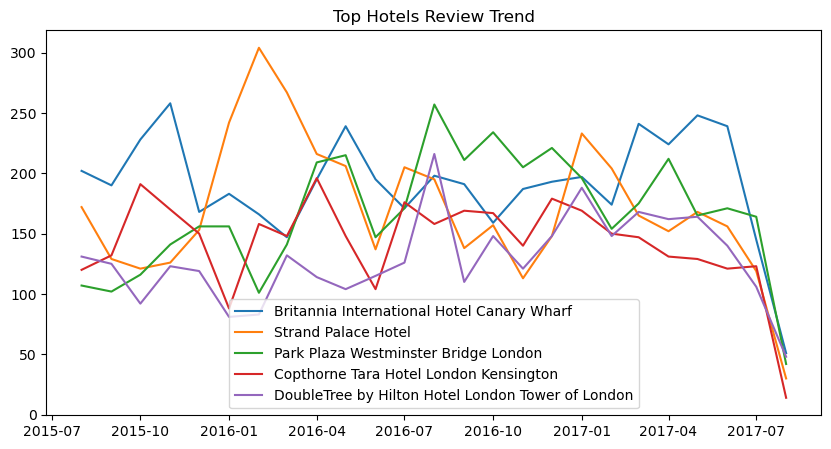

In [234]:
top_hotels = (
    dfv.groupby("Hotel_Name")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(10,5))

for hotel in top_hotels:
    temp = dfv[dfv["Hotel_Name"] == hotel]
    temp_monthly = temp.groupby("Year_Month").size()
    plt.plot(temp_monthly.index, temp_monthly.values, label=hotel)

plt.legend()
plt.title("Top Hotels Review Trend")
plt.show()

In [240]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook_connected"

top_hotels = (
    dfv.groupby("Hotel_Name")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_top = dfv[dfv["Hotel_Name"].isin(top_hotels)].copy()

df_top["Year_Month"] = pd.to_datetime(df_top["Year_Month"].astype(str))

monthly_neg = (
    df_top
    .groupby(["Hotel_Name", "Year_Month"], as_index=False)
    ["Review_Total_Negative_Word_Counts"]
    .mean()
)

monthly_neg["Neg_Words_Smooth"] = (
    monthly_neg
    .sort_values(["Hotel_Name", "Year_Month"])
    .groupby("Hotel_Name")["Review_Total_Negative_Word_Counts"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

fig = px.line(
    monthly_neg,
    x="Year_Month",
    y="Neg_Words_Smooth",
    color="Hotel_Name",
    hover_name="Hotel_Name",
    title="Smoothed Monthly Negative Words Trend for Top Hotels"
)

fig.update_layout(showlegend=False)

pio.renderers.default = "iframe"
fig.show()

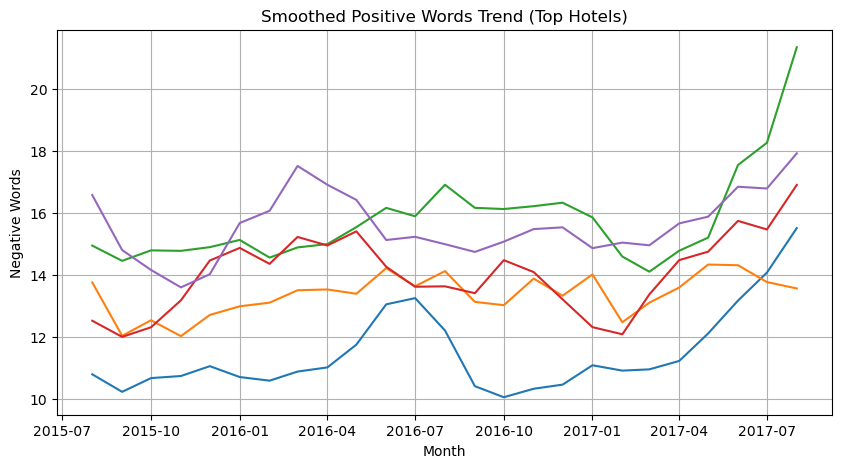

In [268]:

top_hotels = (
    dfv.groupby("Hotel_Name")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(10,5))

for hotel in top_hotels:
    
    temp = dfv[dfv["Hotel_Name"] == hotel].copy()
    
    
    temp["Year_Month"] = pd.to_datetime(temp["Year_Month"])
    
    
    monthly_neg = temp.groupby("Year_Month")['Review_Total_Positive_Word_Counts'].mean()
    
   
    monthly_neg_smooth = monthly_neg.rolling(3, min_periods=1).mean()
    
    plt.plot(monthly_neg_smooth.index, monthly_neg_smooth.values)

plt.title("Smoothed Positive Words Trend (Top Hotels)")
plt.xlabel("Month")
plt.ylabel("Negative Words")
plt.grid(True)

plt.show()

In the context of online review platforms, gaming (or manipulation) refers to strategic behavior by hotels aimed at influencing their perceived reputation. This can take several forms, including artificially increasing the number of reviews, encouraging disproportionately positive feedback, suppressing negative experiences, or timing review activity to coincide with periods of high demand. In essence, gaming implies that observed reviews and ratings may not fully reflect genuine customer experiences but are instead partially shaped by deliberate intervention.

Testing for such behavior is important because the empirical analysis relies on the assumption that reviews provide an honest signal of quality. If hotels systematically manipulate reviews, the relationship between sentiment (positive and negative words) and review scores may be biased, weakening the validity of the results. Therefore, detecting potential gaming is a crucial robustness check to ensure that the observed patterns in the data are driven by real consumer experiences rather than artificial inflation or suppression.

To investigate this issue, the analysis focuses on the most influential hotels . I mean those with the highest number of reviews and the largest volumes of positive and negative words. These hotels are the most likely candidates for manipulation, as they have both the incentive and the scale to potentially influence their online reputation. By examining the evolution of review volume and sentiment over time for these hotels, it becomes possible to identify patterns that may indicate strategic behavior.

The visual evidence suggests that review activity follows a largely smooth and gradual pattern over time, rather than exhibiting abrupt or irregular changes. In the plot of review counts, fluctuations are present but tend to evolve progressively, with no sharp spikes followed by sudden declines. This is consistent with organic variation in demand, such as seasonal travel patterns, rather than coordinated bursts of artificially generated reviews.

A closer look at seasonal dynamics reinforces this interpretation. Review activity and sentiment appear to increase during peak travel periods, particularly in the summer months (June–August) and around holiday seasons such as December and early January. For example, several hotels show upward movements in both review counts and positive sentiment during mid-year periods, likely reflecting increased tourist inflows. Similarly, modest increases around the winter holiday season are visible, which can be attributed to higher travel demand and festive-related stays. Importantly, these increases are gradual and synchronized across multiple hotels, which is more consistent with common seasonal demand shocks than with hotel-specific manipulation.

The patterns in positive sentiment further support this conclusion. Positive word usage tends to rise slightly during peak periods but does so in a smooth and continuous manner. There are no sudden jumps that would suggest artificial inflation of favorable reviews. Instead, the increases align with periods when hotels are likely to perform well due to higher occupancy, better atmosphere, or improved service conditions during high-demand seasons.

Similarly, negative sentiment does not exhibit signs of suppression. Negative word usage persists across all periods and varies gradually over time. While there are minor fluctuations, there are no sharp declines or sudden disappearances of negative feedback that would indicate systematic filtering or manipulation. In fact, negative sentiment also shows mild increases during peak seasons in some cases, which is intuitive, as higher occupancy can lead to more service pressure and a wider range of customer experiences.

Taken together, the joint behavior of review volume, positive sentiment, and negative sentiment suggests that the data are internally consistent and evolve in a manner that reflects natural market dynamics. If gaming were present, we would expect to observe more irregular patterns, such as isolated spikes in positive sentiment without corresponding changes in review volume, abrupt drops in negative sentiment, or sharp, hotel-specific deviations from broader trends. However, none of these patterns are clearly evident in the data.

So at the end we can say the evidence indicates that review activity and sentiment for the most prominent hotels follow organic, seasonally driven trends rather than patterns consistent with manipulation. This supports the assumption that the review data provide a reliable measure of customer experience, thereby reinforcing the credibility of the main empirical findings.

# Conclusion

This project set out to understand how online review dynamics—specifically review sentiment and review volume shape hotel ratings over time. Using detailed review-level data from Booking.com, the analysis first constructed a hotel-month panel dataset, aggregating daily observations into meaningful measures of average rating, average sentiment (positive and negative words), and review activity. This structure allowed the study to capture how new information flows rather than cumulative history alone affect consumer evaluations, while also enabling rigorous panel-data analysis.

The empirical findings are consistent and robust across multiple specifications. In the pooled OLS model, both positive and negative sentiment exhibit strong and statistically significant effects on ratings.  positive words increase scores, while negative words decrease them. However, this specification does not account for unobserved heterogeneity across hotels or time, leaving open the possibility of bias.

To address this, the analysis moved to a fixed effects (FE) framework, controlling for both hotel-specific characteristics and common time shocks. The FE results confirm the core findings in which review sentiment remains the primary driver of ratings, with positive and negative words exerting strong and stable effects. Importantly, the FE model provides a more credible identification by isolating within-hotel variation over time, and the results remain remarkably consistent with the simpler pooled model. This suggests that the observed relationships are not driven by cross-hotel differences but reflect genuine within-hotel dynamics.

As a further robustness check, a dynamic panel model using the Arellano–Bond GMM estimator was implemented to address potential endogeneity and persistence in ratings. The GMM results reinforce the central role of sentiment, while also revealing that the lagged dependent variable is small and statistically insignificant, indicating weak persistence in ratings. This suggests that hotel scores are largely driven by current experiences rather than past ratings, and that the dynamic component of the model adds limited explanatory power. Consequently, while GMM serves as a useful robustness exercise, the FE specification emerges as the most stable and interpretable main model.

Beyond the baseline relationship, the analysis explored heterogeneous effects, particularly focusing on the role of length of stay (number of nights). While the number of nights does not have a significant direct effect on ratings, it plays an important moderating role. The interaction results show that the impact of both positive and negative sentiment weakens as stay duration increases. This finding suggests that longer stays lead to more balanced evaluations, where individual experiences whether positive or negative carry less weight in shaping the final rating. In contrast, shorter stays appear to amplify the influence of specific experiences, resulting in stronger sentiment effects.

To further strengthen the validity of the findings, a range of robustness checks was conducted. These include alternative model specifications, clustered standard errors, lagged variables, and a placebo test using future (lead) sentiment variables. The placebo results show that future sentiment does not predict current ratings, providing strong evidence against reverse causality and supporting the credibility of the identification strategy. Additional checks, such as excluding the most active hotels and testing alternative variable constructions, confirm that the main results are not driven by outliers or specific modeling choices.

Finally, the project examined the possibility of review manipulation (gaming). By analyzing the temporal evolution of review volume and sentiment for the most active hotels, the study looked for abnormal patterns such as sudden spikes, sharp drops, or asymmetries between positive and negative feedback. The evidence shows that review activity and sentiment evolve in a smooth and continuous manner, with clear seasonal patterns such as increases during summer travel months and holiday periods but no signs of abrupt or irregular behavior. Both positive and negative sentiment persist over time without systematic suppression or artificial inflation. These findings suggest that the review data largely reflect organic consumer behavior rather than strategic manipulation.

As a final result, the findings provide a coherent and robust picture of online review dynamics. Sentiment is the dominant factor shaping hotel ratings, while review volume plays a secondary role and past ratings exhibit limited persistence. The moderating role of stay duration highlights the importance of behavioral context, and the absence of evidence for gaming reinforces the reliability of the data. Overall, the analysis demonstrates that online reviews on Booking.com function as a credible and informative signal of quality, driven primarily by genuine customer experiencies.